In [5]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import os, glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mplhep as hep
from skimage.measure import block_reduce
from numpy.lib.stride_tricks import as_strided
plt.style.use([hep.style.ROOT, hep.style.firamath])
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import LogNorm, ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
# Define the CMS color scheme
cms_colors = [
    (0.00, '#FFFFFF'),  # White
    (0.33, '#005EB8'),  # Blue
    (0.66, '#FFDD00'),  # Yellow
    (1.00, '#FF0000')   # red
]

# Create the CMS colormap
cms_cmap = LinearSegmentedColormap.from_list('CMS', cms_colors)
from numpy.lib.stride_tricks import as_strided




In [25]:
# out_dir='data/plot_H_AA_4Tau_M_10_signal_kinematics'
out_dir='../analysis_run3/AN_Note_Plot/Signal_layer_Images'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)
save = True

In [26]:
def upsample_array(x, b0, b1):
    r, c = x.shape                                    # number of rows/columns
    rs, cs = x.strides                                # row/column strides
    x = as_strided(x, (r, b0, c, b1), (rs, 0, cs, 0)) # view as a larger 4D array
    return x.reshape(r*b0, c*b1)/(b0*b1) # create new 2D array with same total occupancy
    


def crop_jet(imgECAL, iphi, ieta, jet_shape=125):

    # NOTE: jet_shape here should correspond to the one used in RHAnalyzer
    off = jet_shape//2
    iphi = int(iphi*5 + 2) # 5 EB xtals per HB tower
    ieta = int(ieta*5 + 2) # 5 EB xtals per HB tower

    # Wrap-around on left side
    if iphi < off:
        diff = off-iphi
        img_crop = np.concatenate((imgECAL[:,ieta-off:ieta+off+1,-diff:],
                                   imgECAL[:,ieta-off:ieta+off+1,:iphi+off+1]), axis=-1)
    # Wrap-around on right side
    elif 360-iphi < off:
        diff = off - (360-iphi)
        img_crop = np.concatenate((imgECAL[:,ieta-off:ieta+off+1,iphi-off:],
                                   imgECAL[:,ieta-off:ieta+off+1,:diff+1]), axis=-1)
    # Nominal case
    else:
        img_crop = imgECAL[:,ieta-off:ieta+off+1,iphi-off:iphi+off+1]

    return img_crop

### Layesrs in images

### Image with original intensity

In [27]:
def plotJet_single_layer_cal(eve, mass):
    layers =['ECAL_energy', 'HBHE_energy']
    c_title = ['ECAL energy [GeV]', 'HCAL energy [GeV]']  
    cmap_ = ['YlOrRd','YlGnBu']
    
    ECAL_energy = np.array(branches["ECAL_energy"][eve]).reshape(280,360)
    HBHE_energy_ = np.array(branches["HBHE_energy"][eve]).reshape(56,72)
    HBHE_energy = upsample_array(HBHE_energy_, 5, 5) # (280, 360)
    img             = np.stack([ECAL_energy, HBHE_energy], axis=0)
    iphis  = ak.Array(branches["jetSeed_iphi"])[eve]
    ietas  = ak.Array(branches["jetSeed_ieta"])[eve]
    position = np.min([len(iphis), len(ietas)])

    for pos in range(position):
        print("event", eve)
        print("crope position", pos)
        img_cropped = crop_jet(img, iphis[pos], ietas[pos], jet_shape=125)
        for ch in [0, 1]:
            fig, ax = plt.subplots(figsize=(12,8),dpi=300)
            # im = ax.imshow(np.abs(Ecal_cropped , aspect='auto')  # Use ax.imshow for clarity
            im = ax.imshow(
                np.abs(img_cropped[ch]),
                aspect='auto',
                origin='lower',
                norm=plt.matplotlib.colors.LogNorm(vmin=.001, vmax=np.max(img_cropped)),
                cmap=cmap_[ch]
            )
            hep.cms.label(llabel="Simulation", rlabel=f"$m_A$={mass} GeV     13.6 TeV", loc=0, ax=ax)

            ax.set_xlabel(r"$i\varphi$")
            ax.set_ylabel(r"$i\eta$")
            cbar = plt.colorbar(im, ax=ax)
            cbar.set_label(c_title[ch])
            mass_str = str(mass).replace('.', 'p')
            plt.savefig(f'{out_dir}/single_layer_cropped_image_mass_{mass_str}_GeV_event_{eve}_{layers[ch]}_original_{pos}.pdf',facecolor='w',dpi=300)
            plt.show()

    

event 11
crope position 0


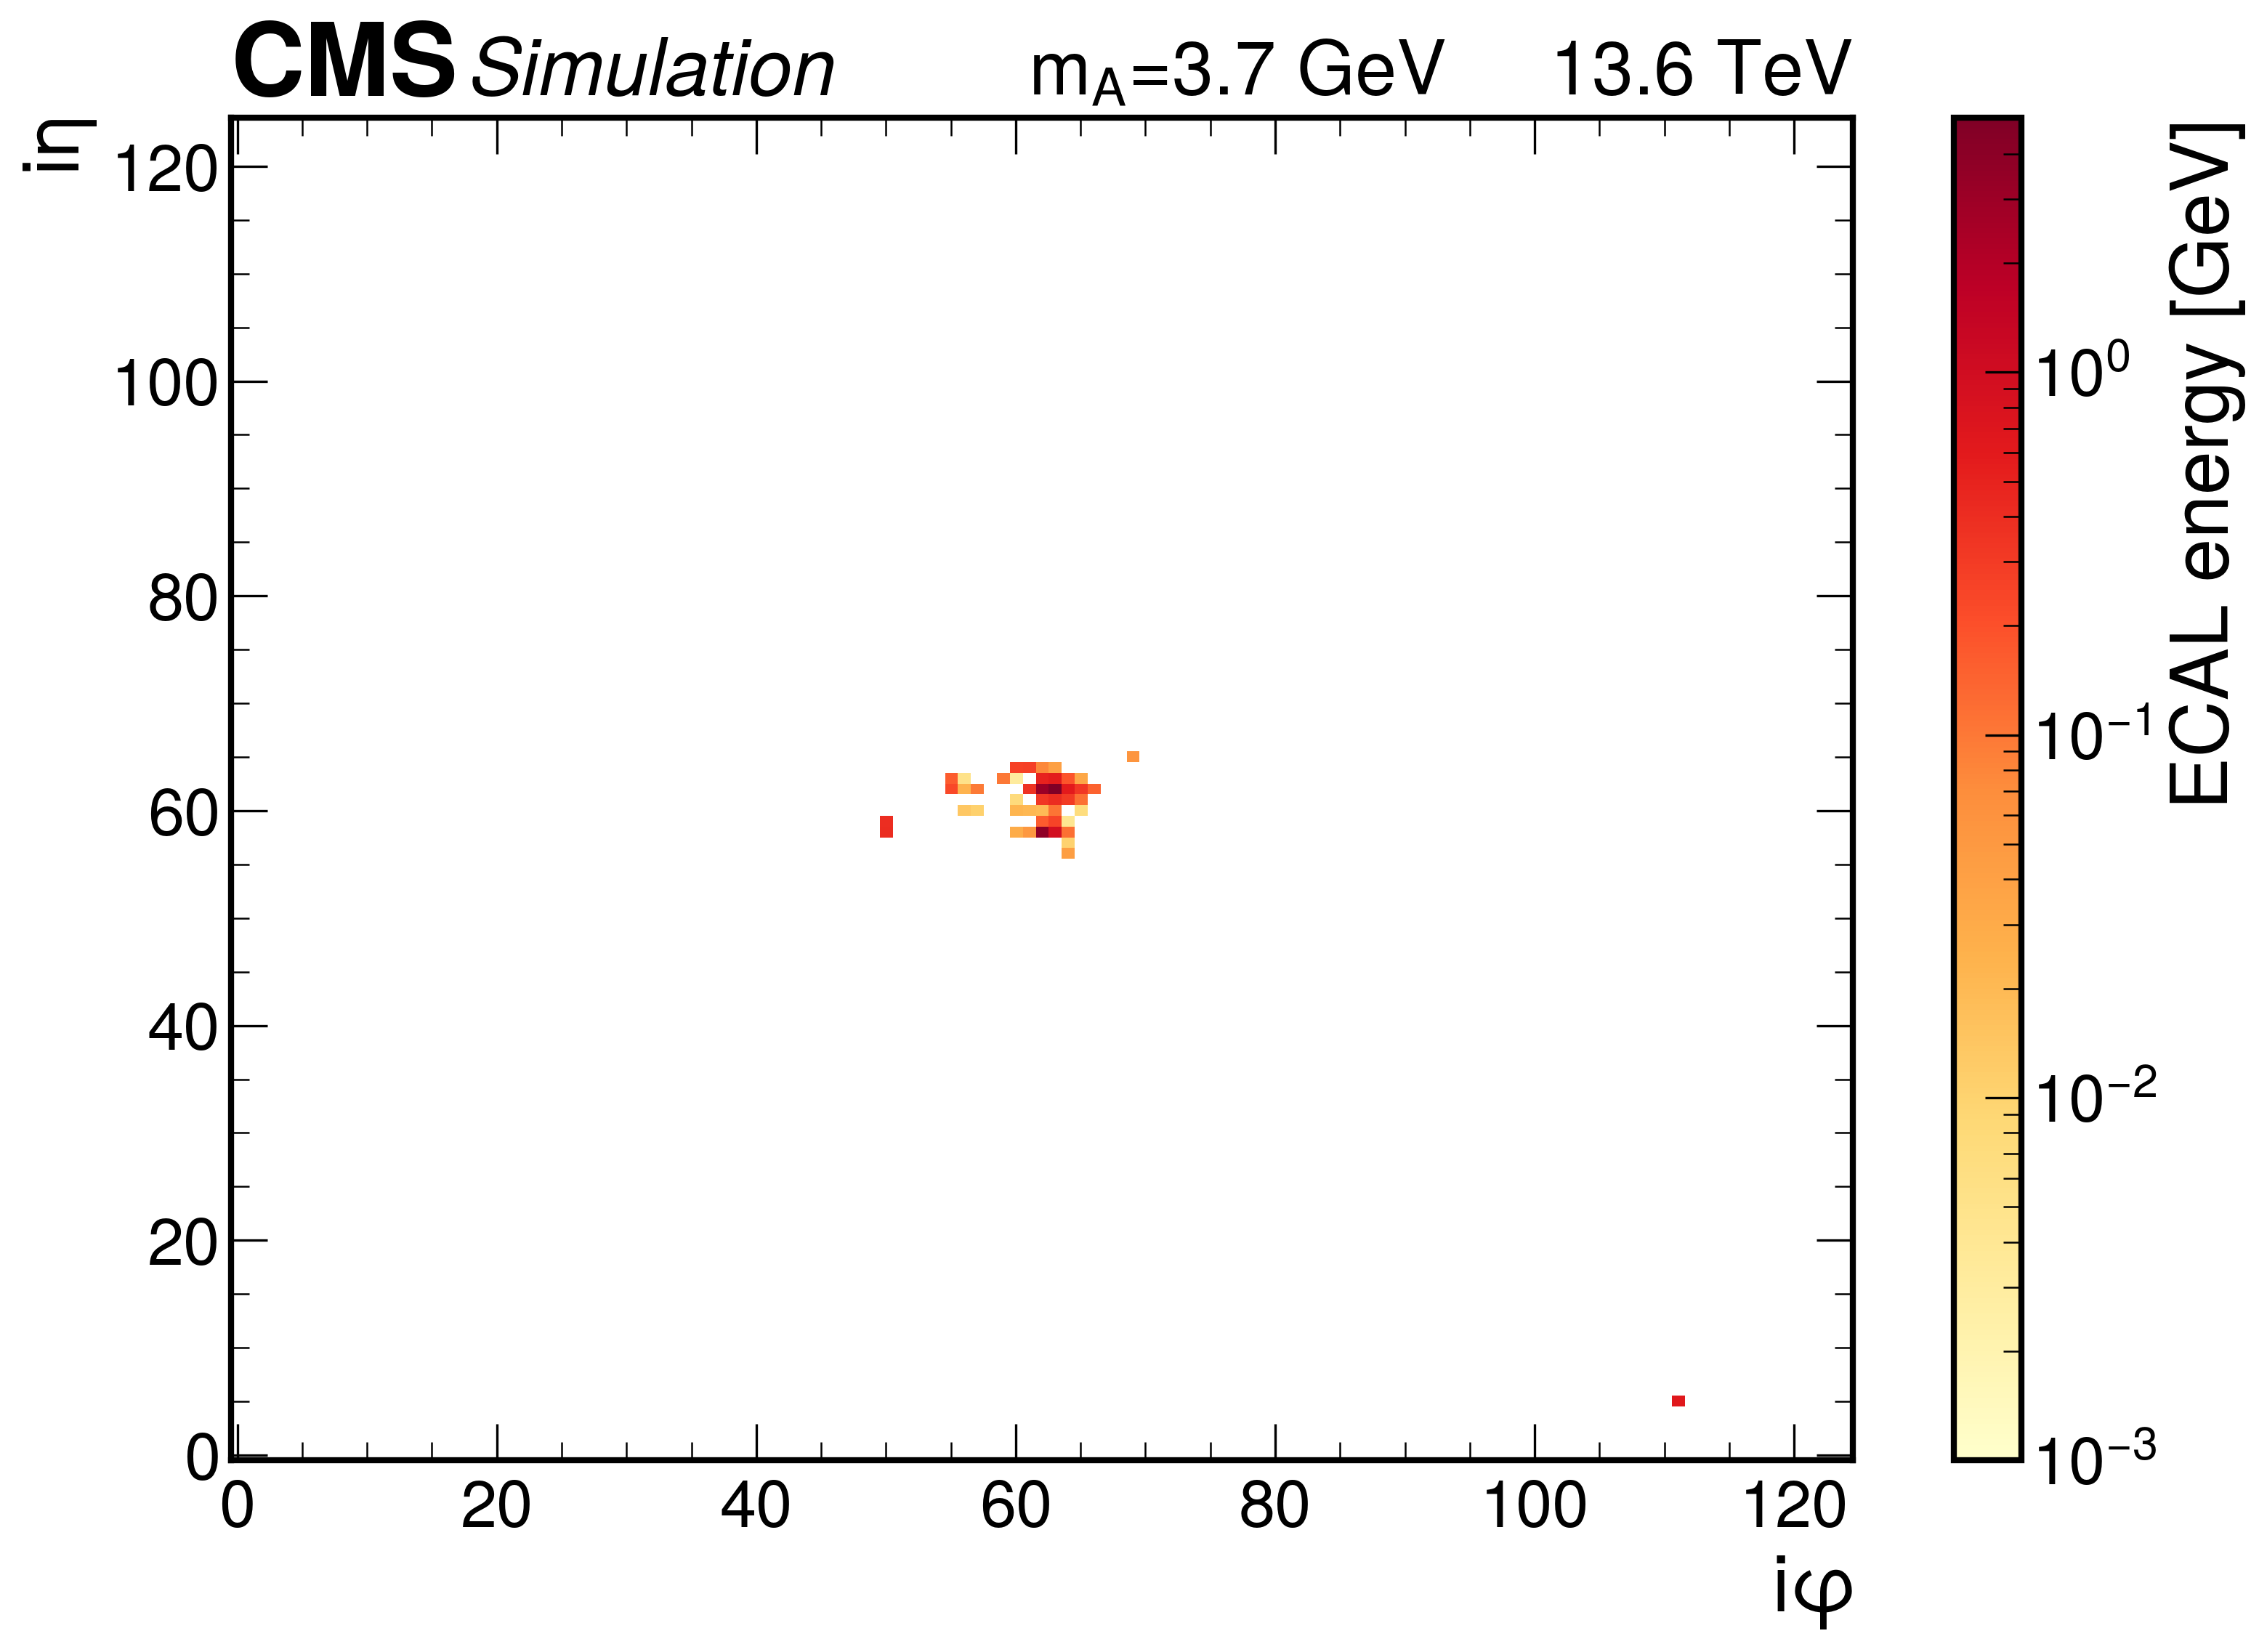

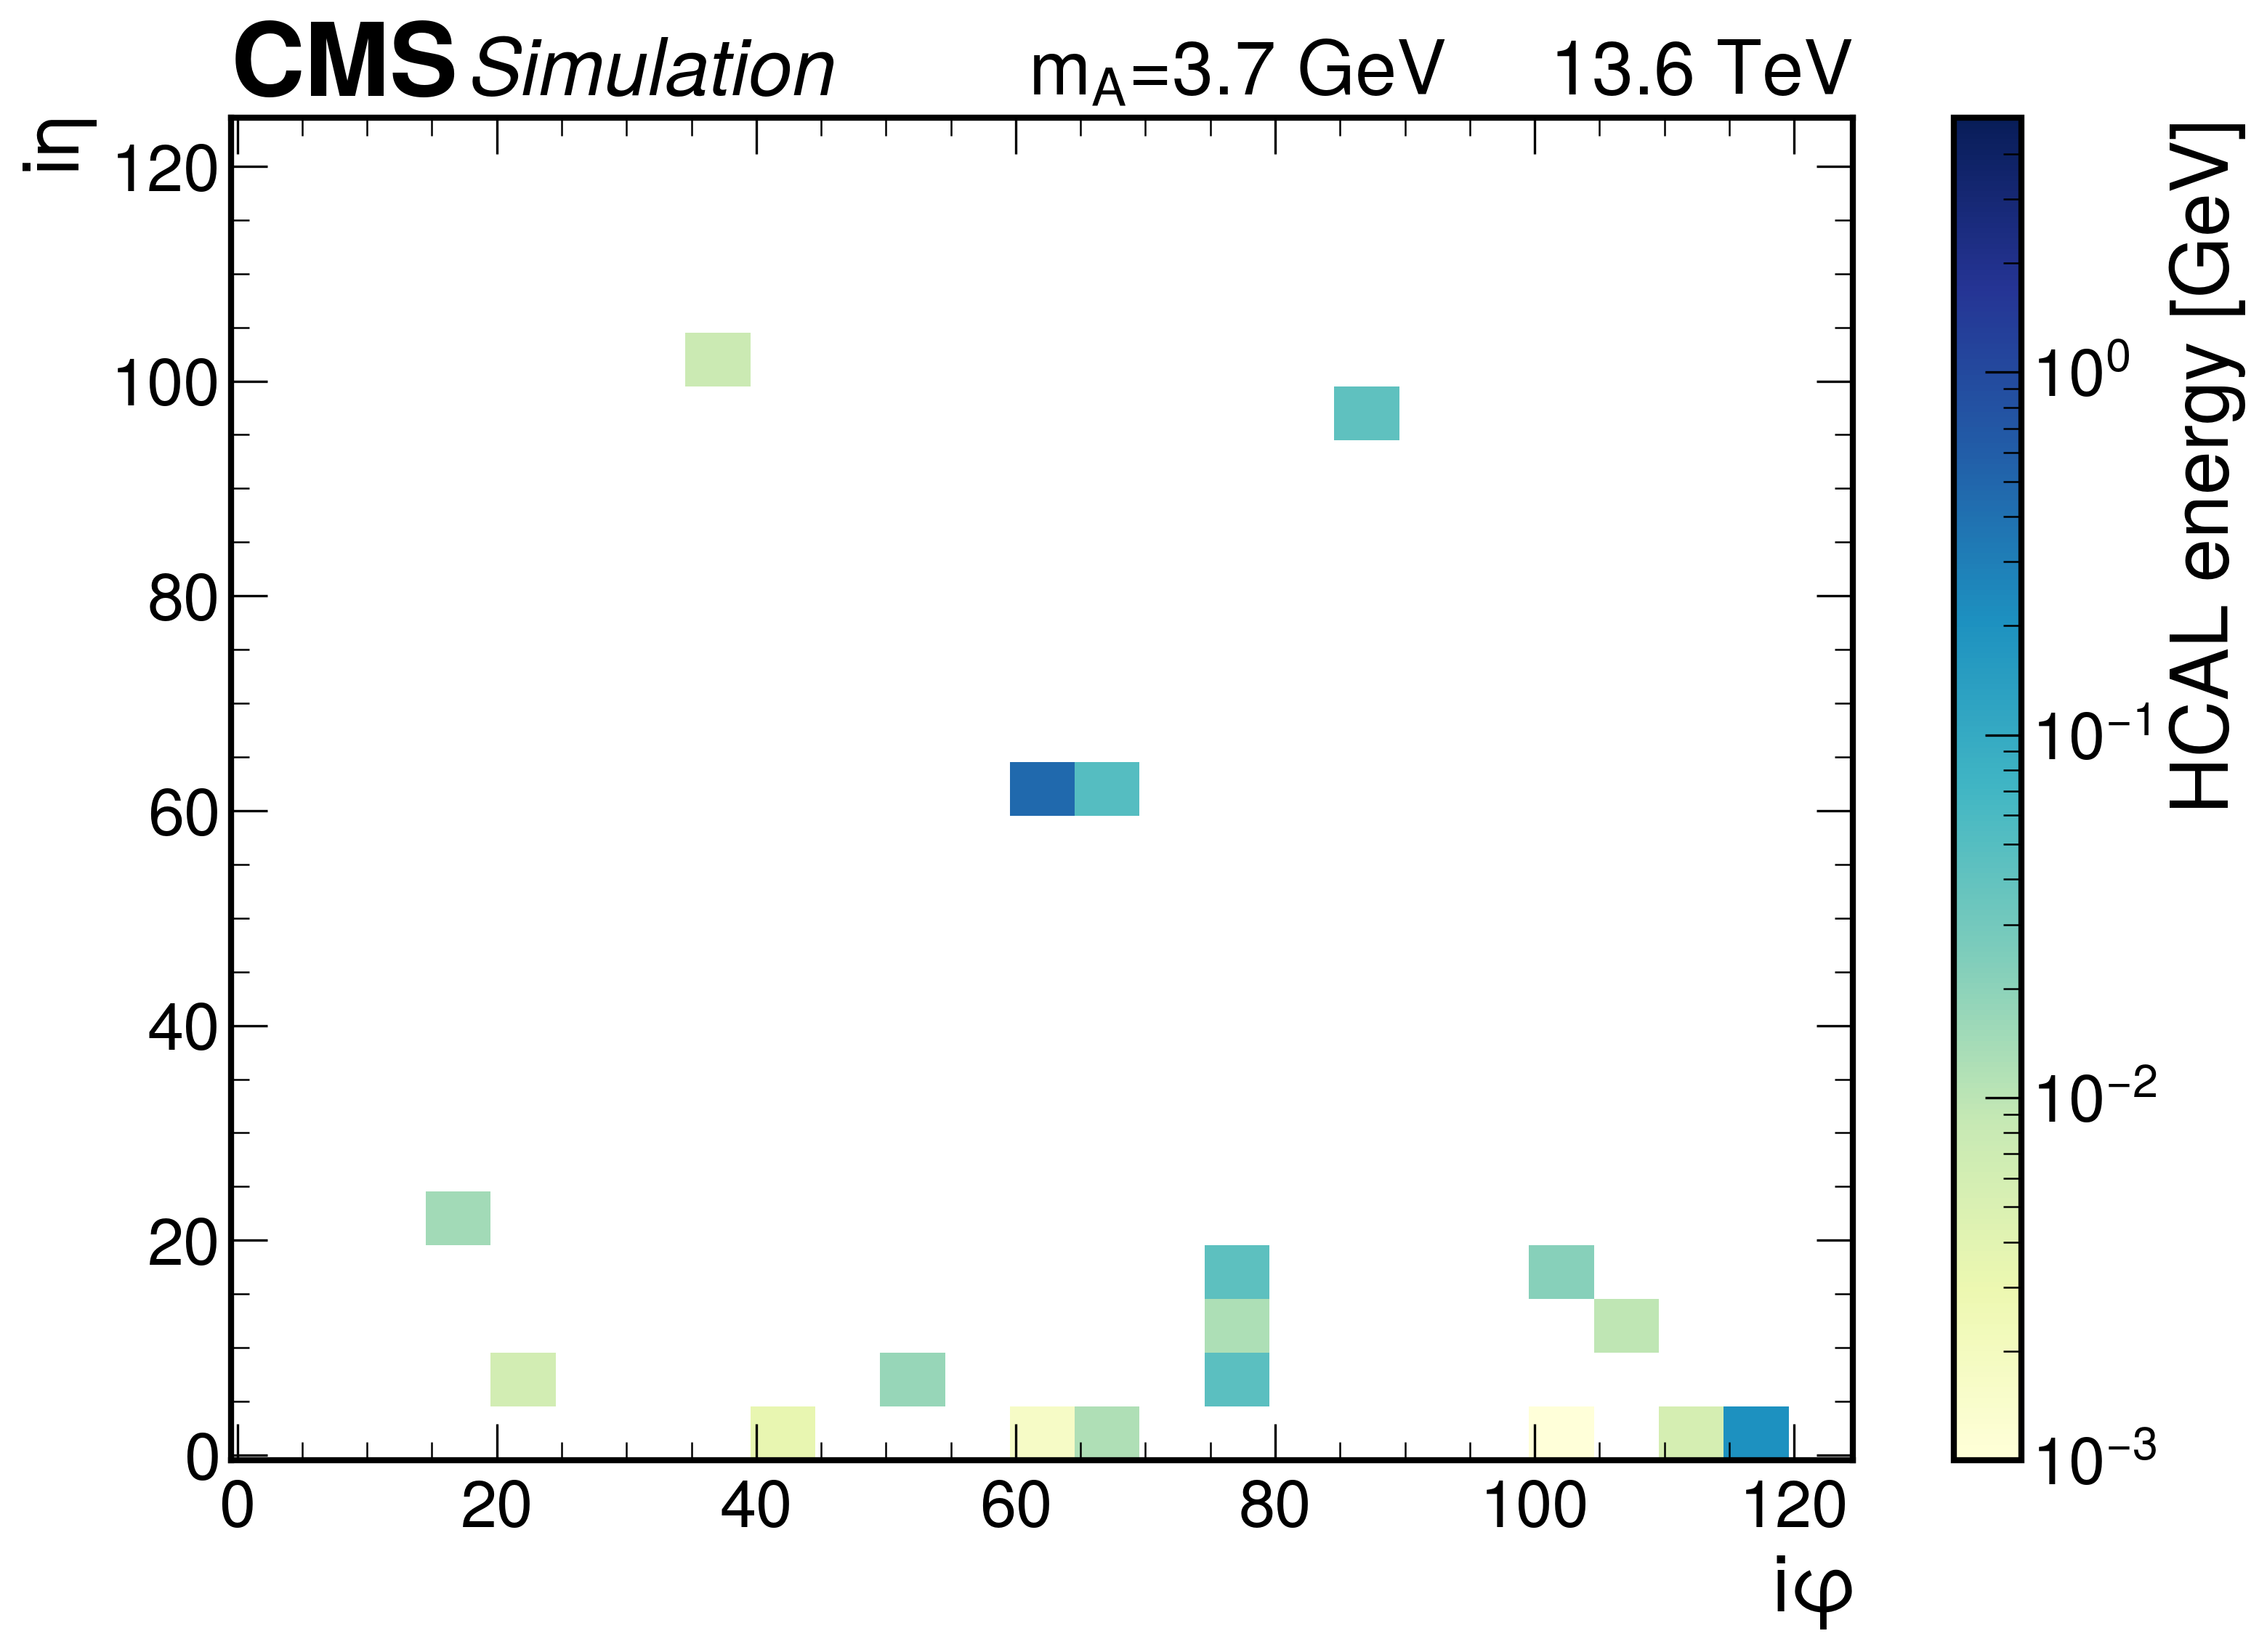

event 11
crope position 1


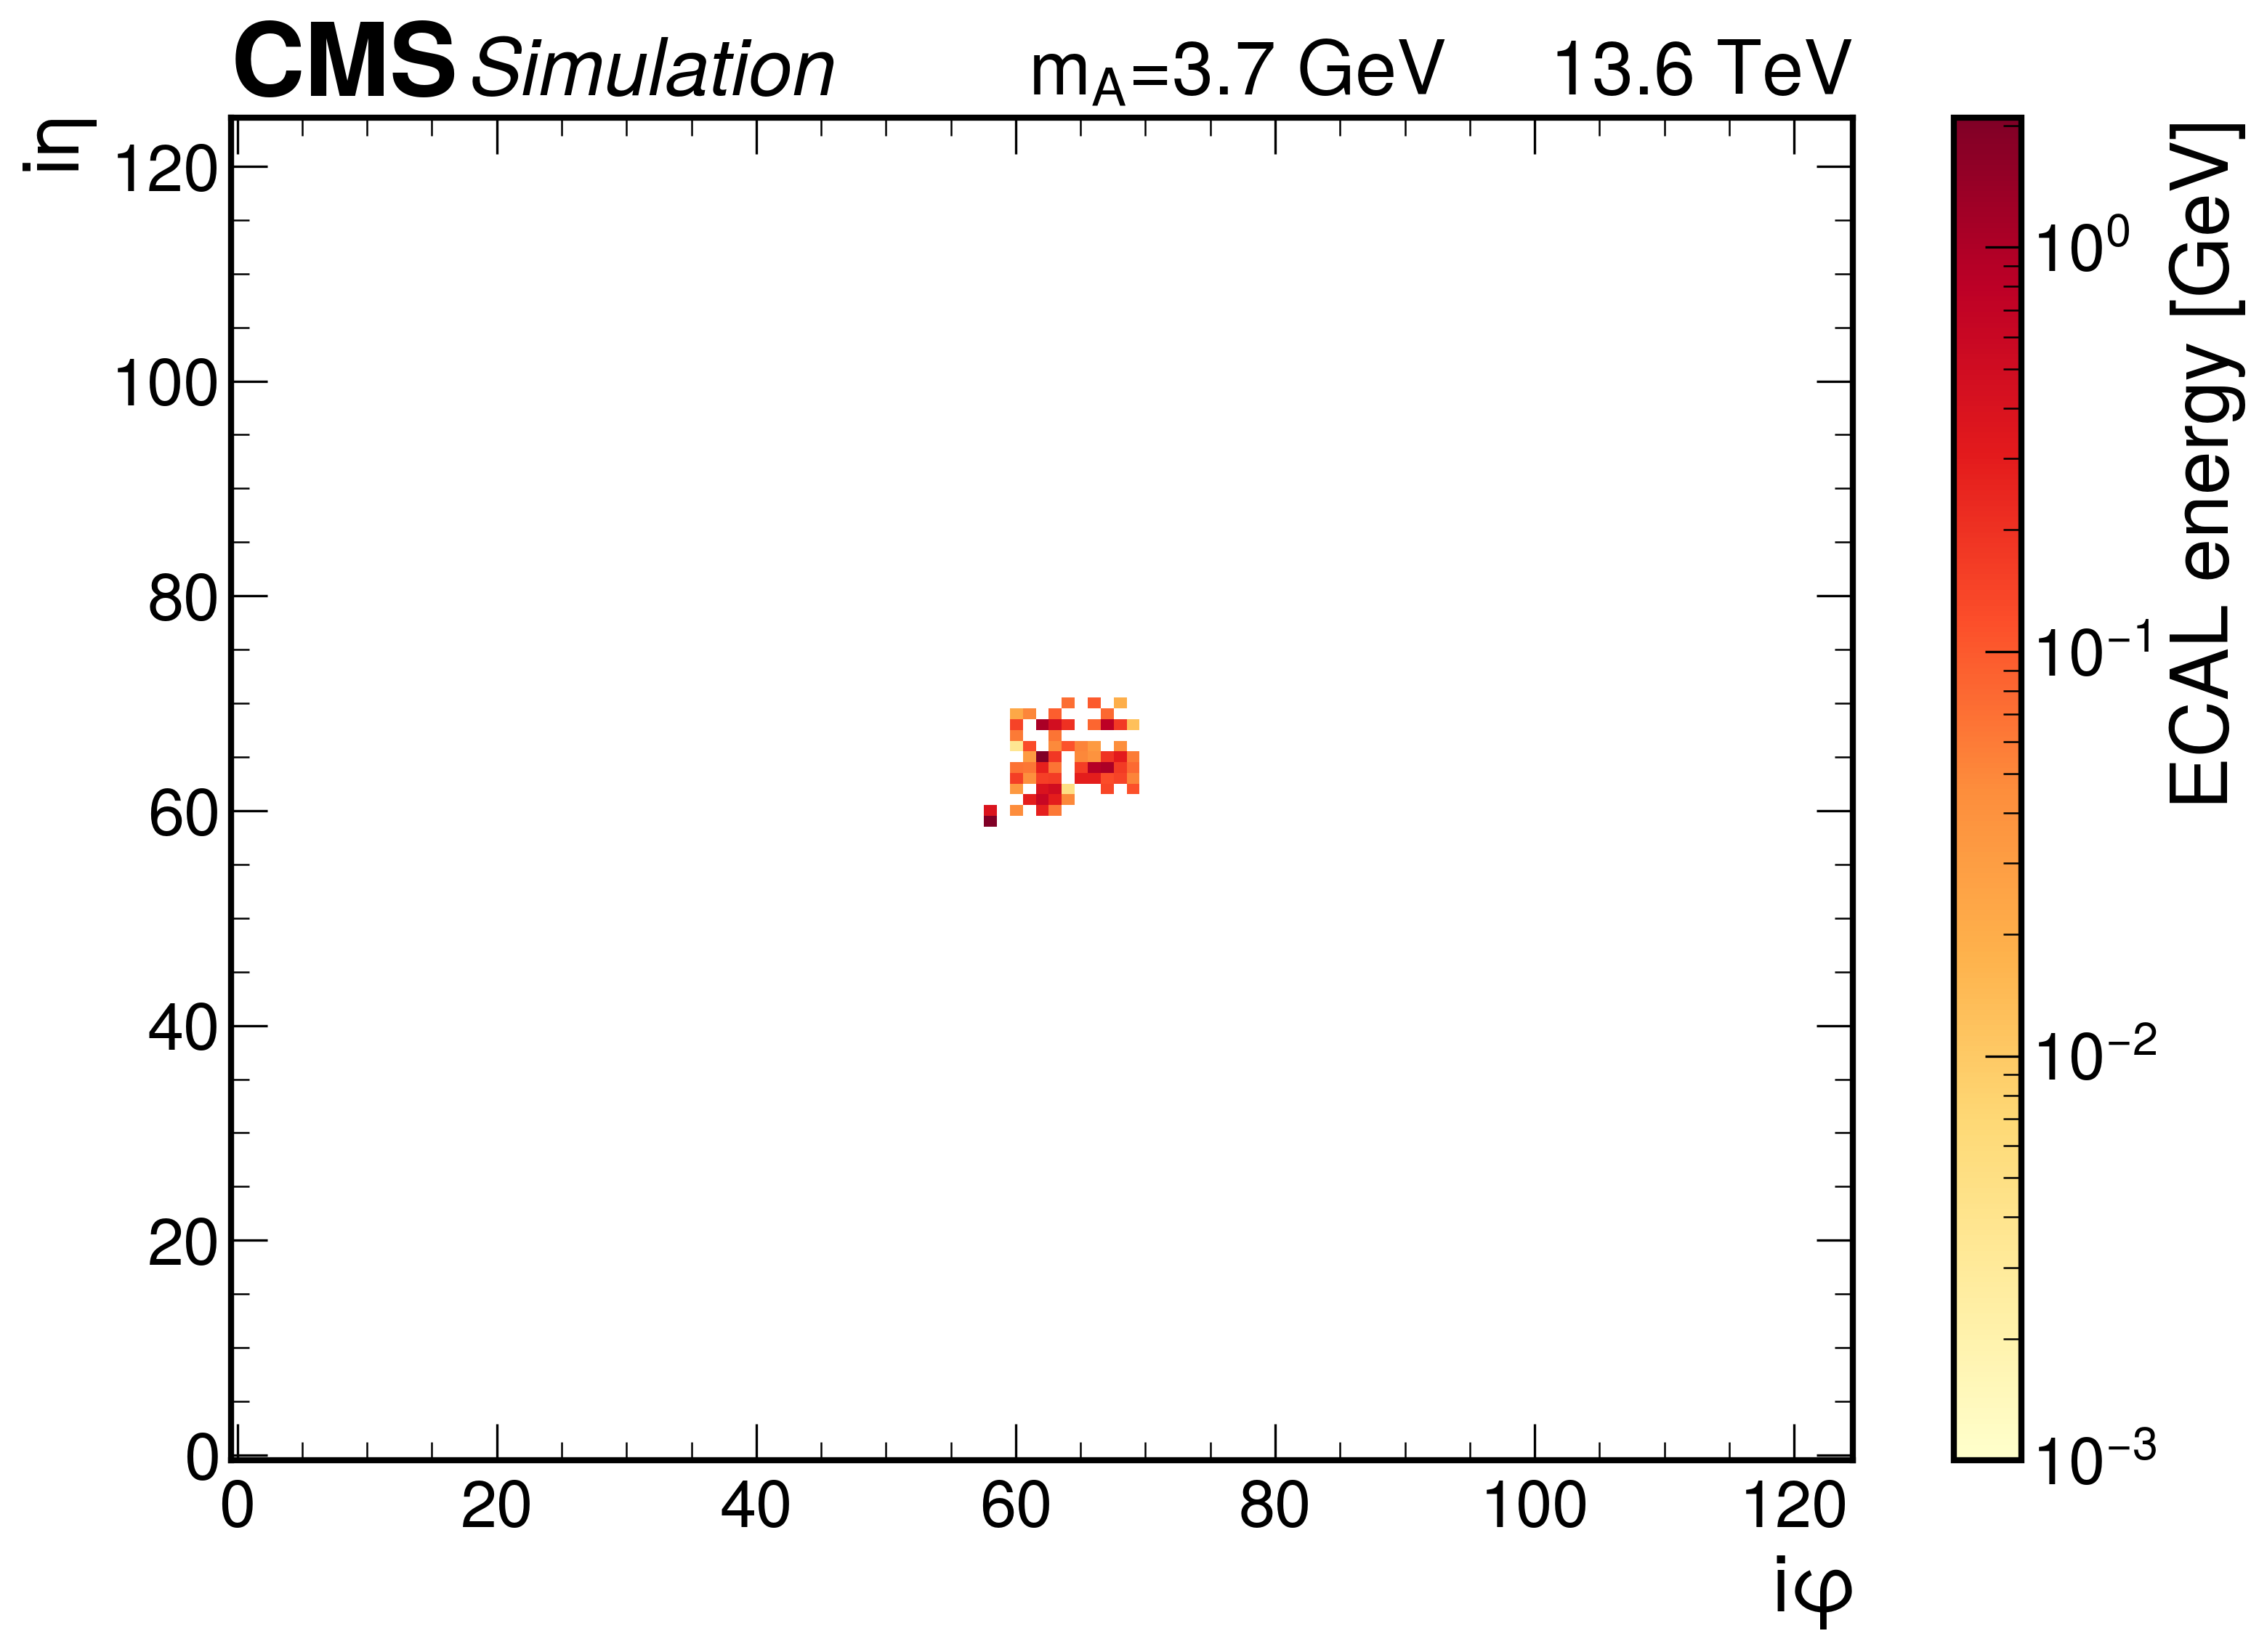

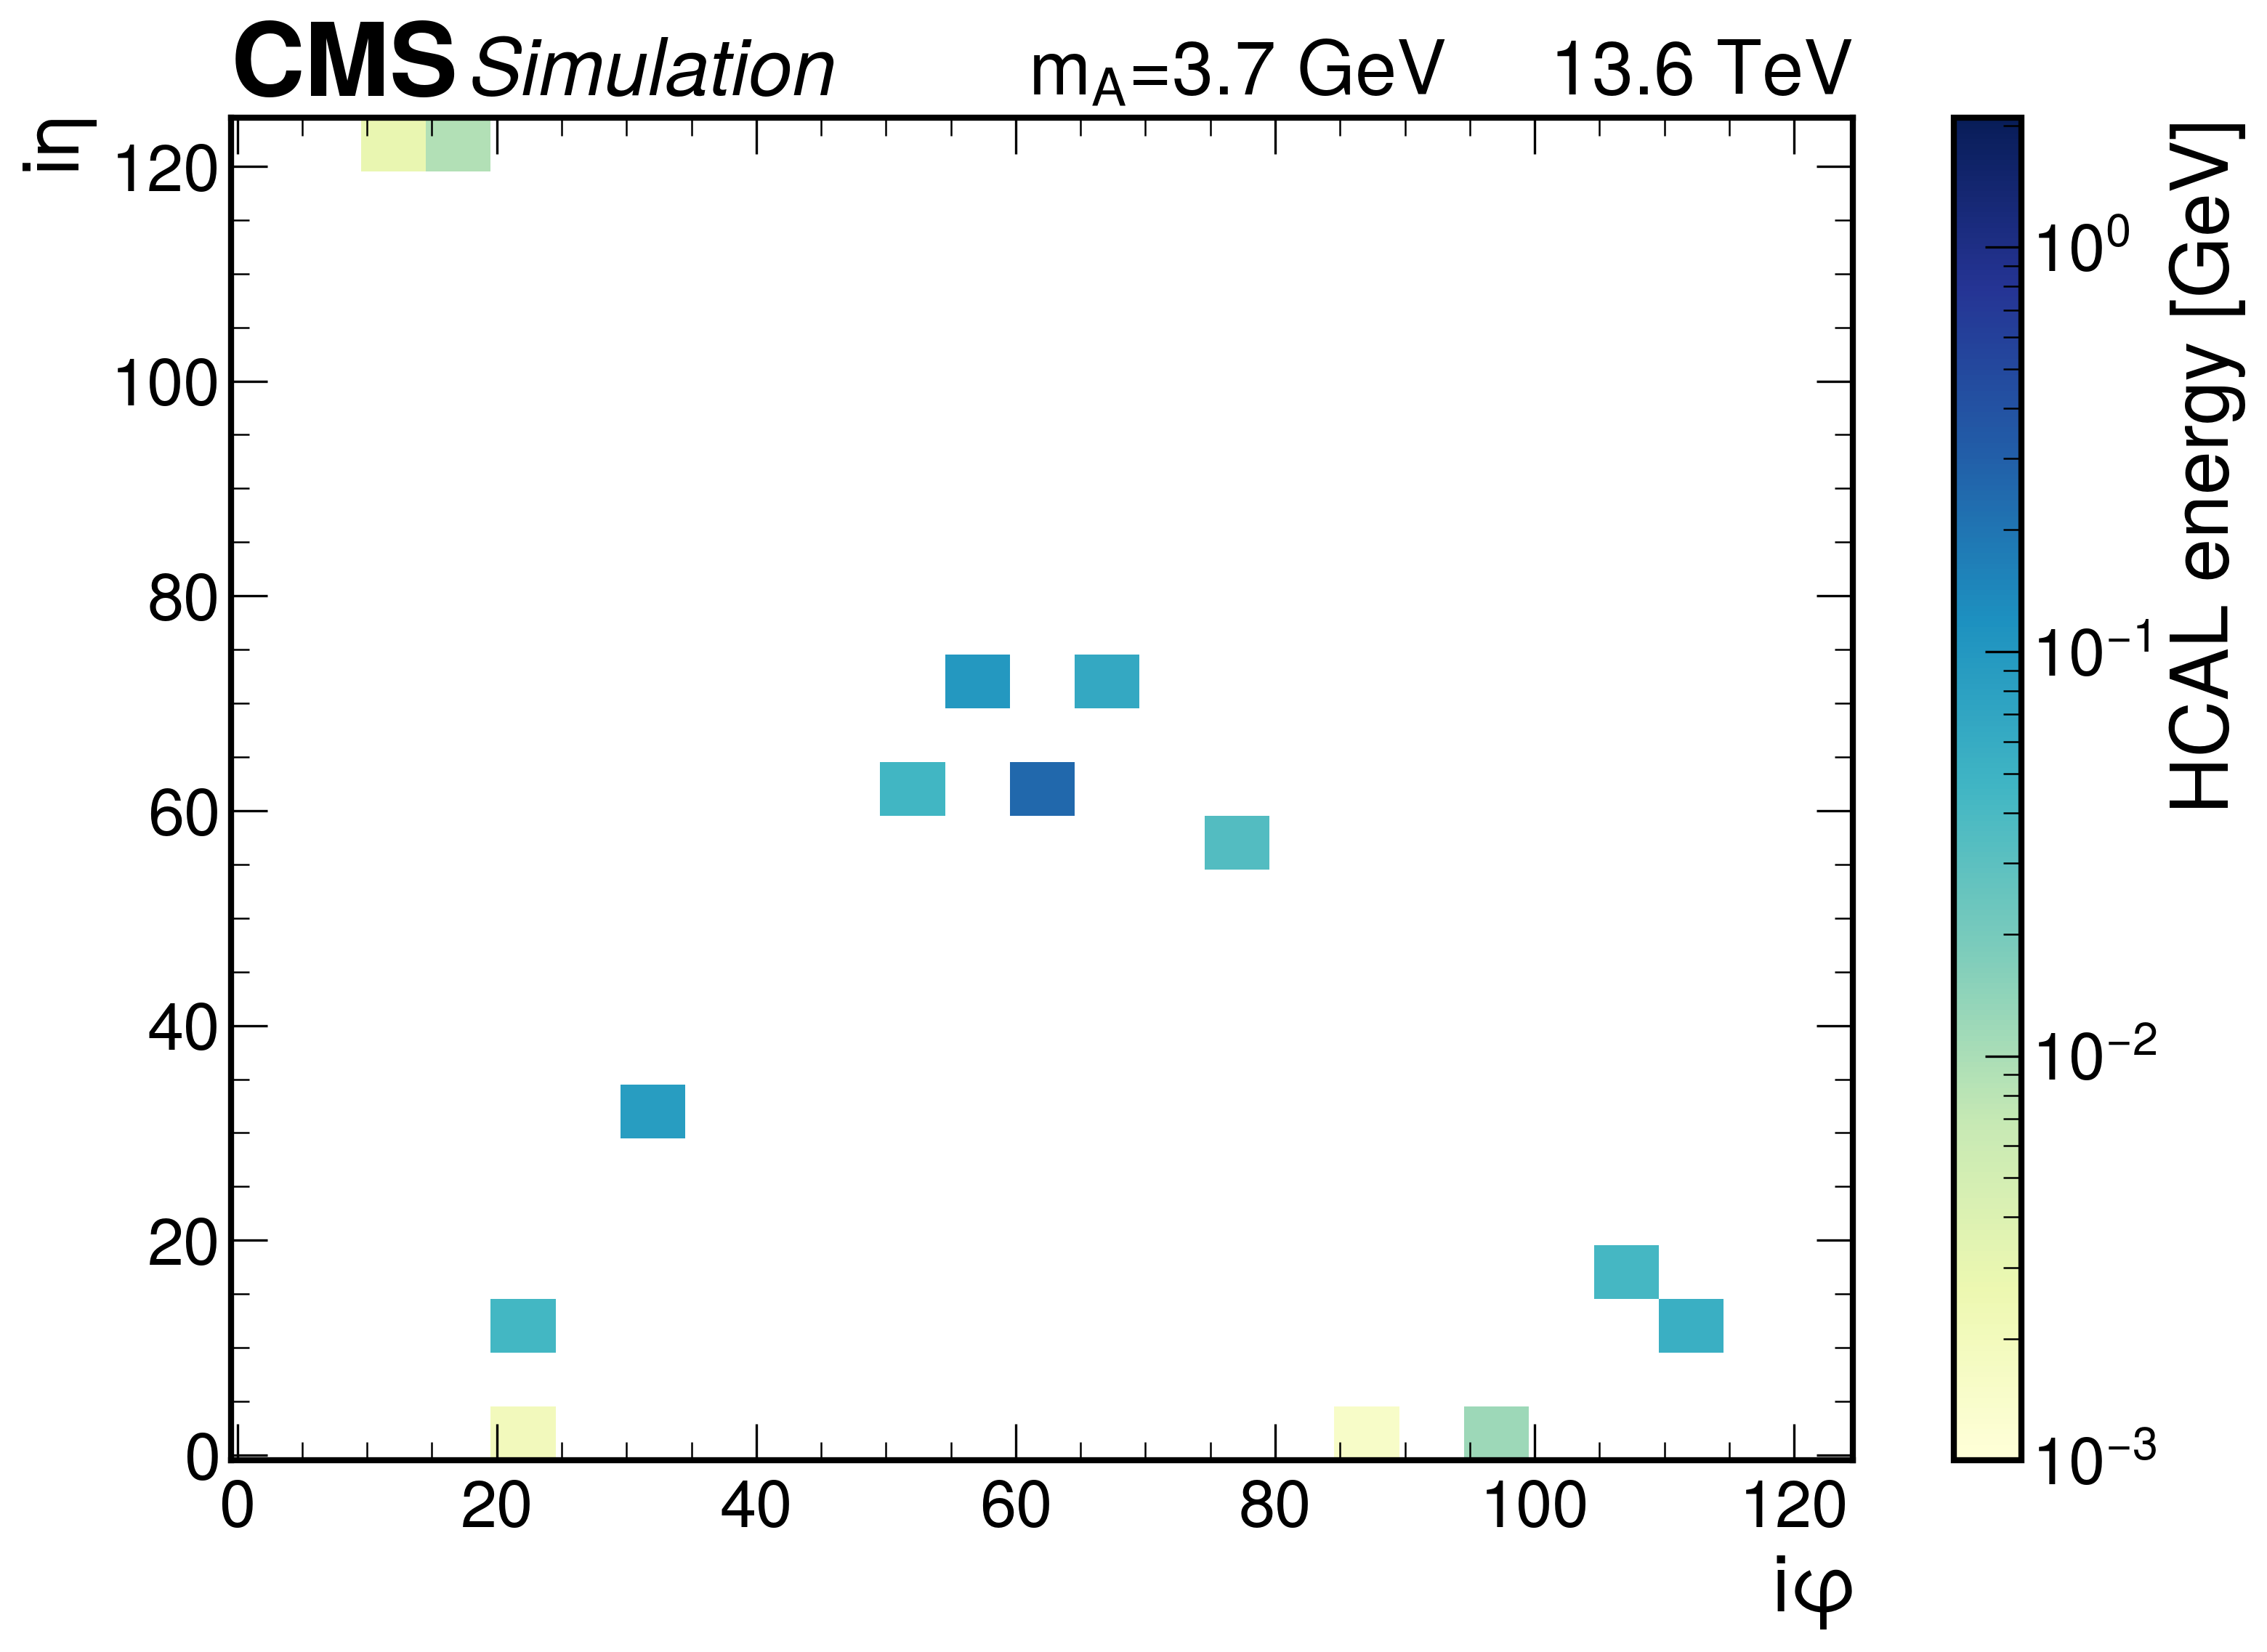

event 52
crope position 0


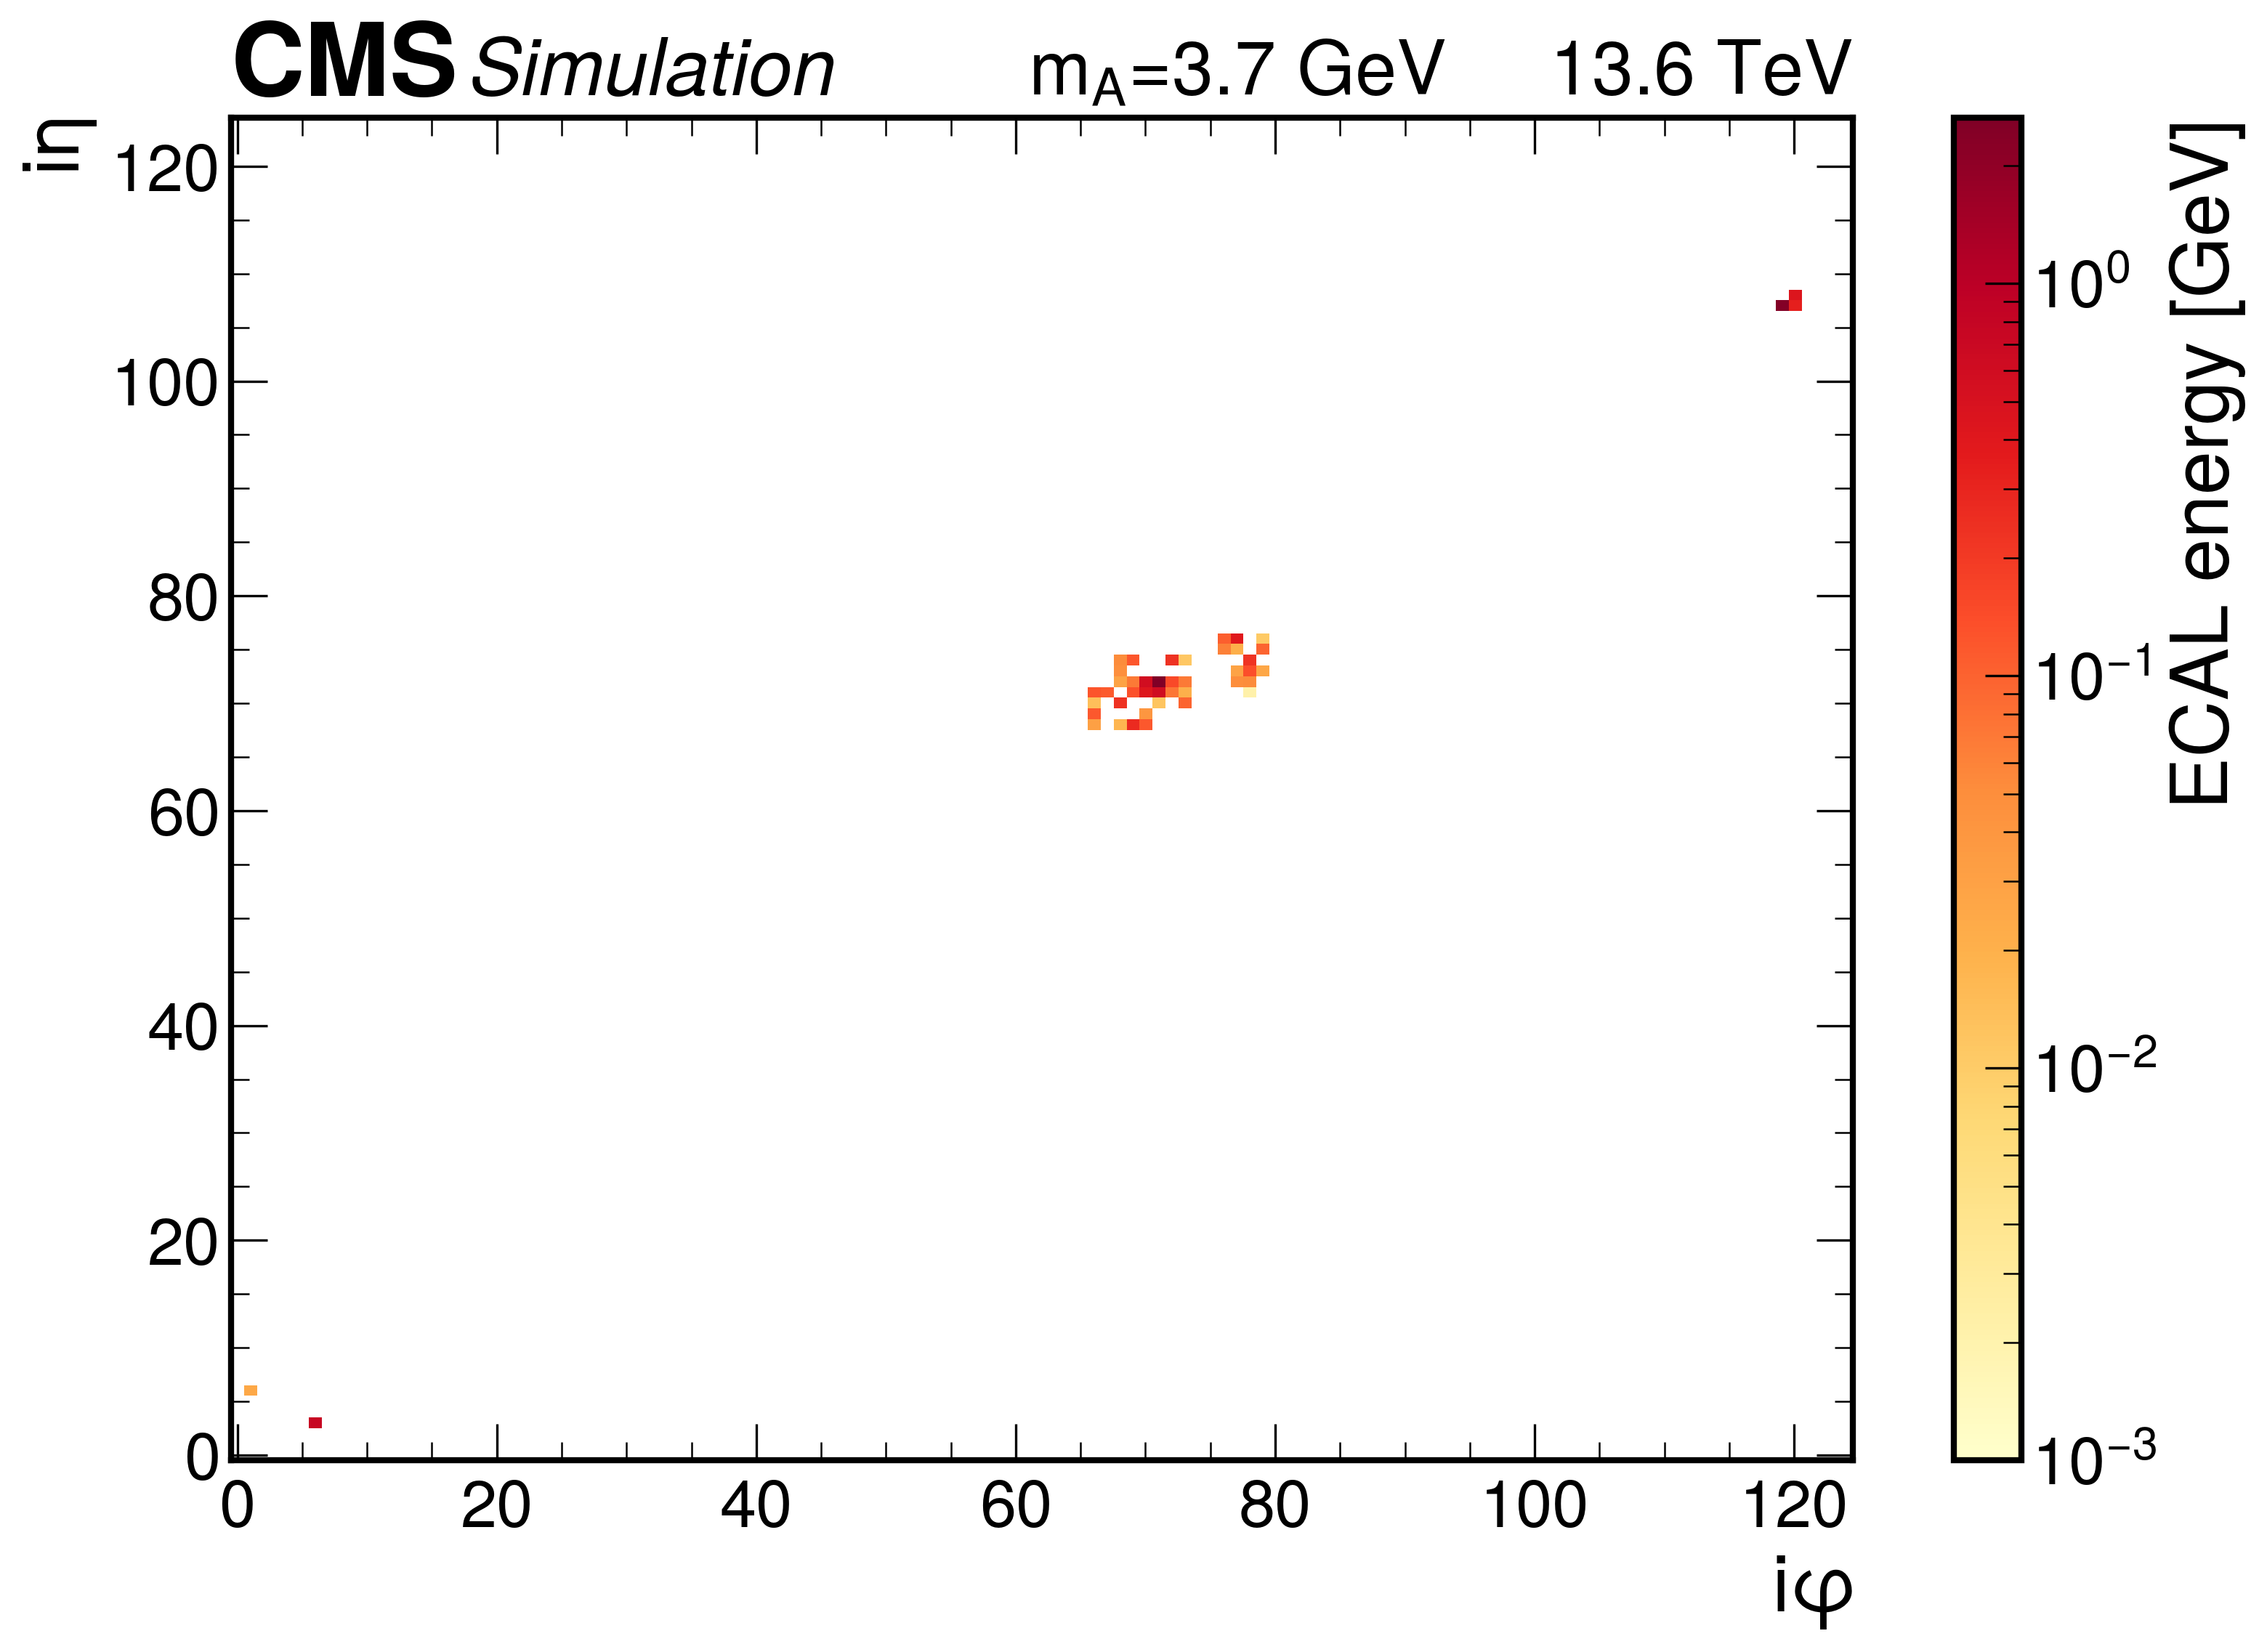

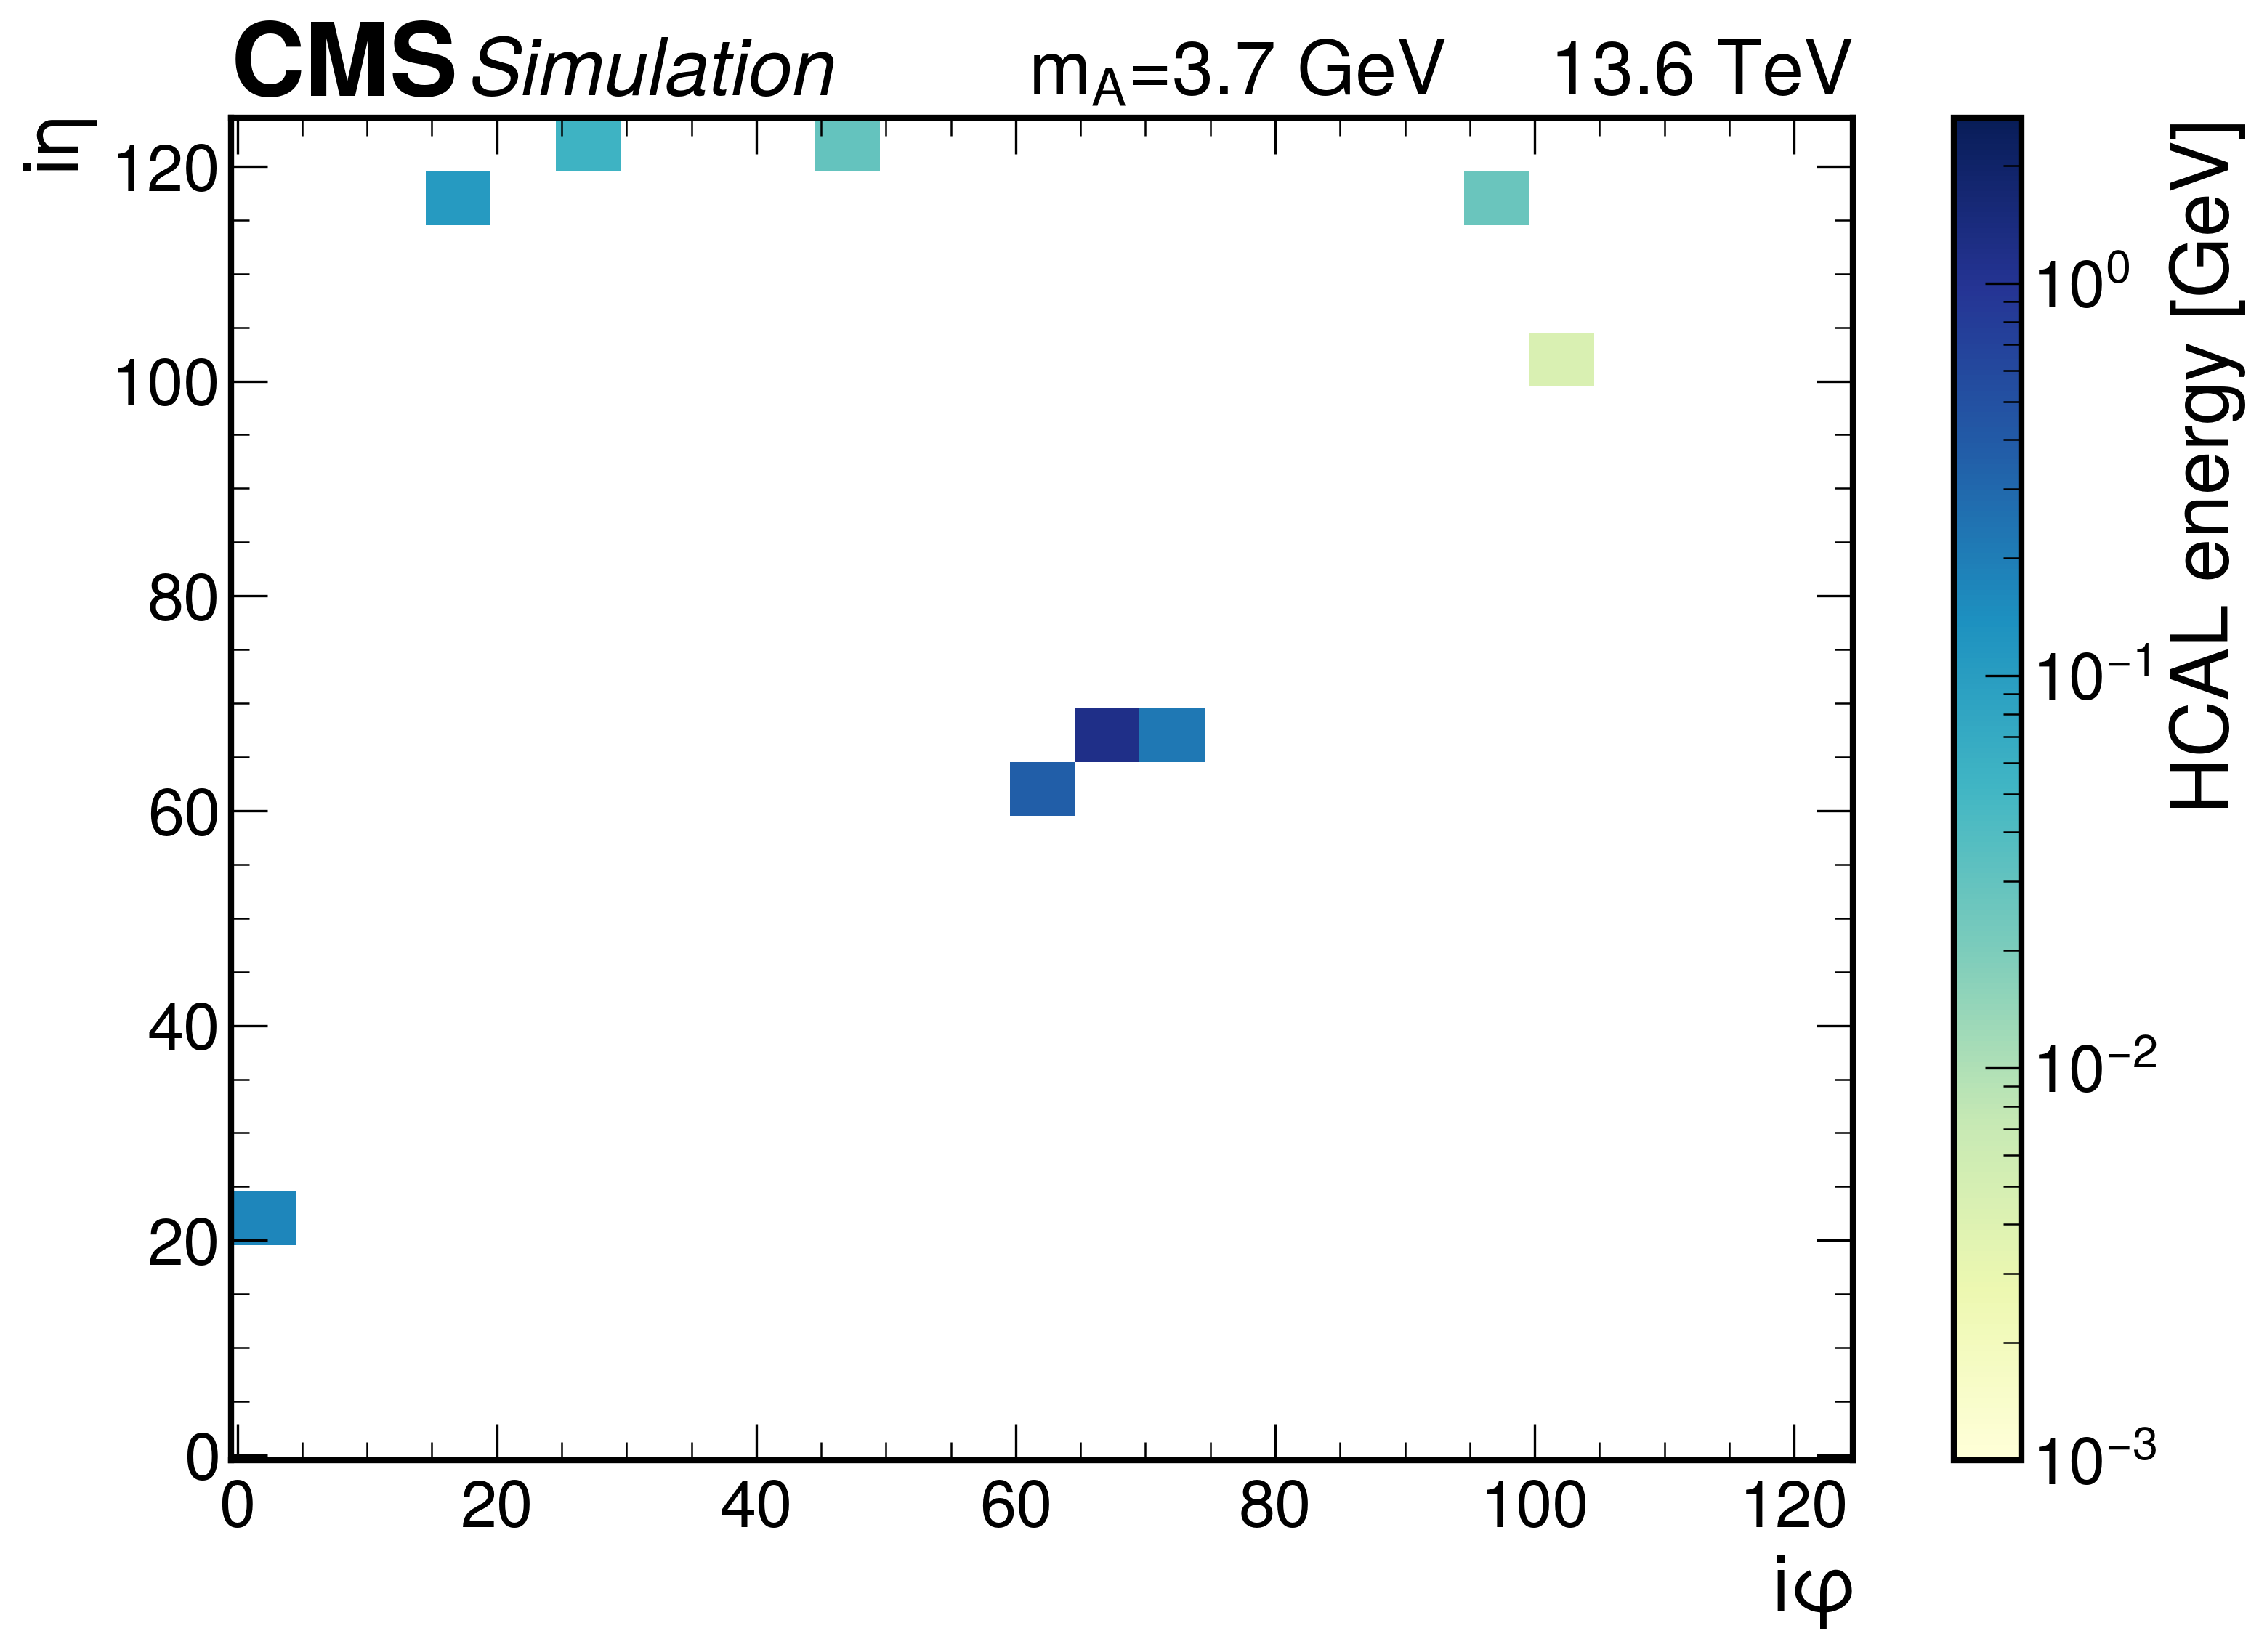

In [28]:
file = uproot.open("../analysis_run3/Data_for_plots/HToAAto4Tau_signal_sample_m3p7_numEvent500.root")
RHTree = file["fevt/RHTree"]
branches = RHTree.arrays(entry_start=0, entry_stop=55)
for i in [11,52]:
    plotJet_single_layer_cal(i,3.7)



event 4
crope position 0


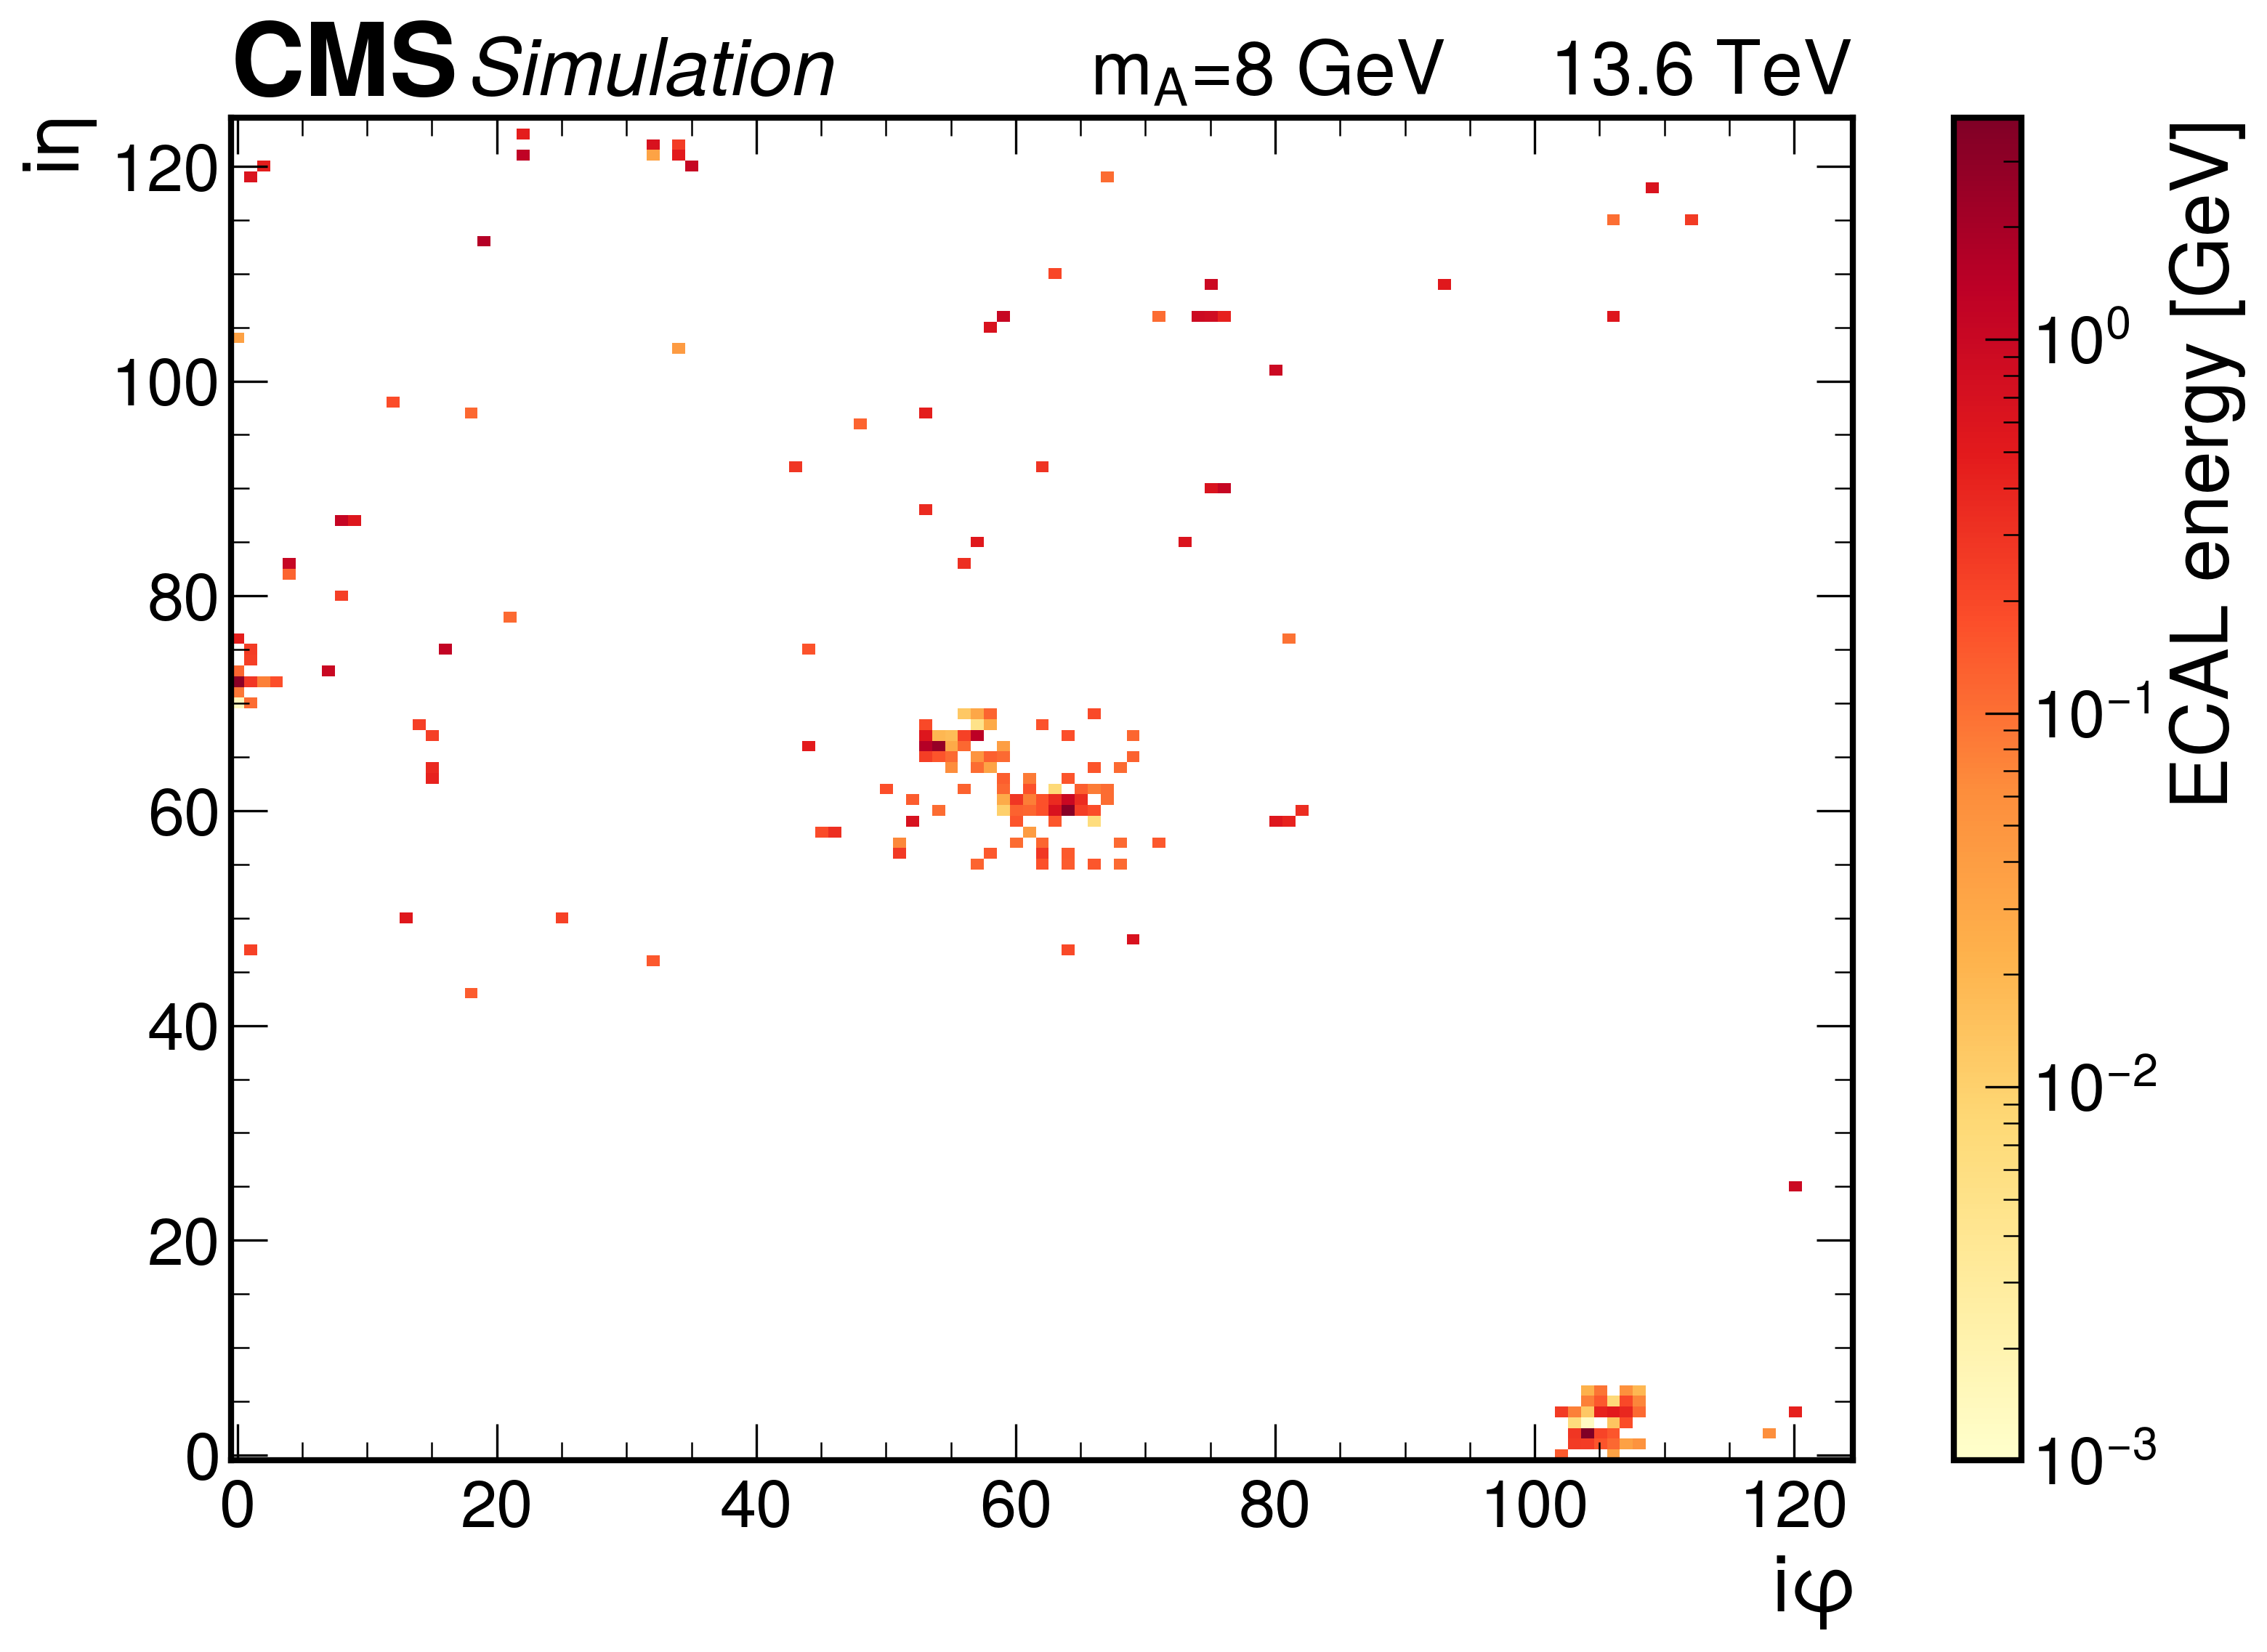

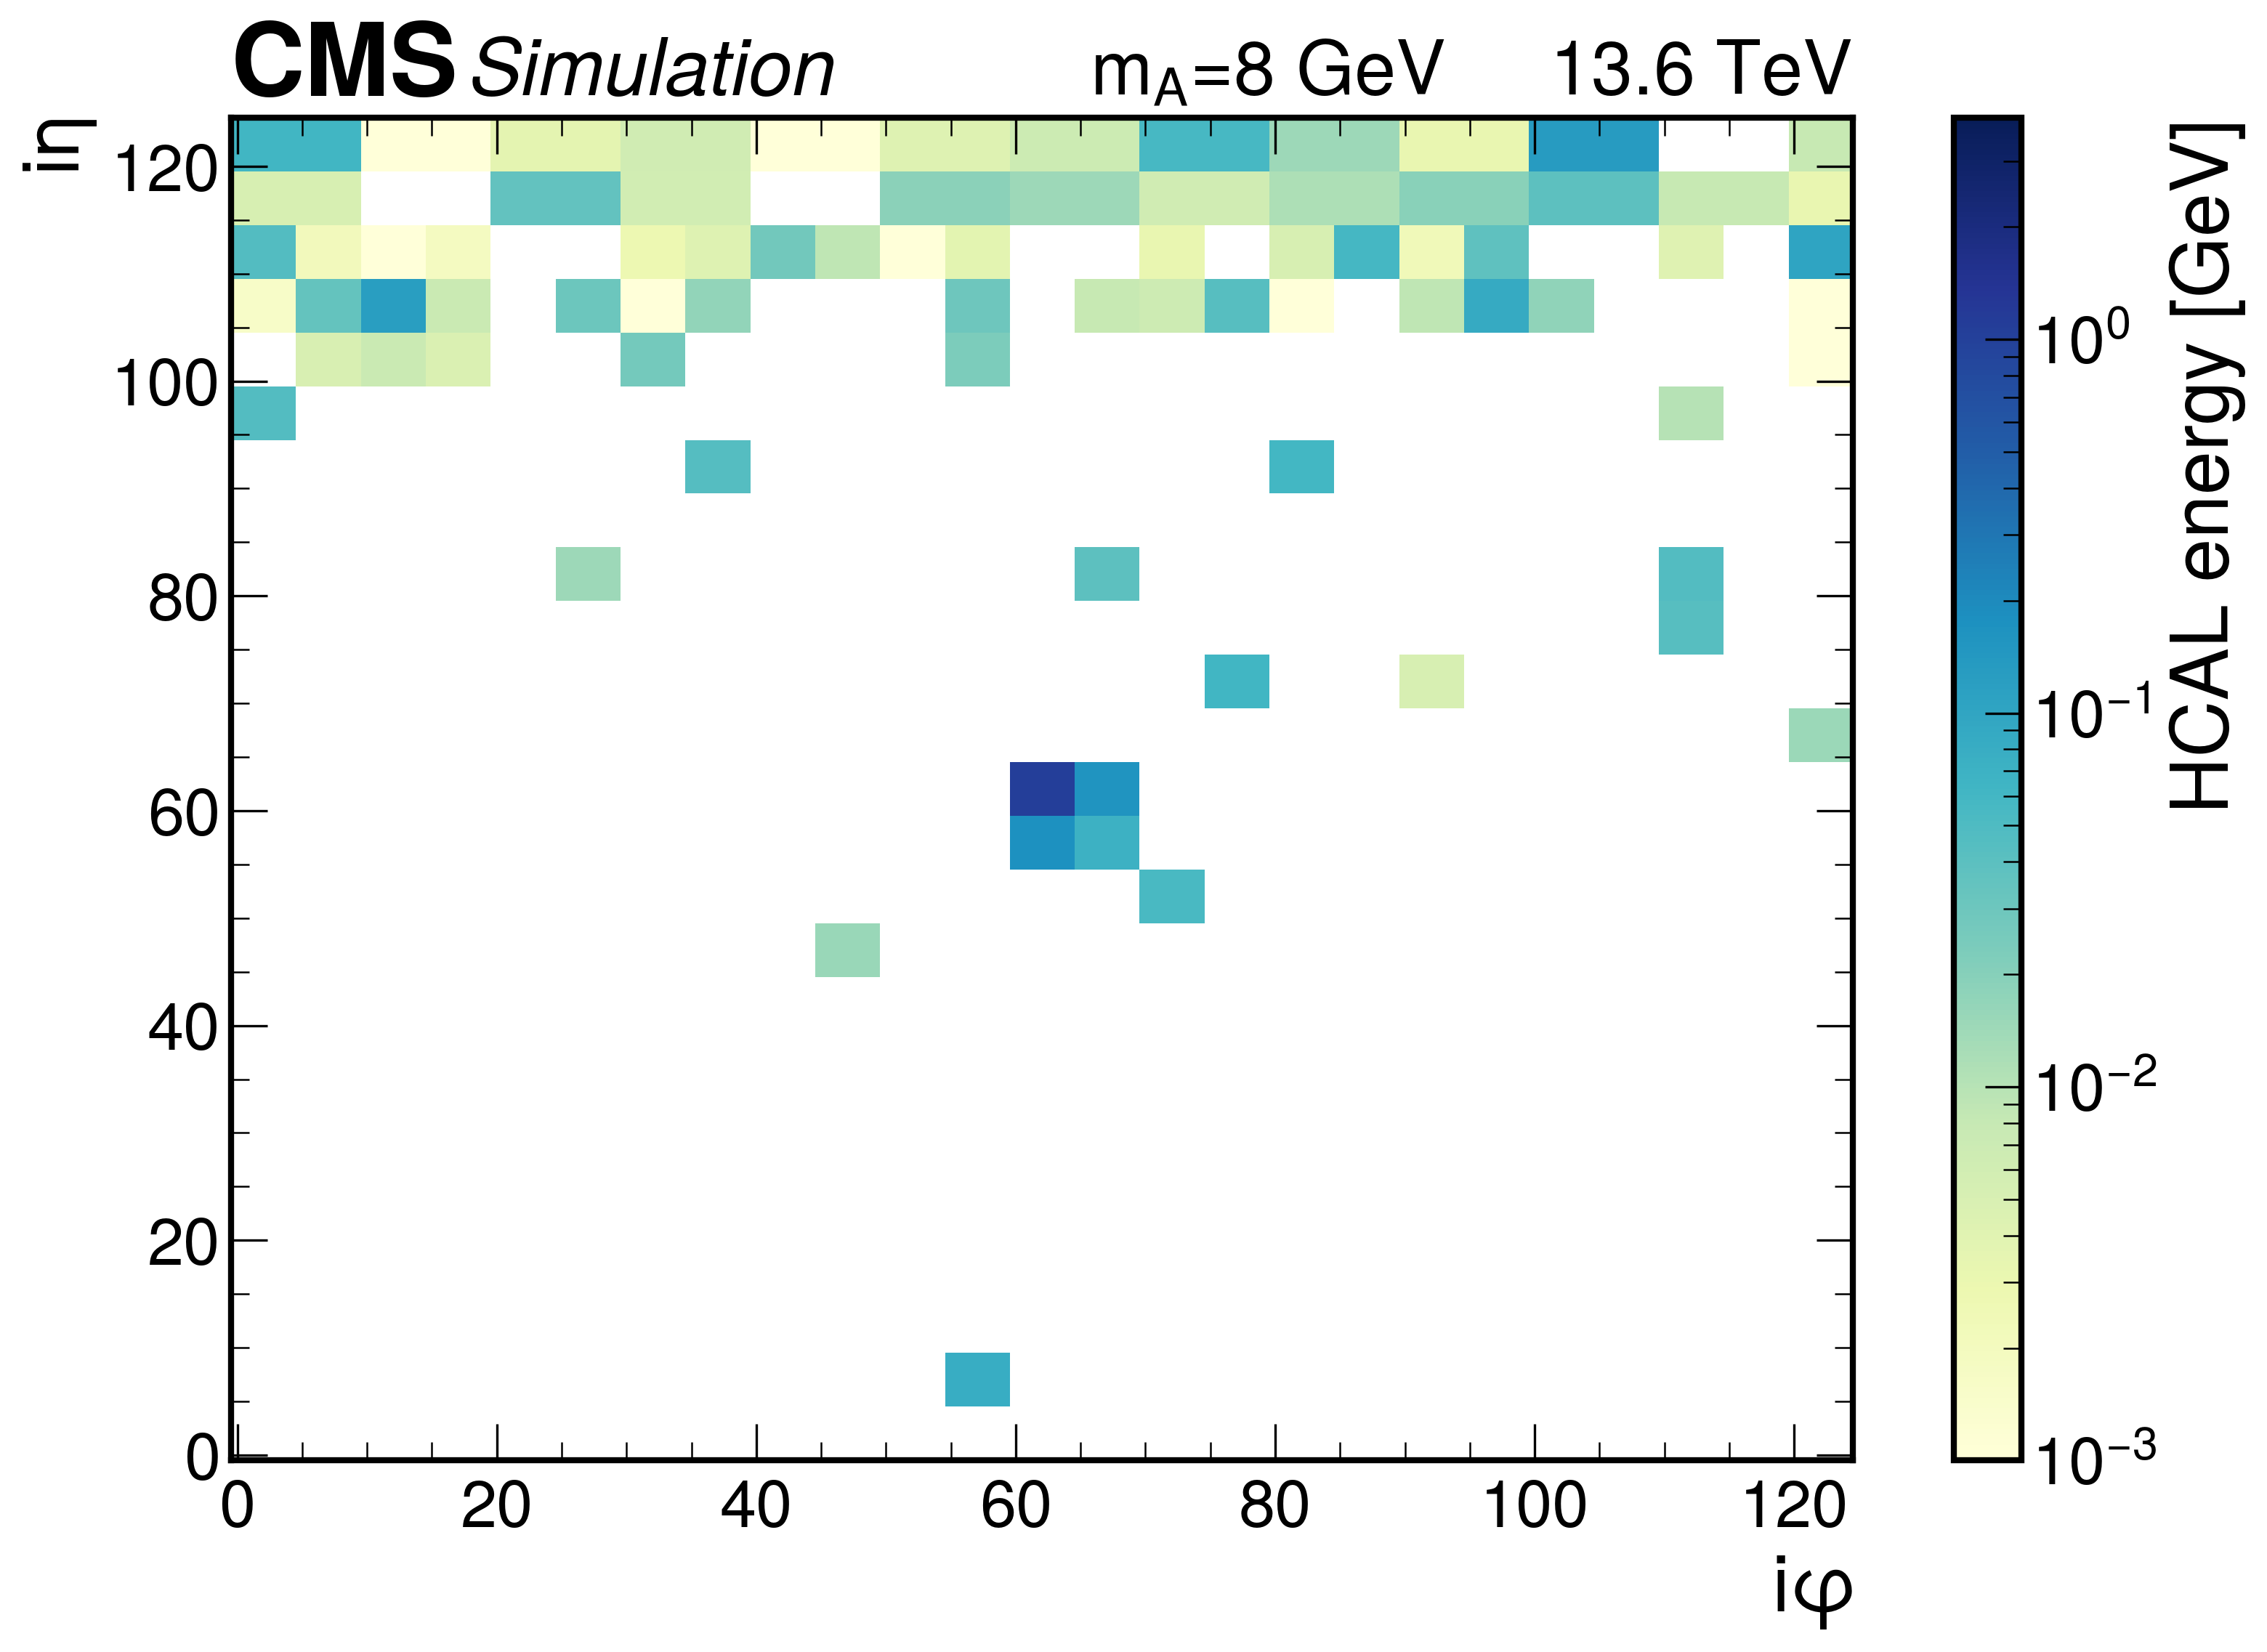

event 4
crope position 1


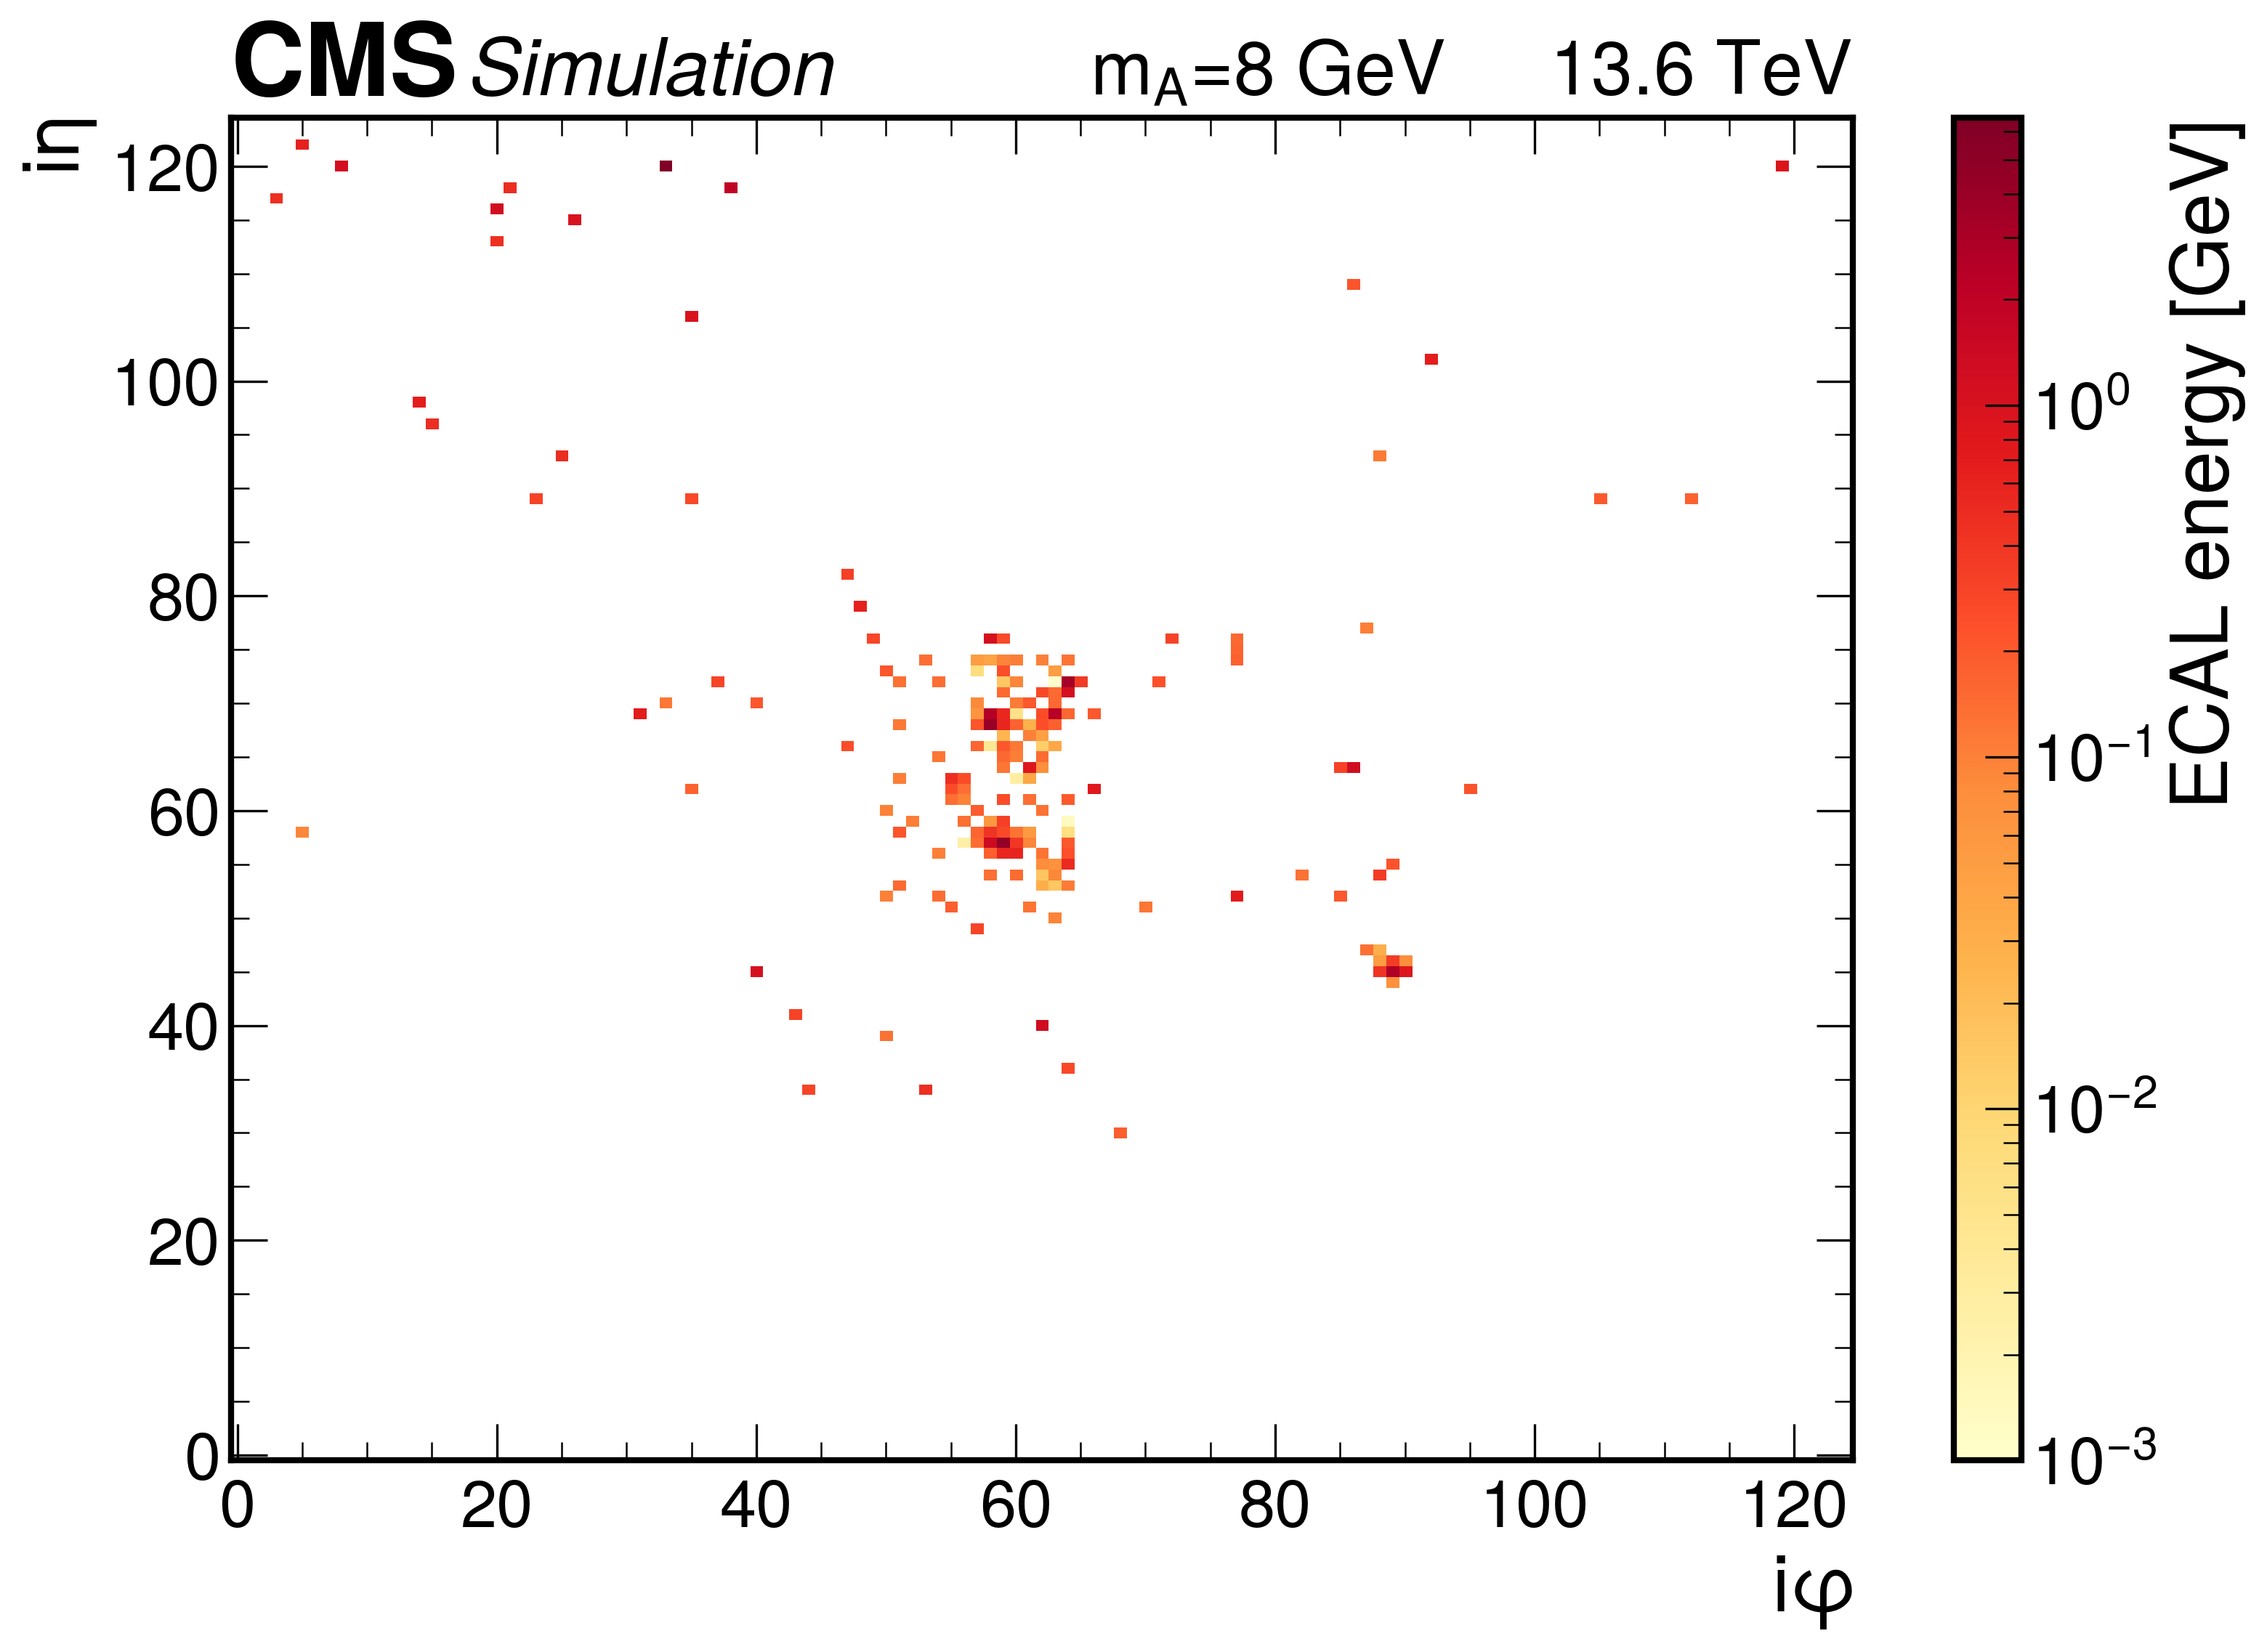

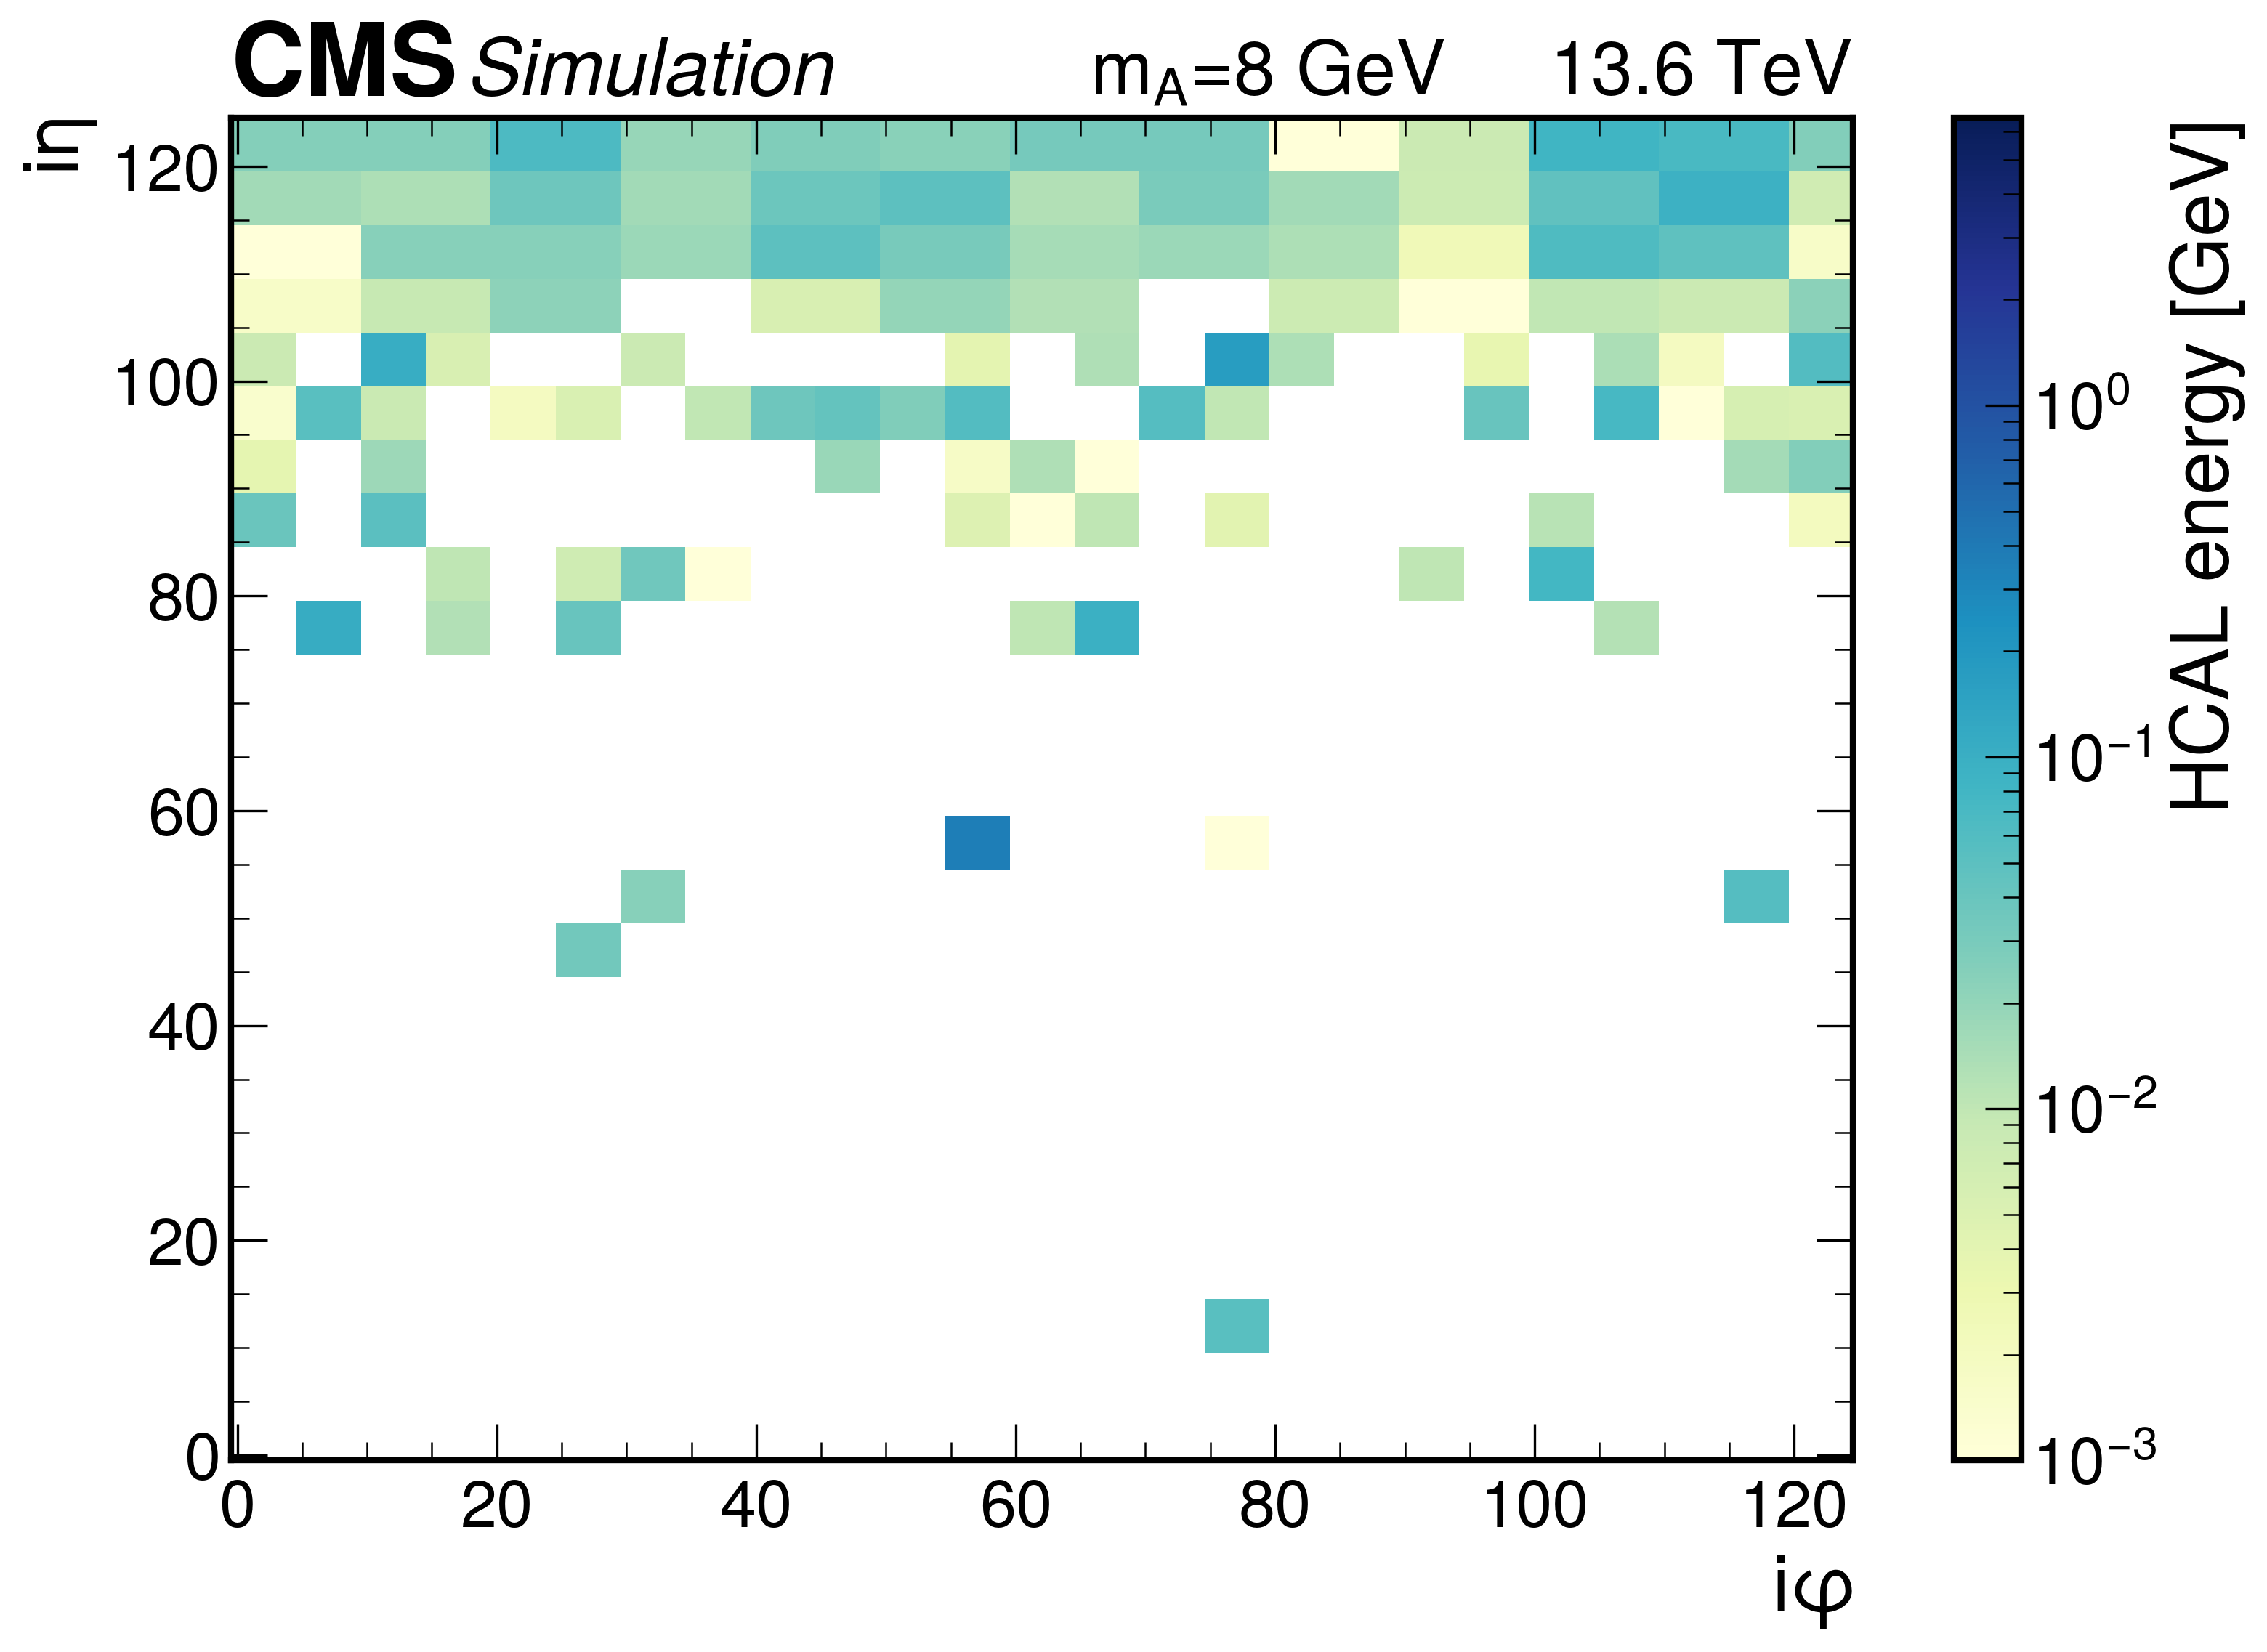

event 31
crope position 0


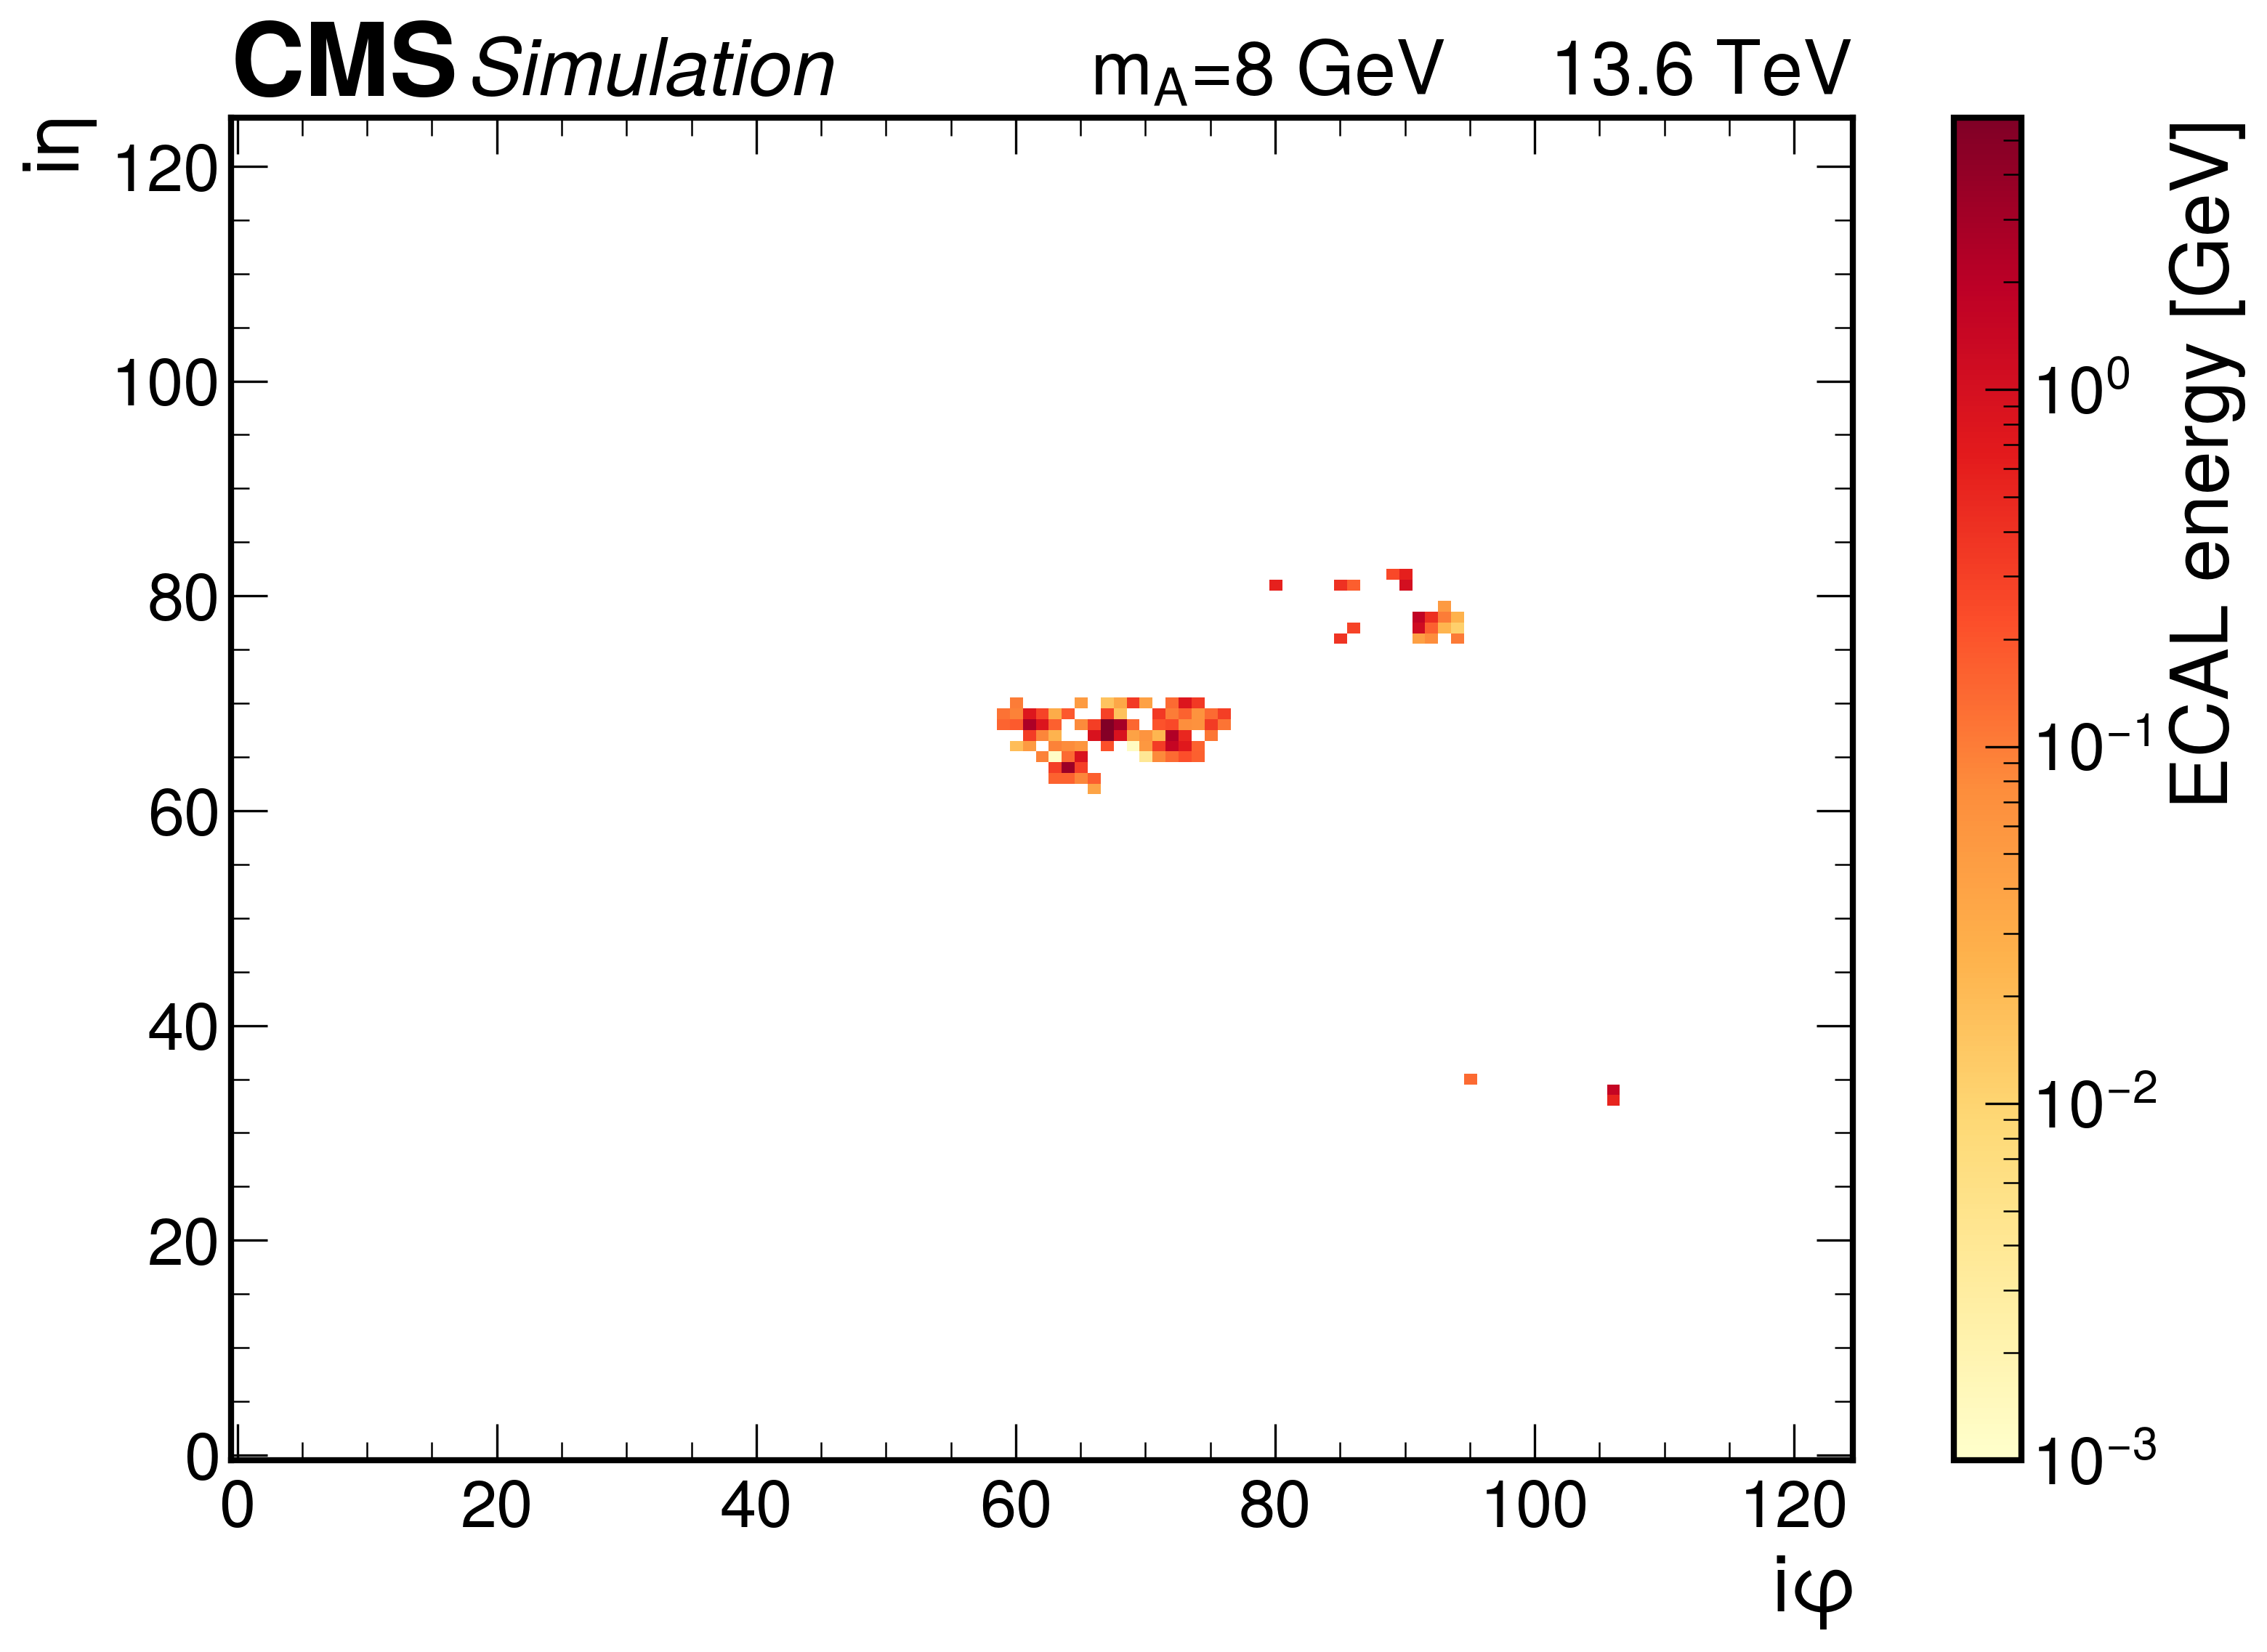

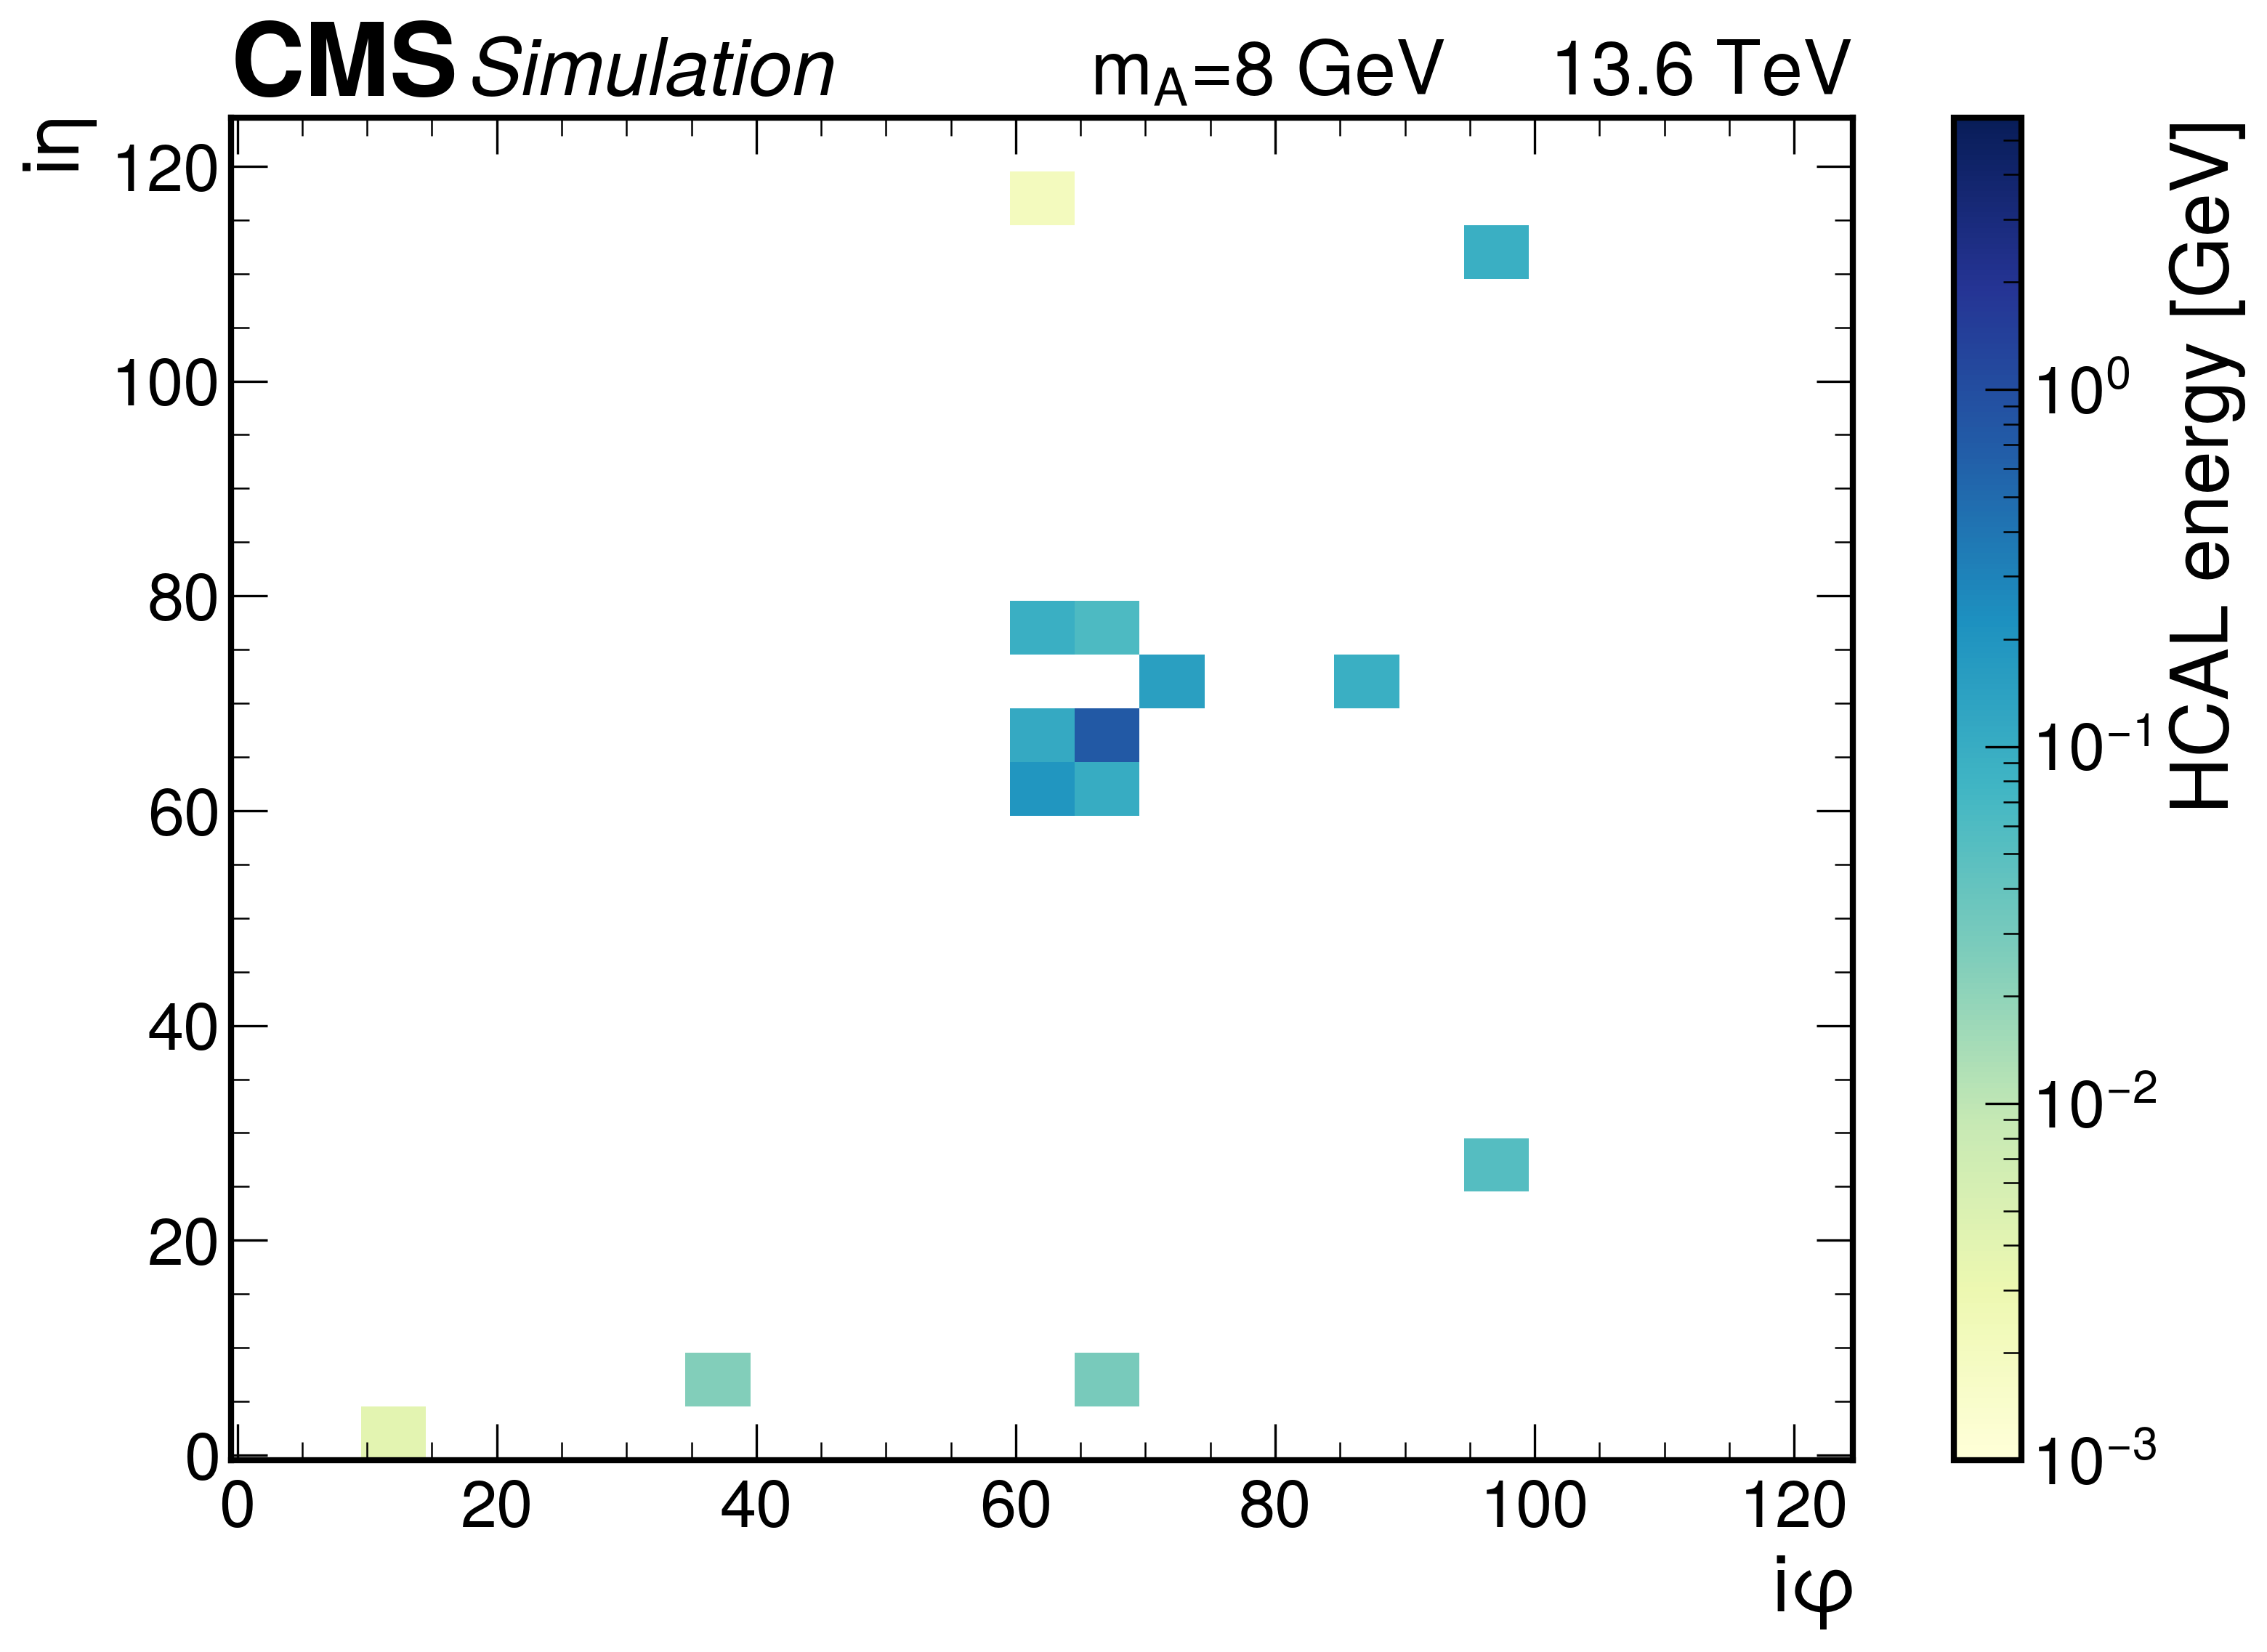

event 31
crope position 1


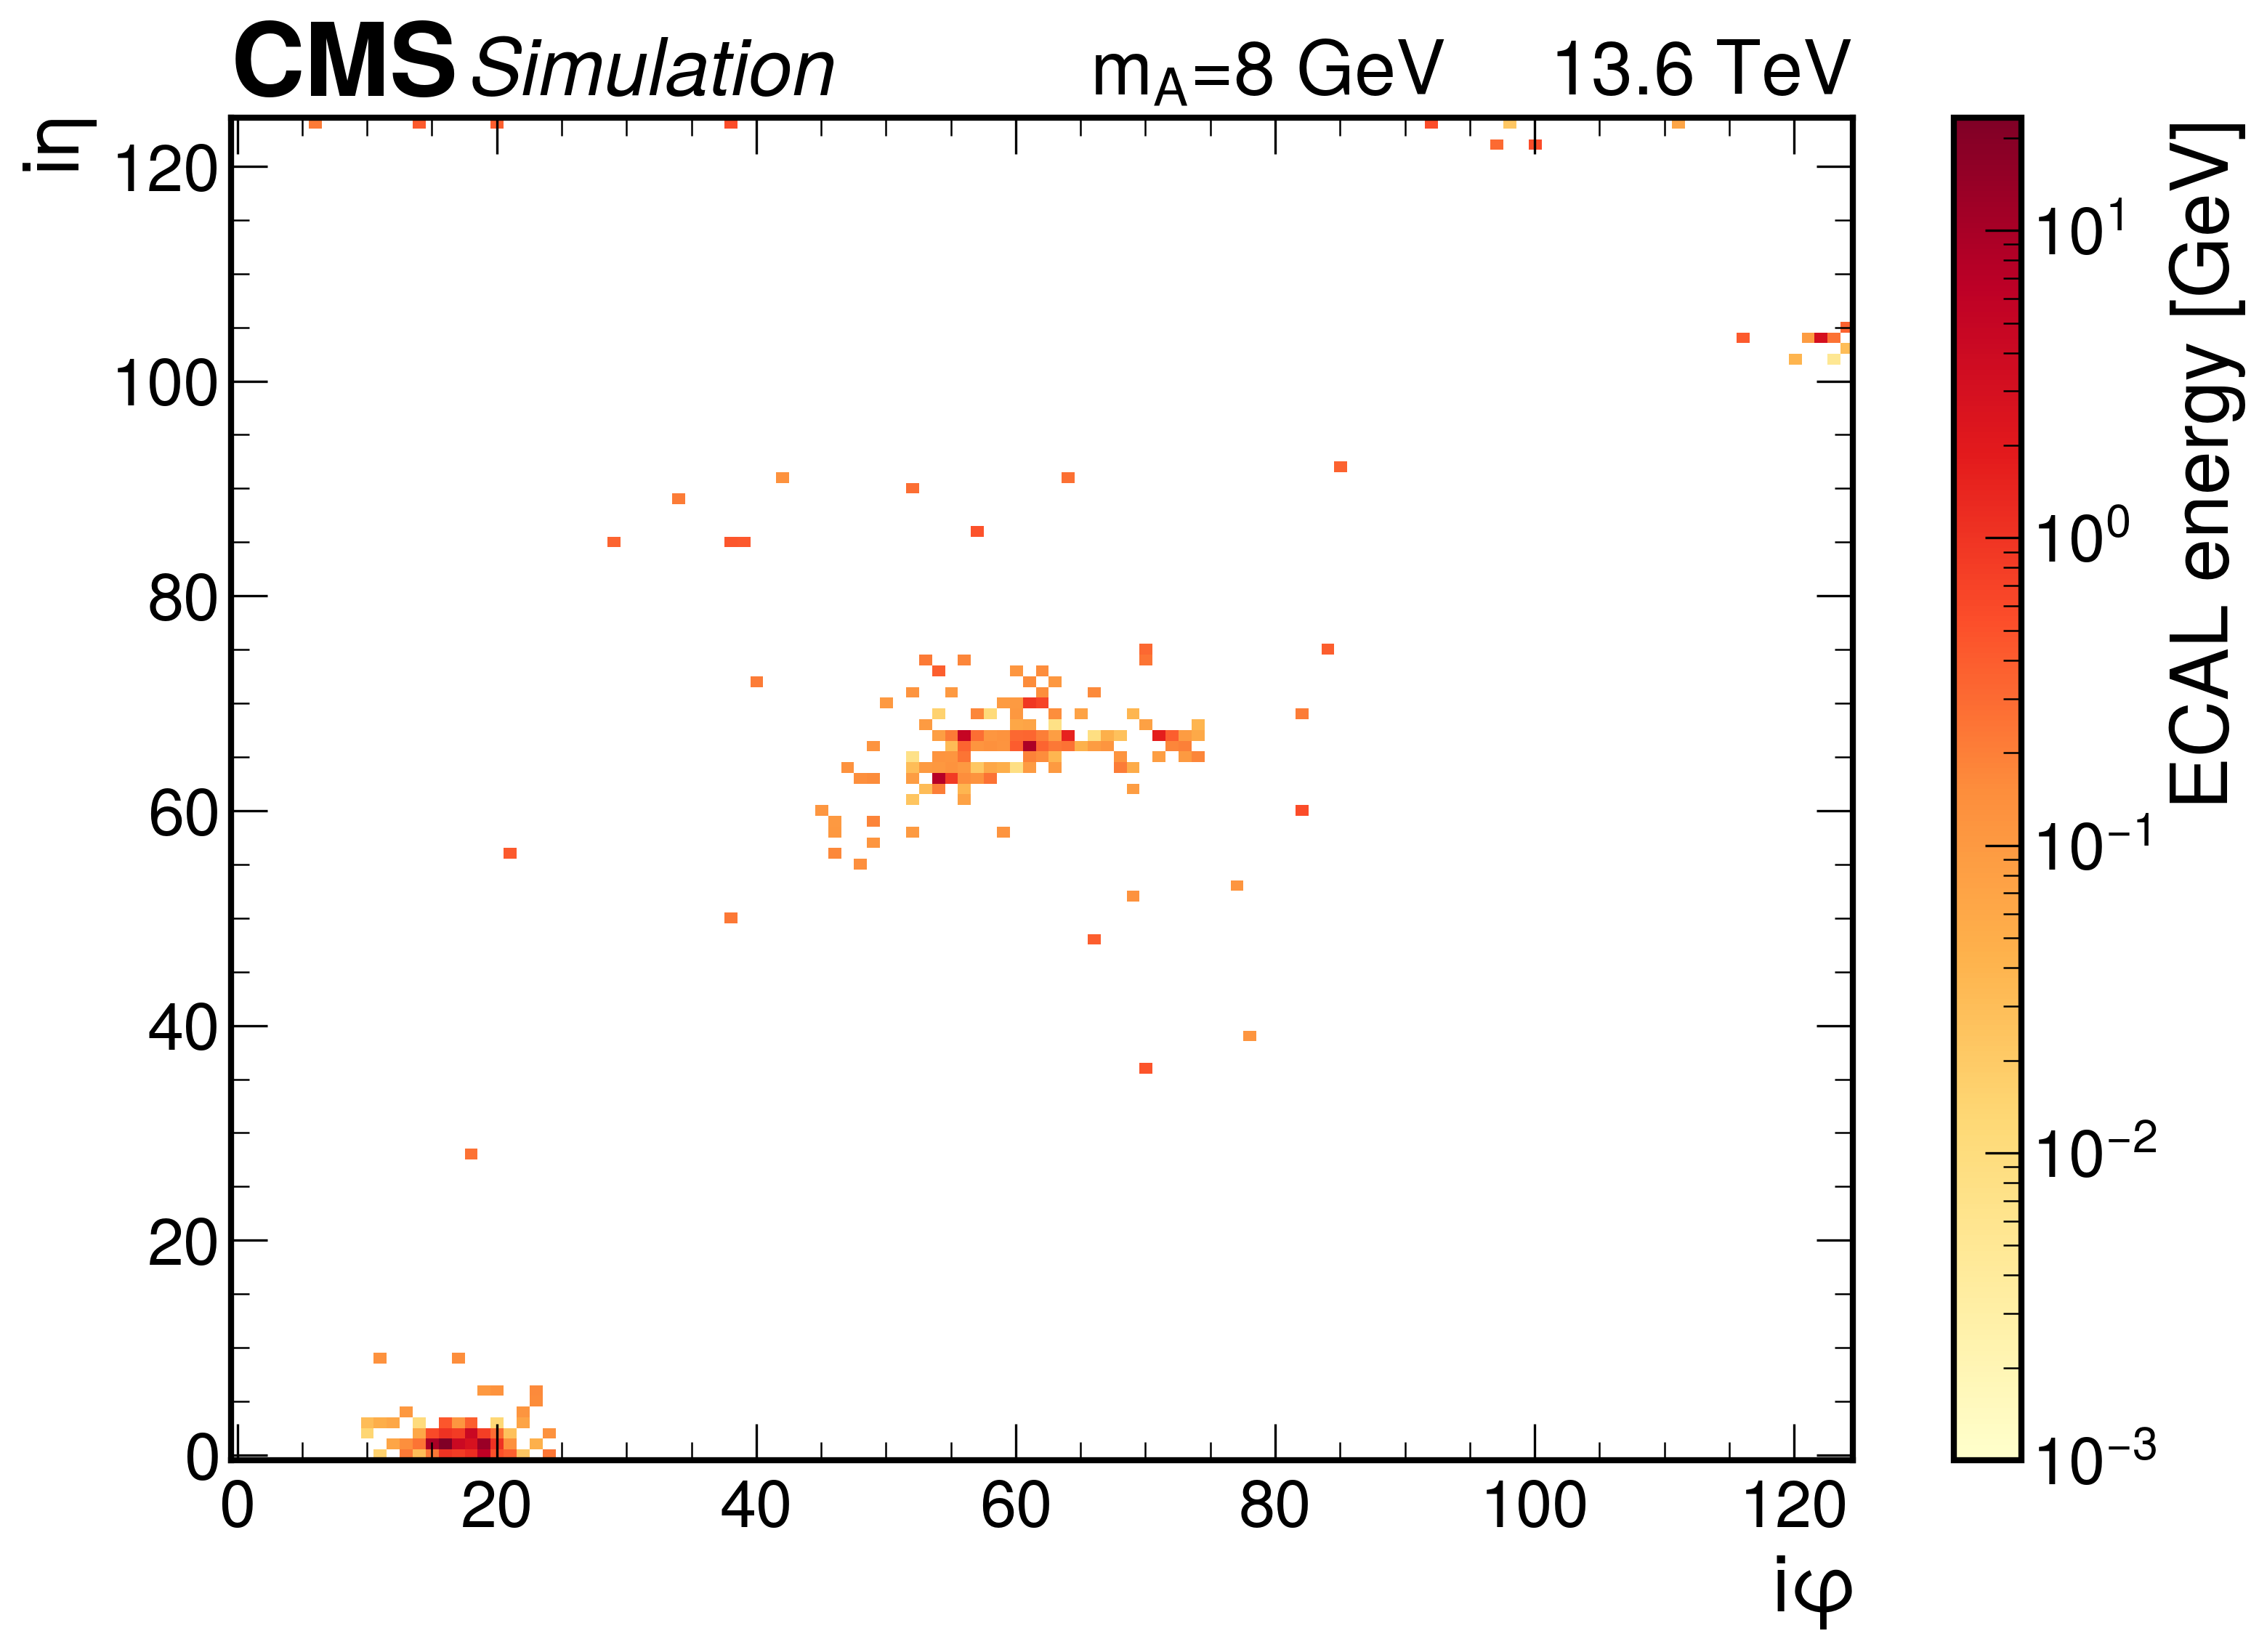

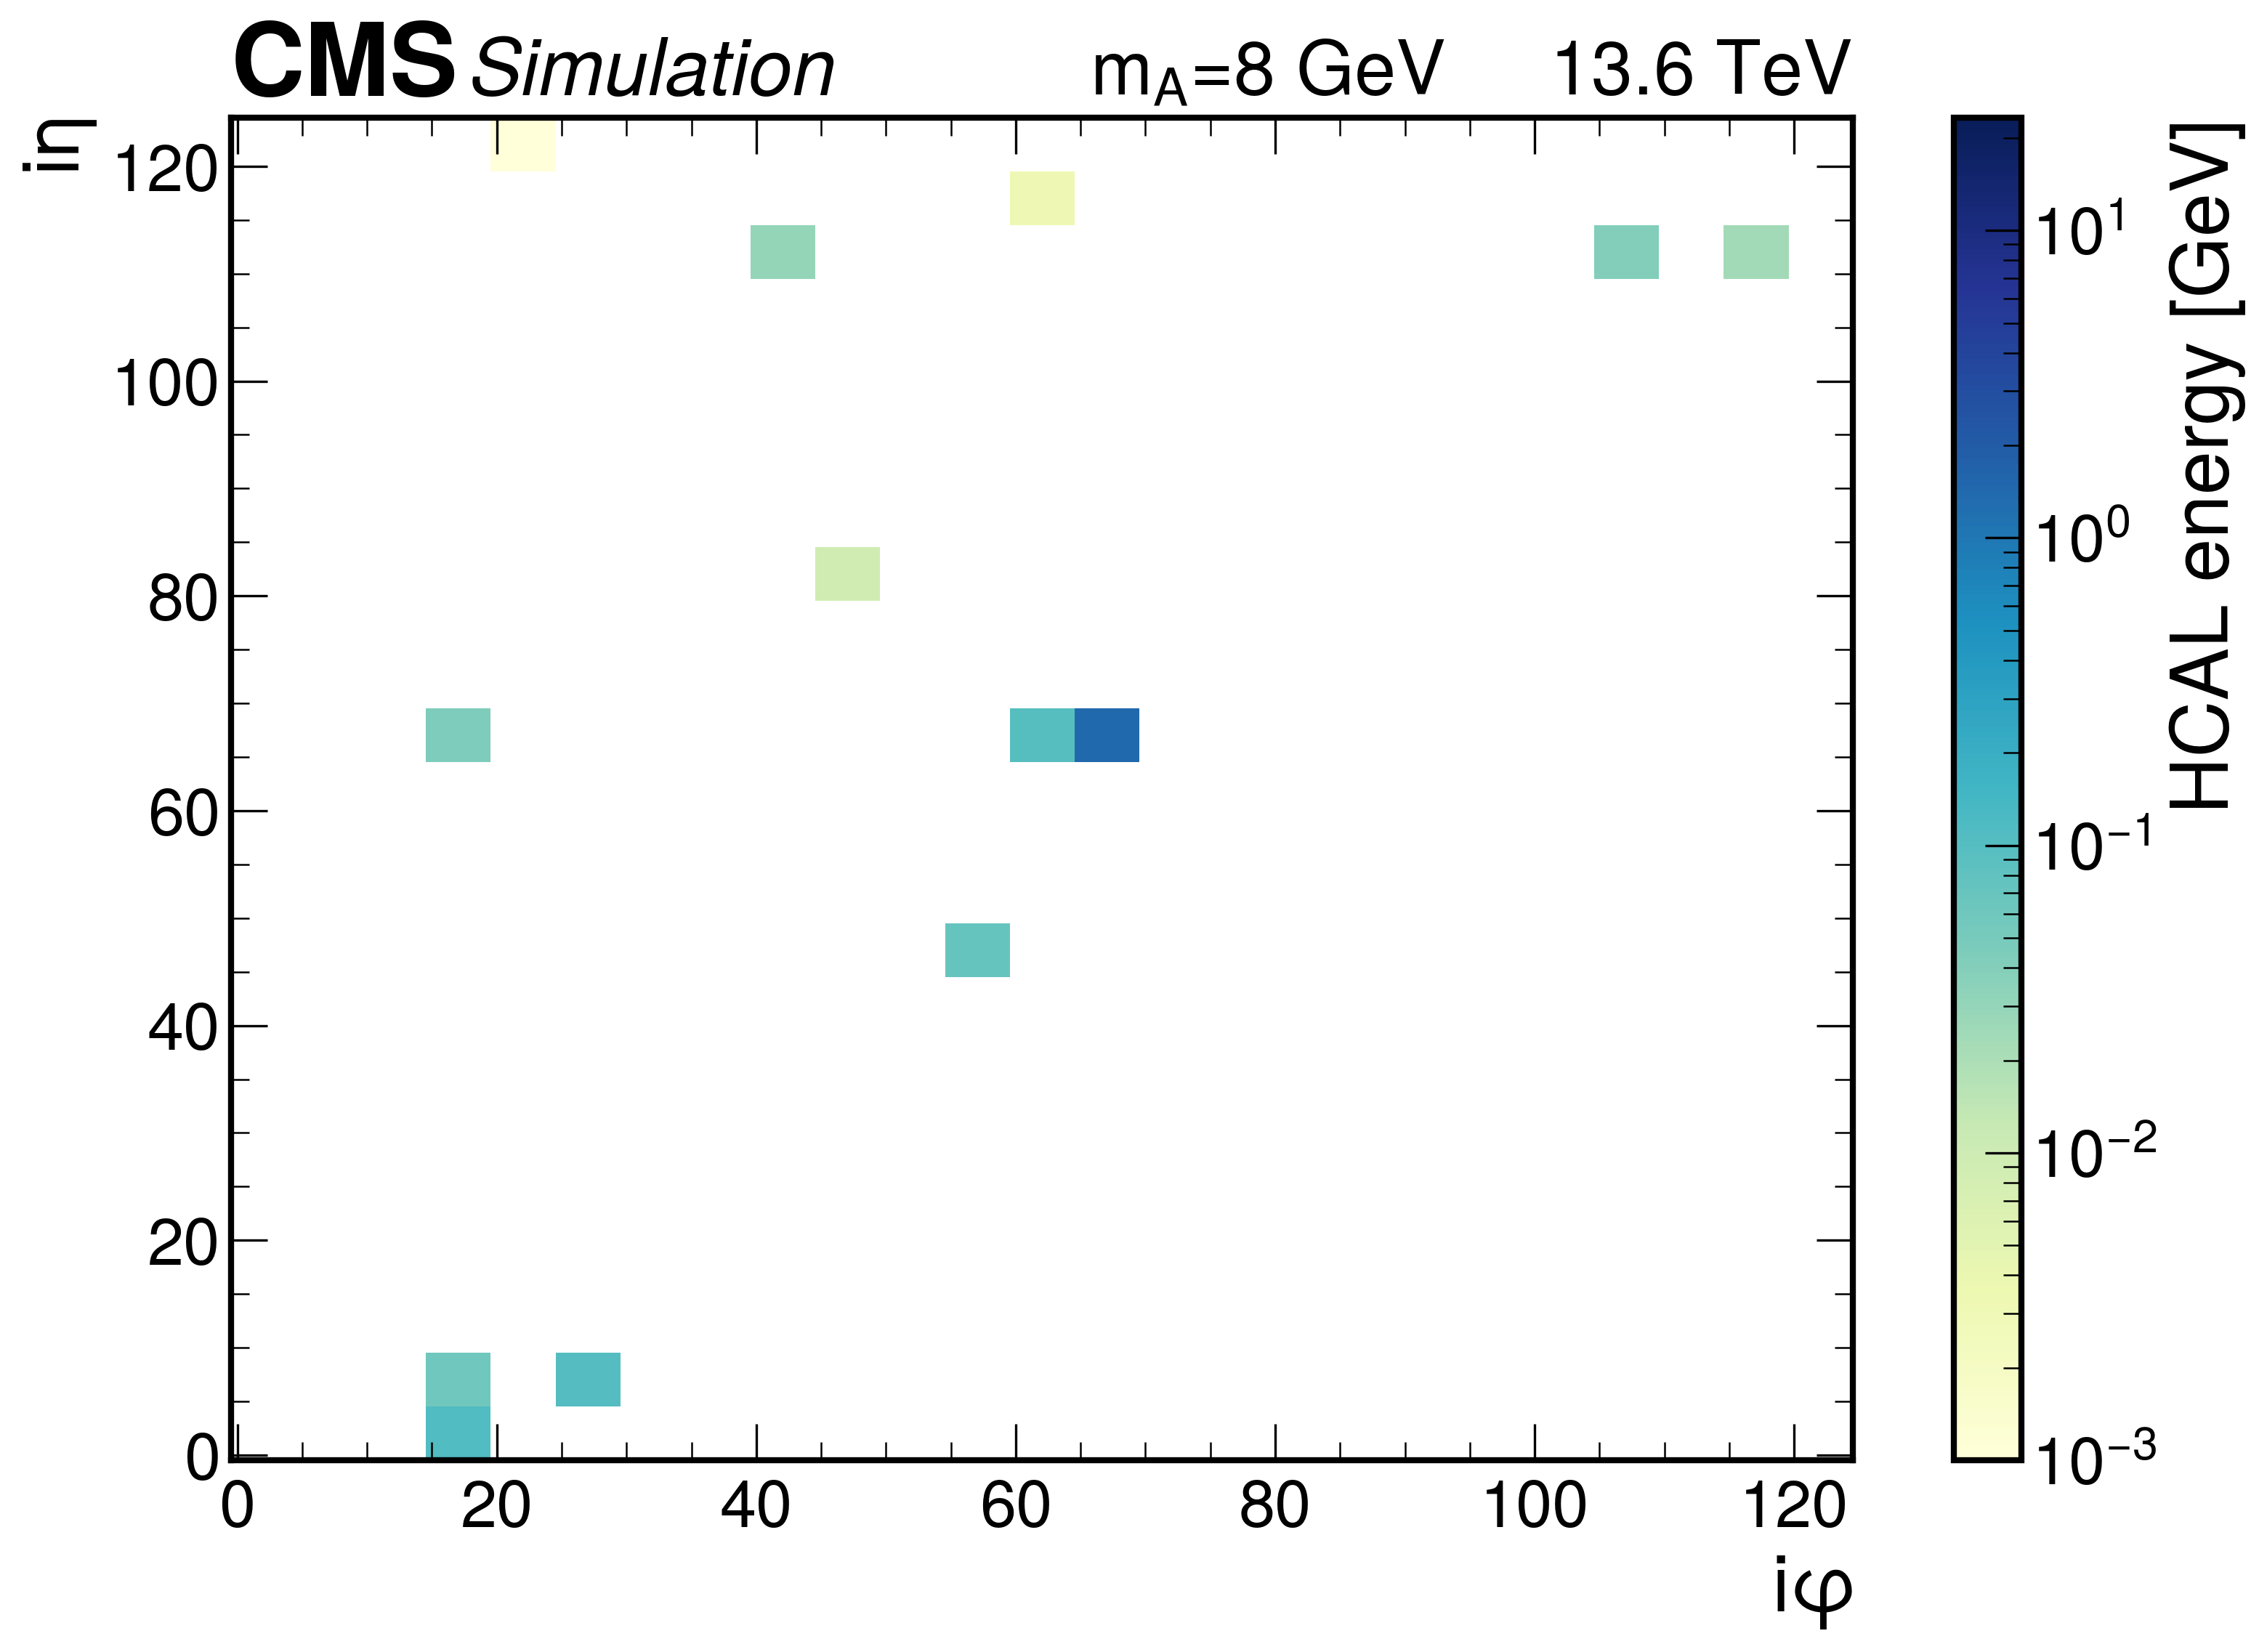

event 31
crope position 2


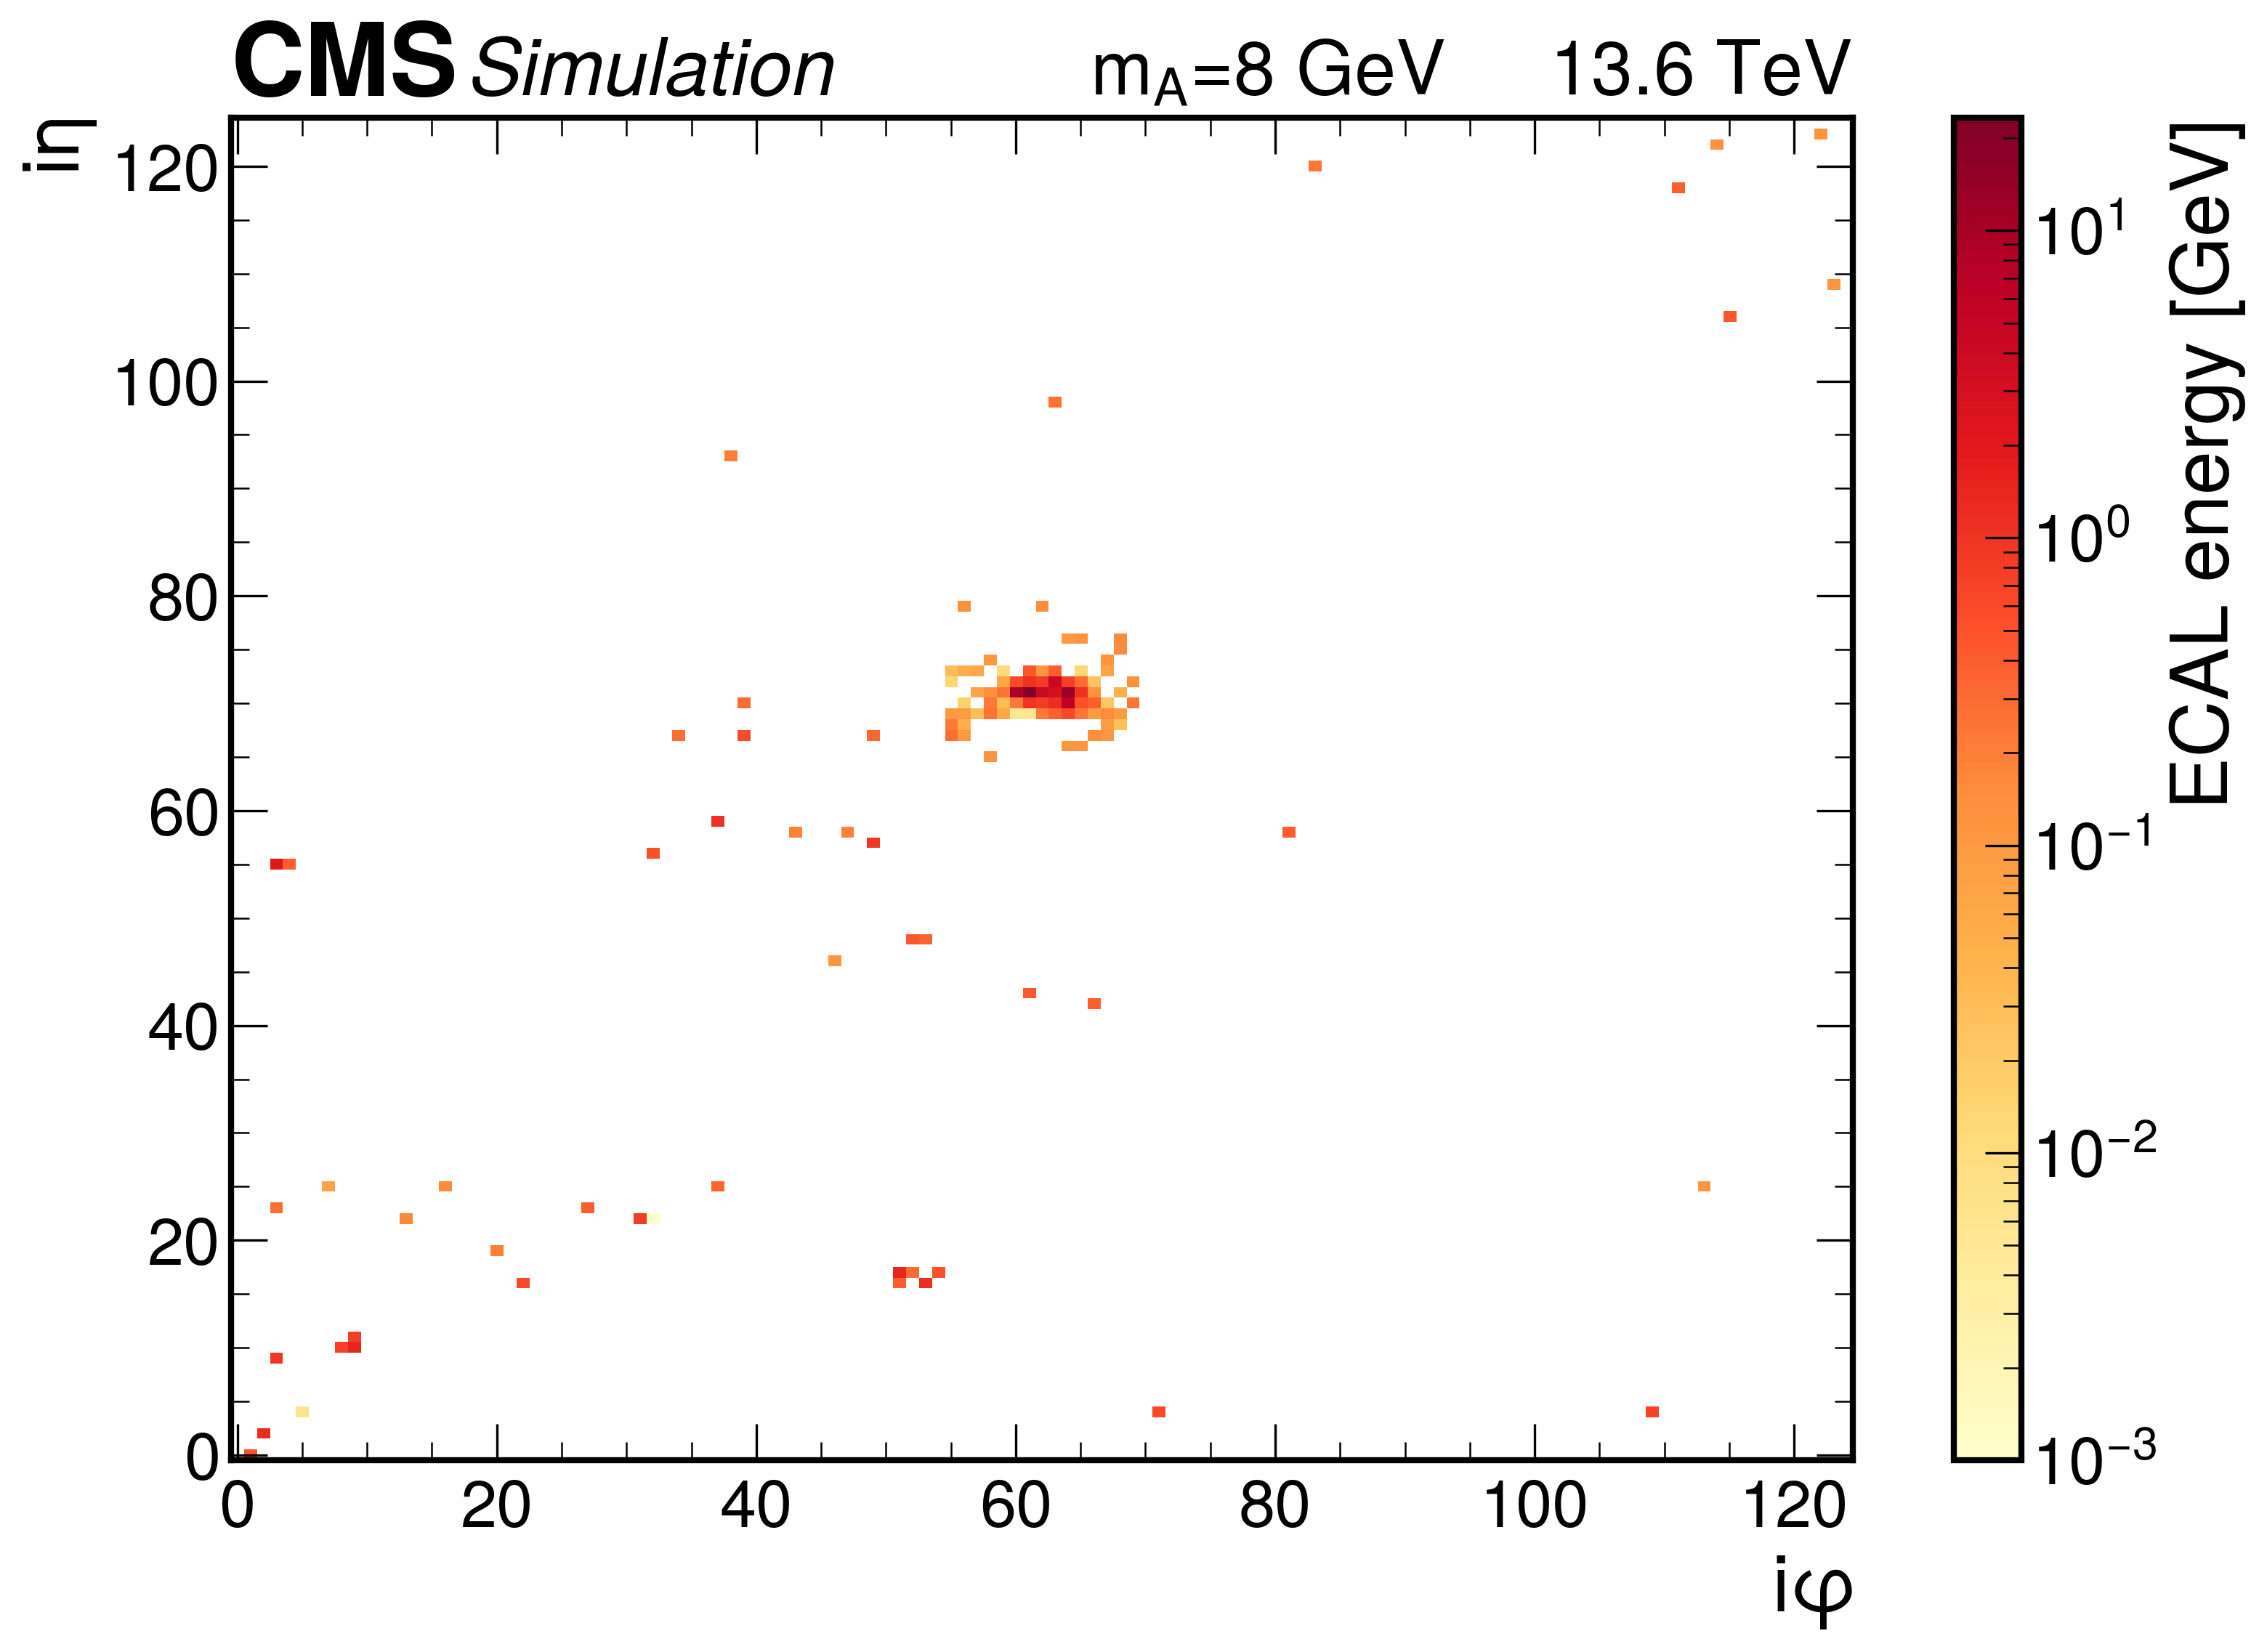

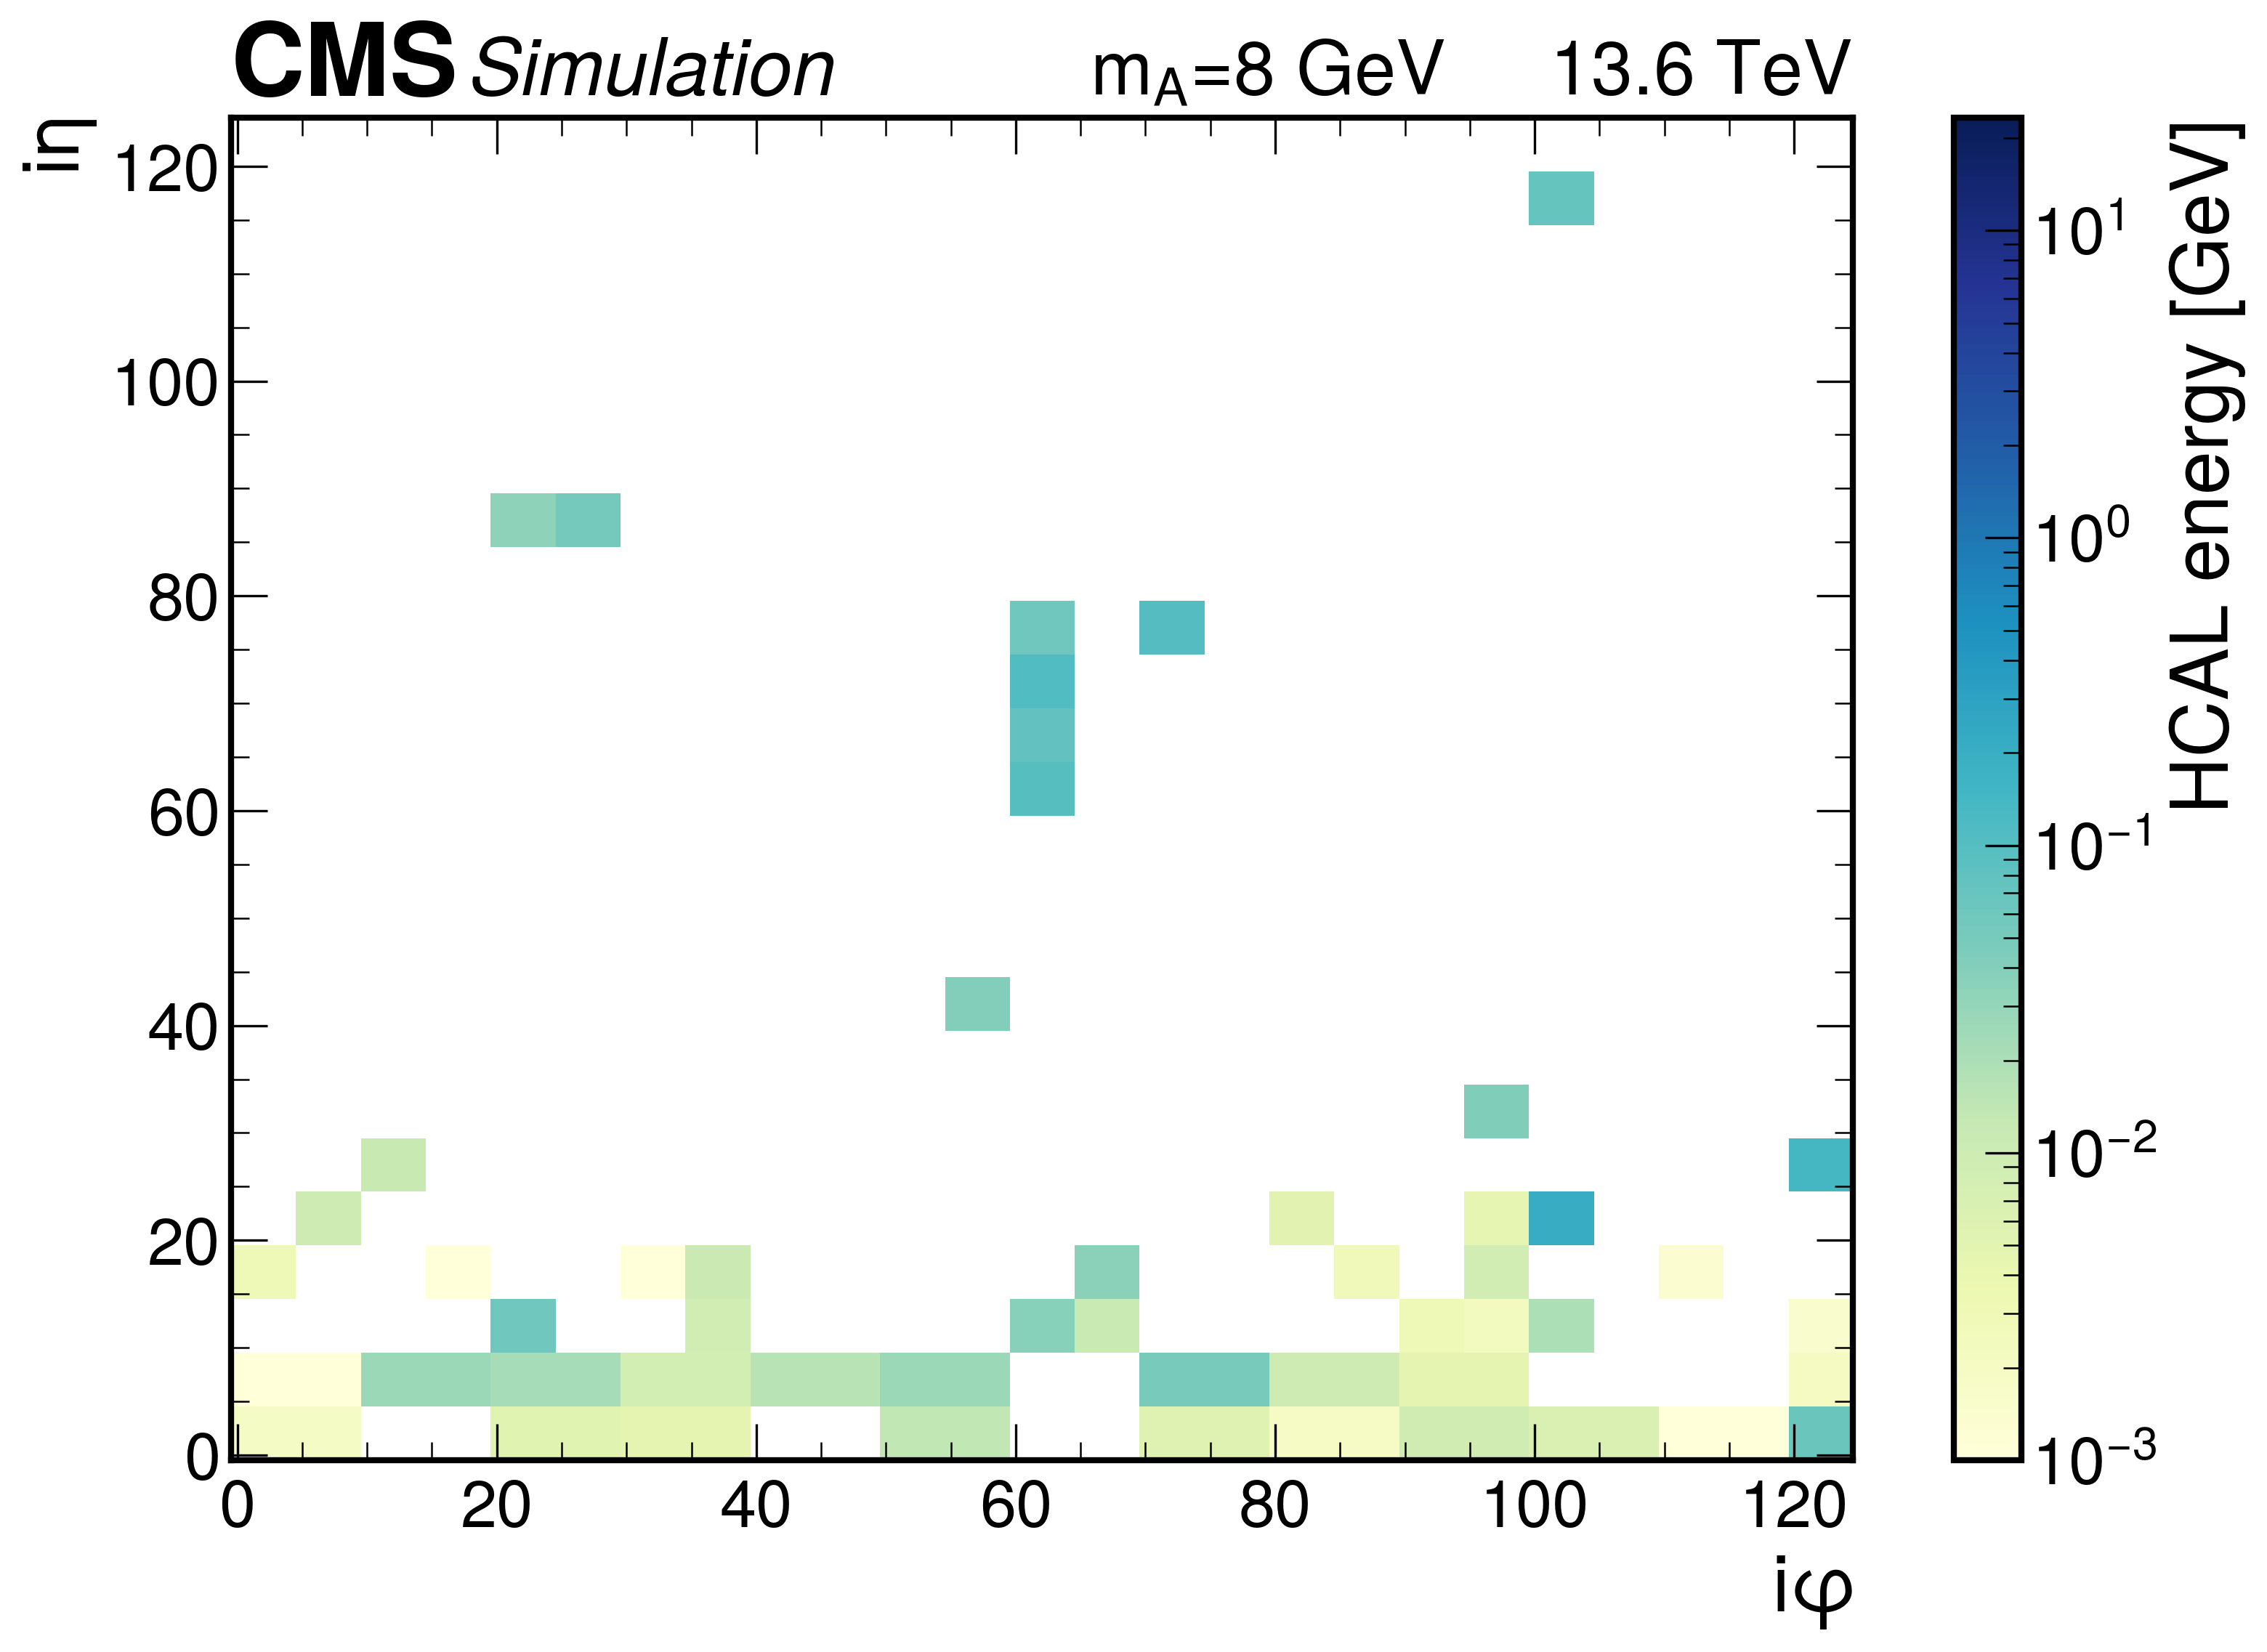

In [29]:
file = uproot.open("../analysis_run3/Data_for_plots/HToAAto4Tau_signal_sample_m8_numEvent500.root")
RHTree = file["fevt/RHTree"]
branches = RHTree.arrays(entry_start=0, entry_stop=35)
for i in [4,31]:
    plotJet_single_layer_cal(i,8)


event 67
crope position 0


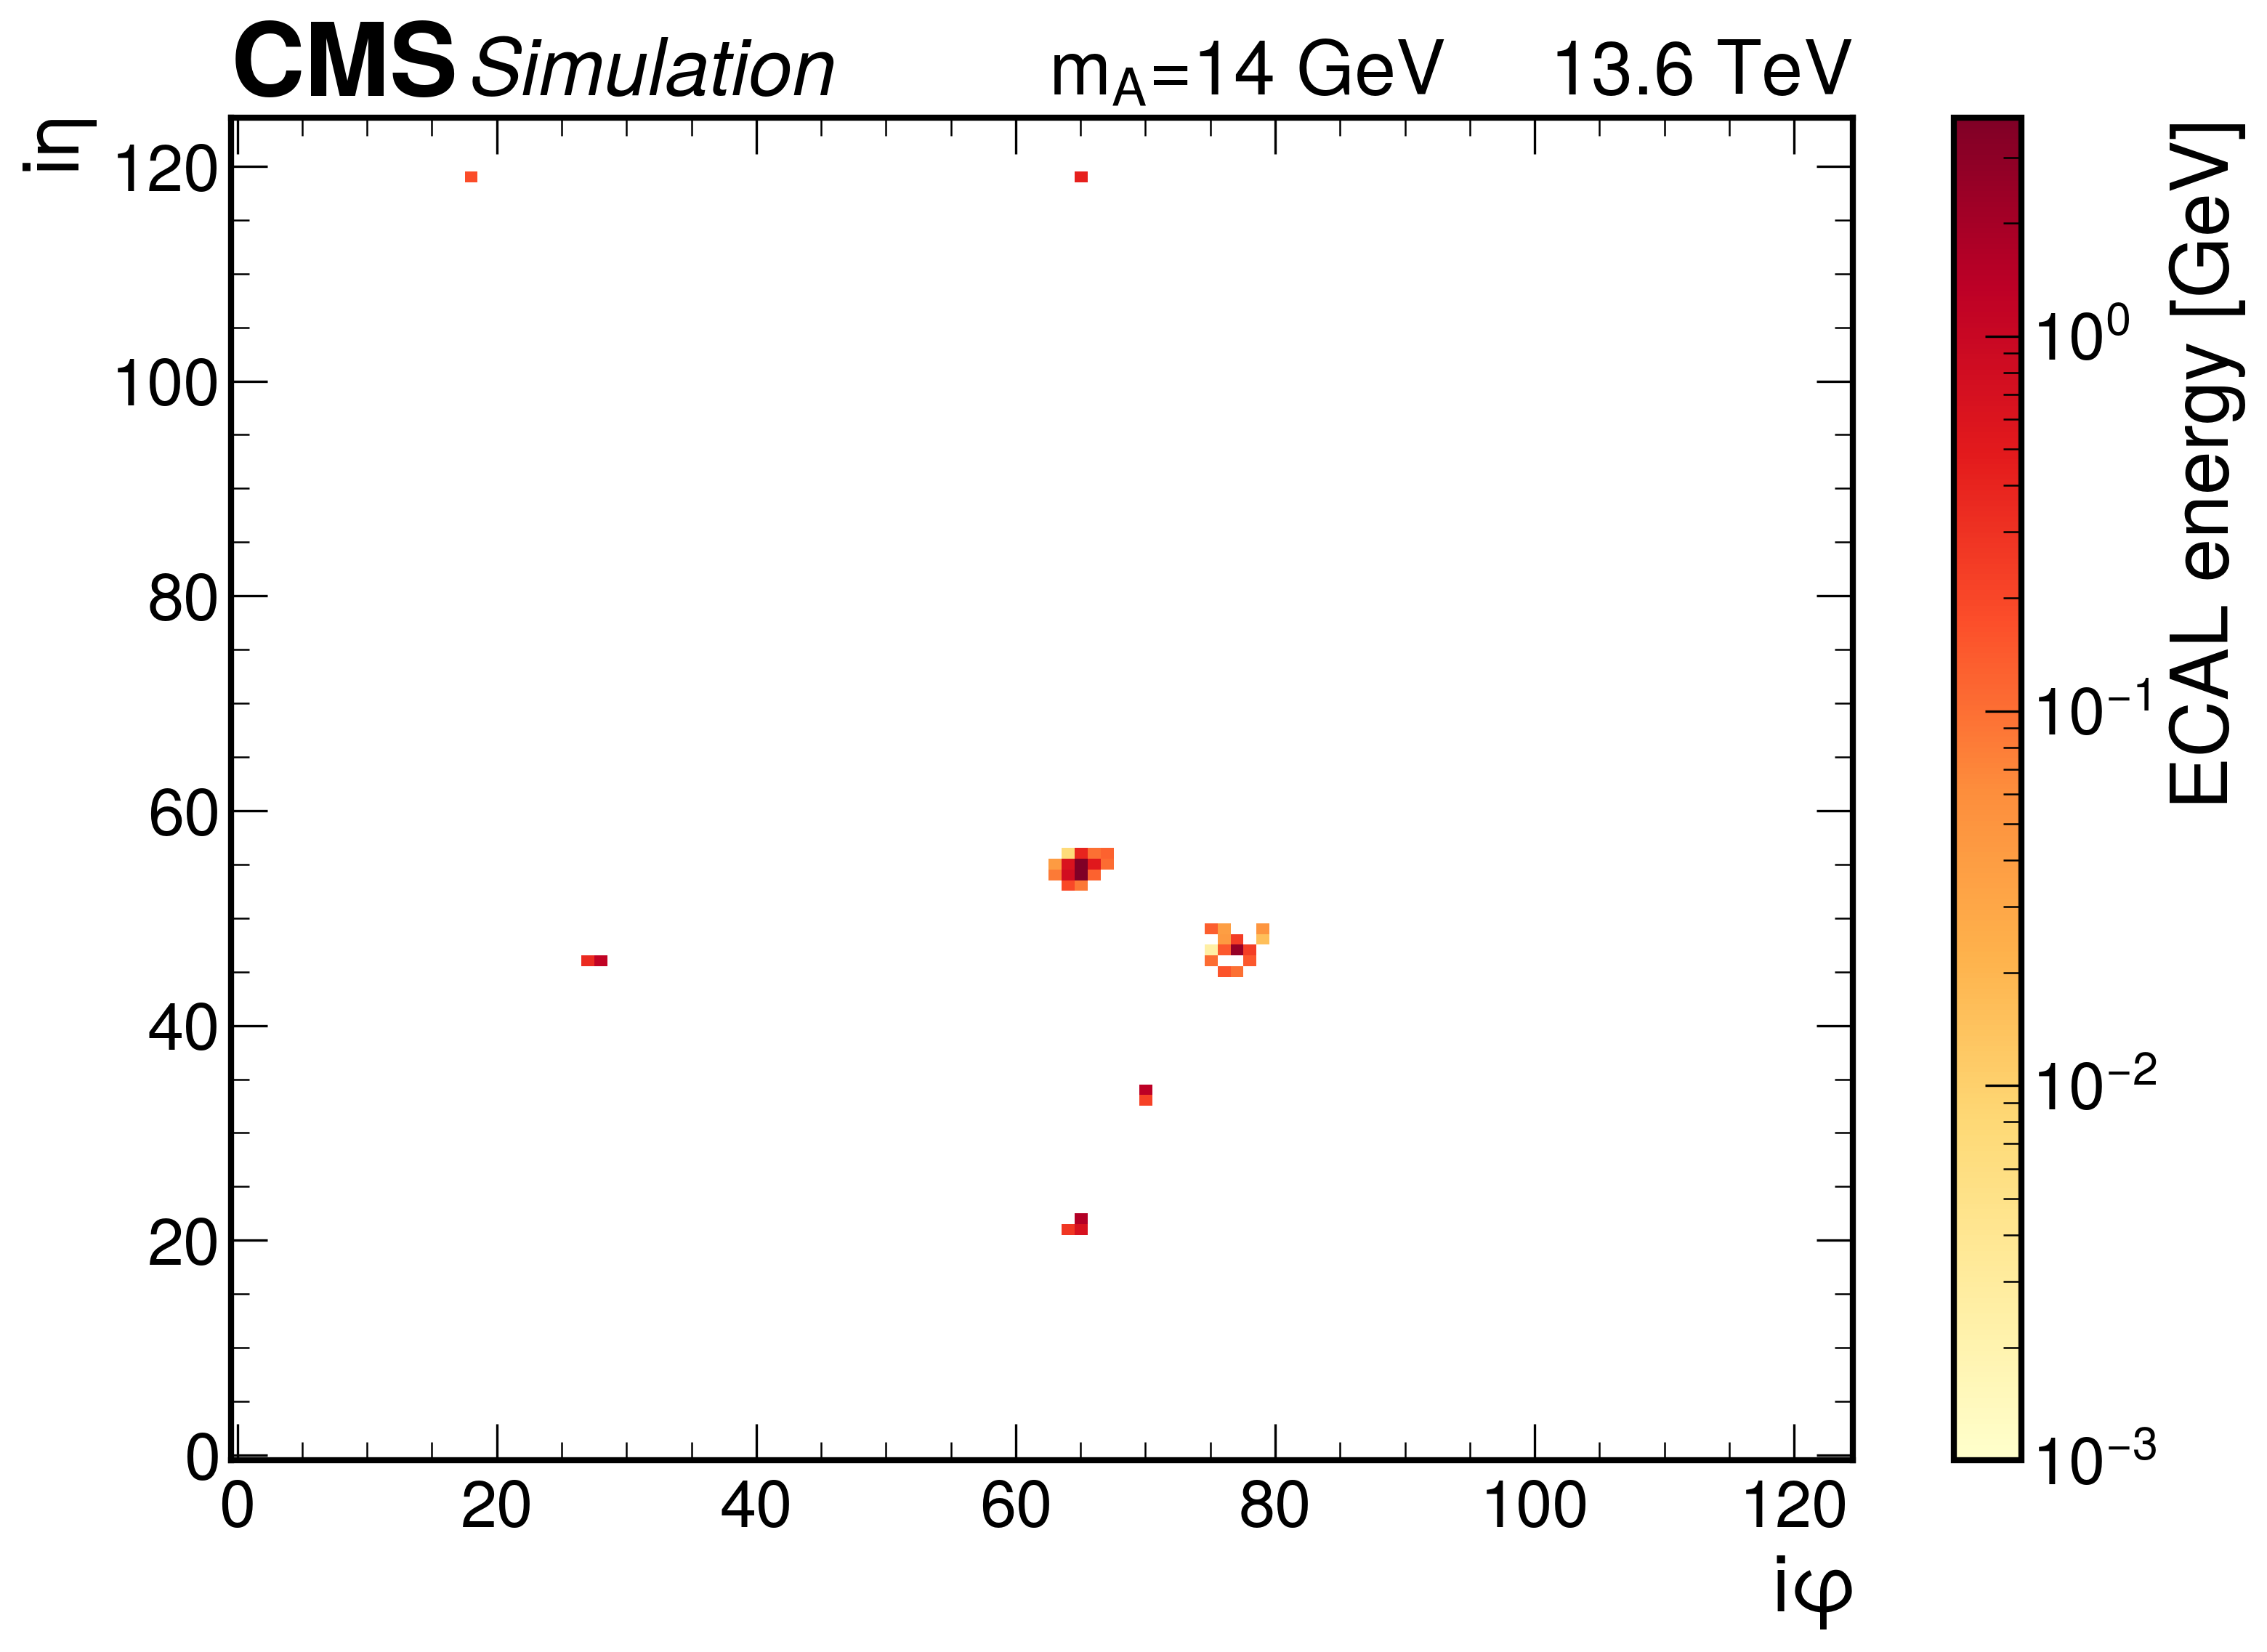

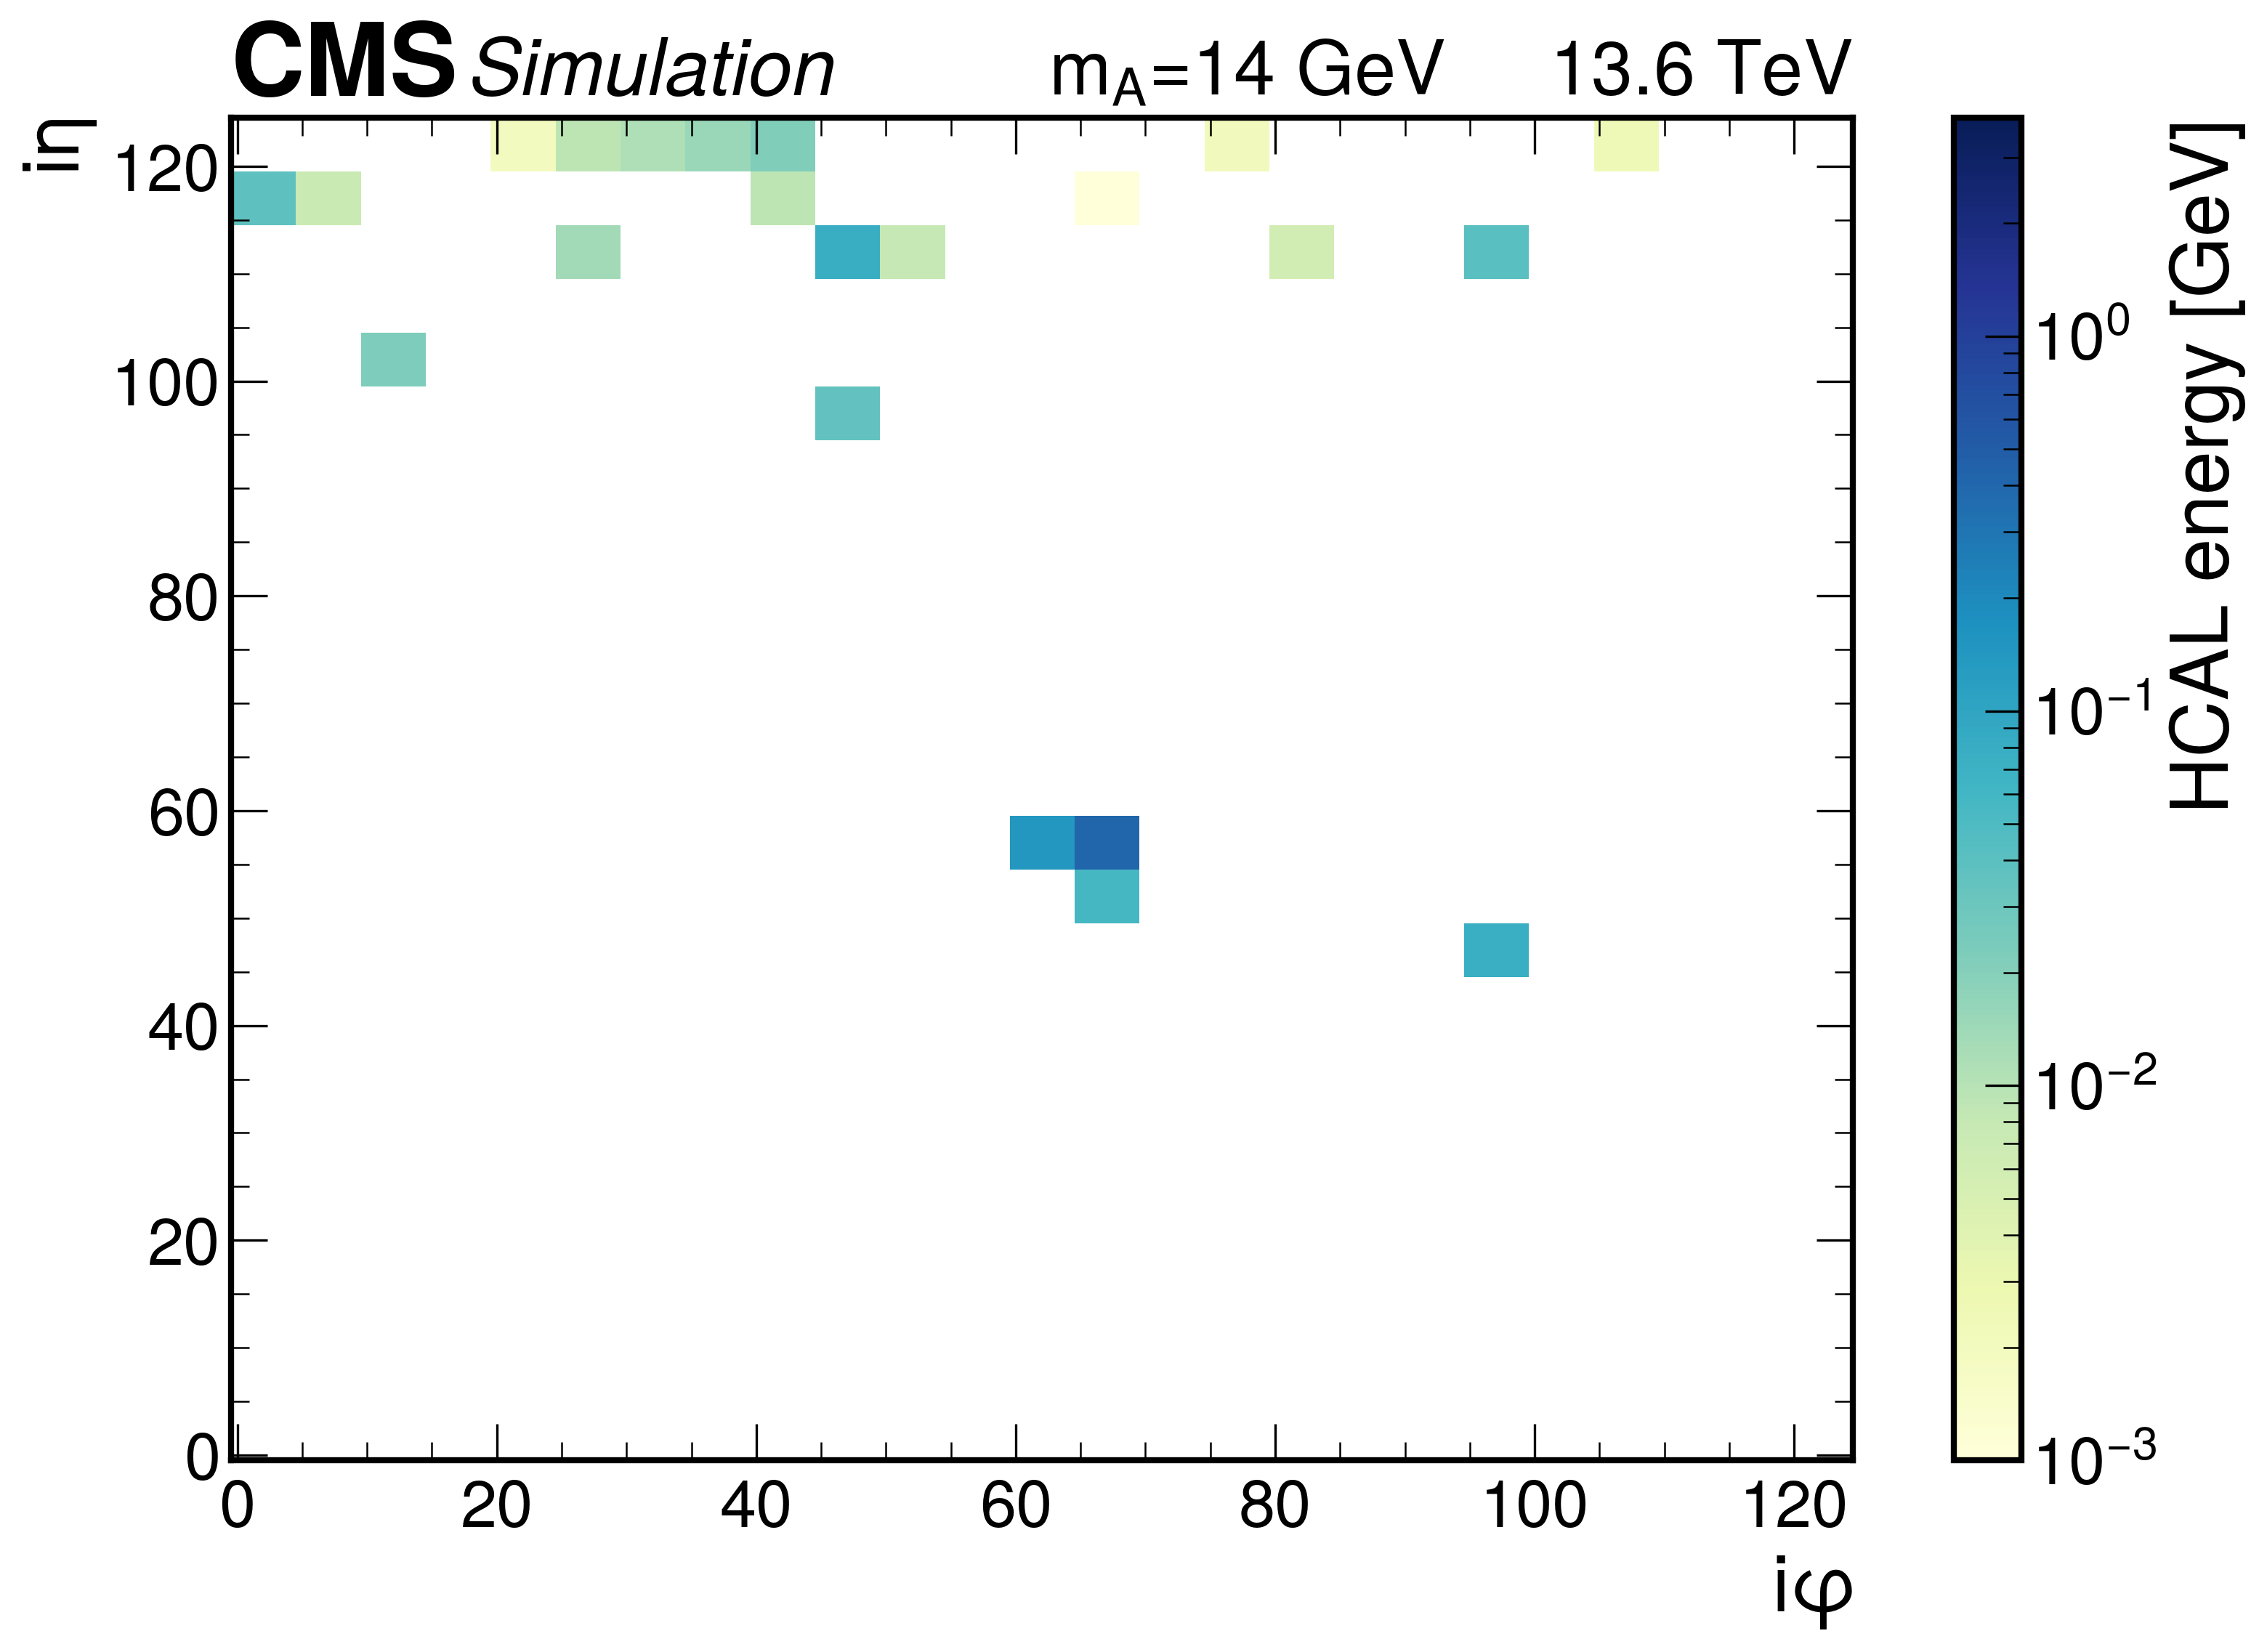

event 67
crope position 1


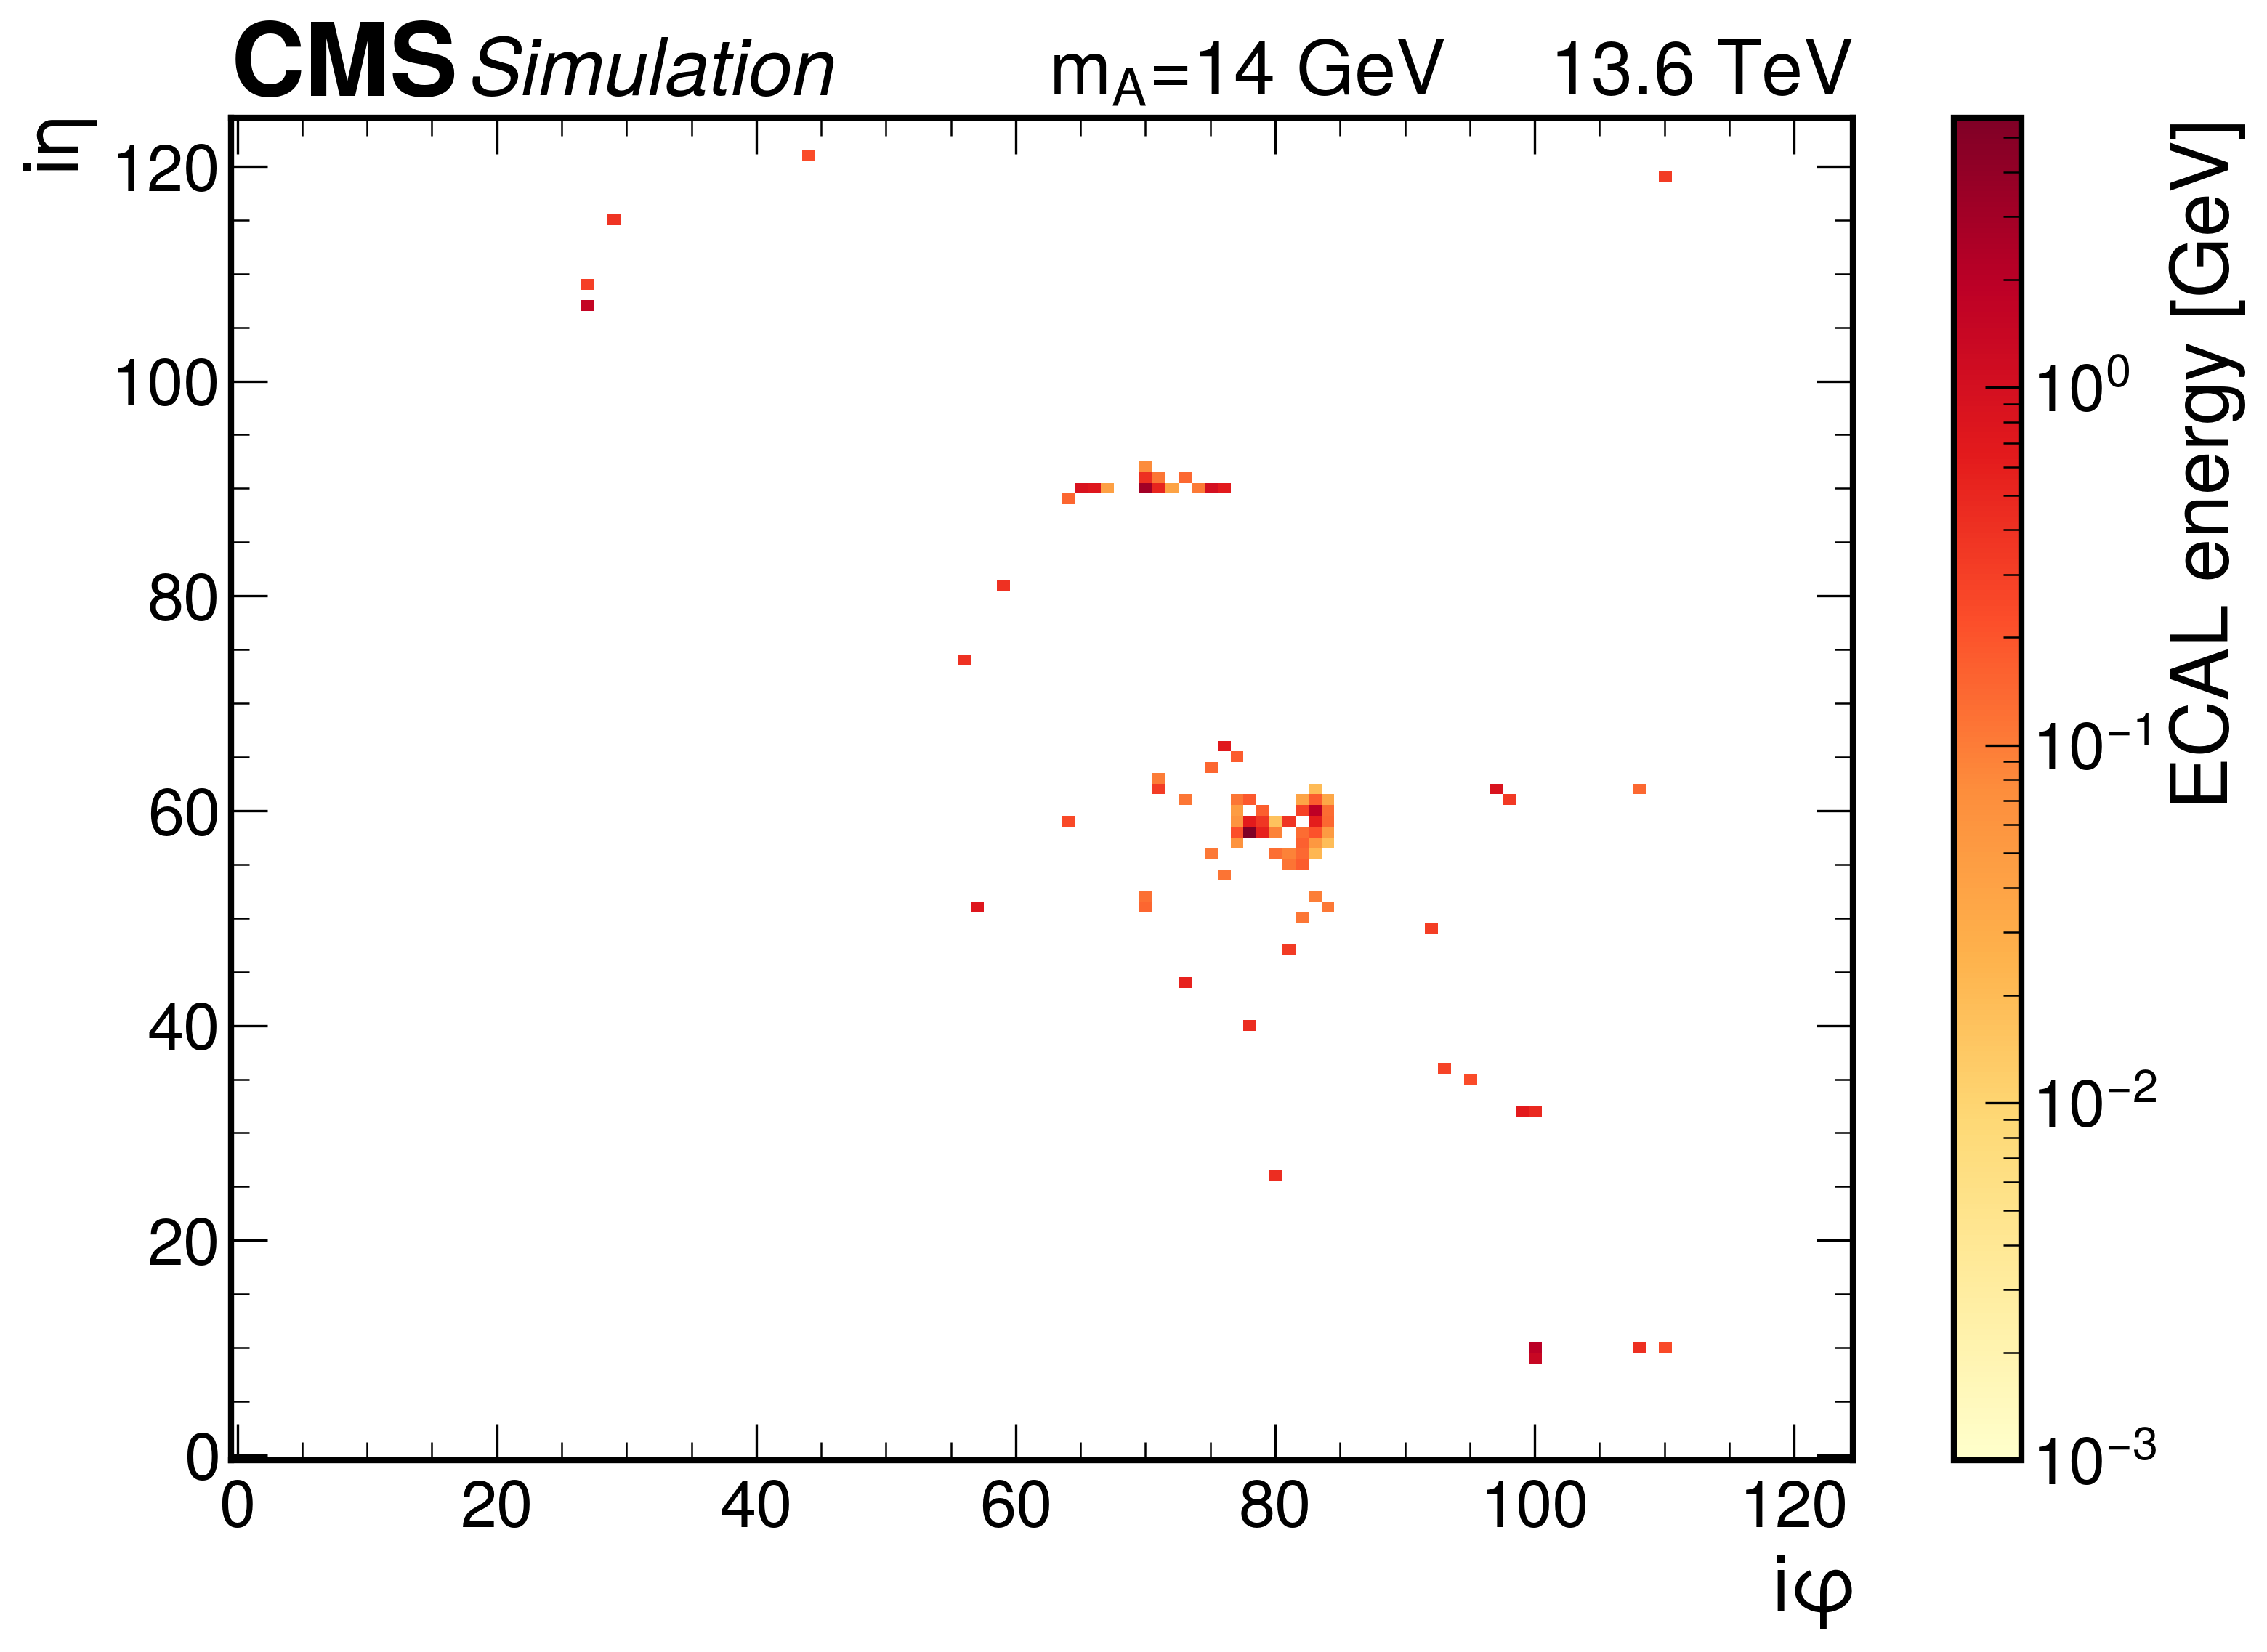

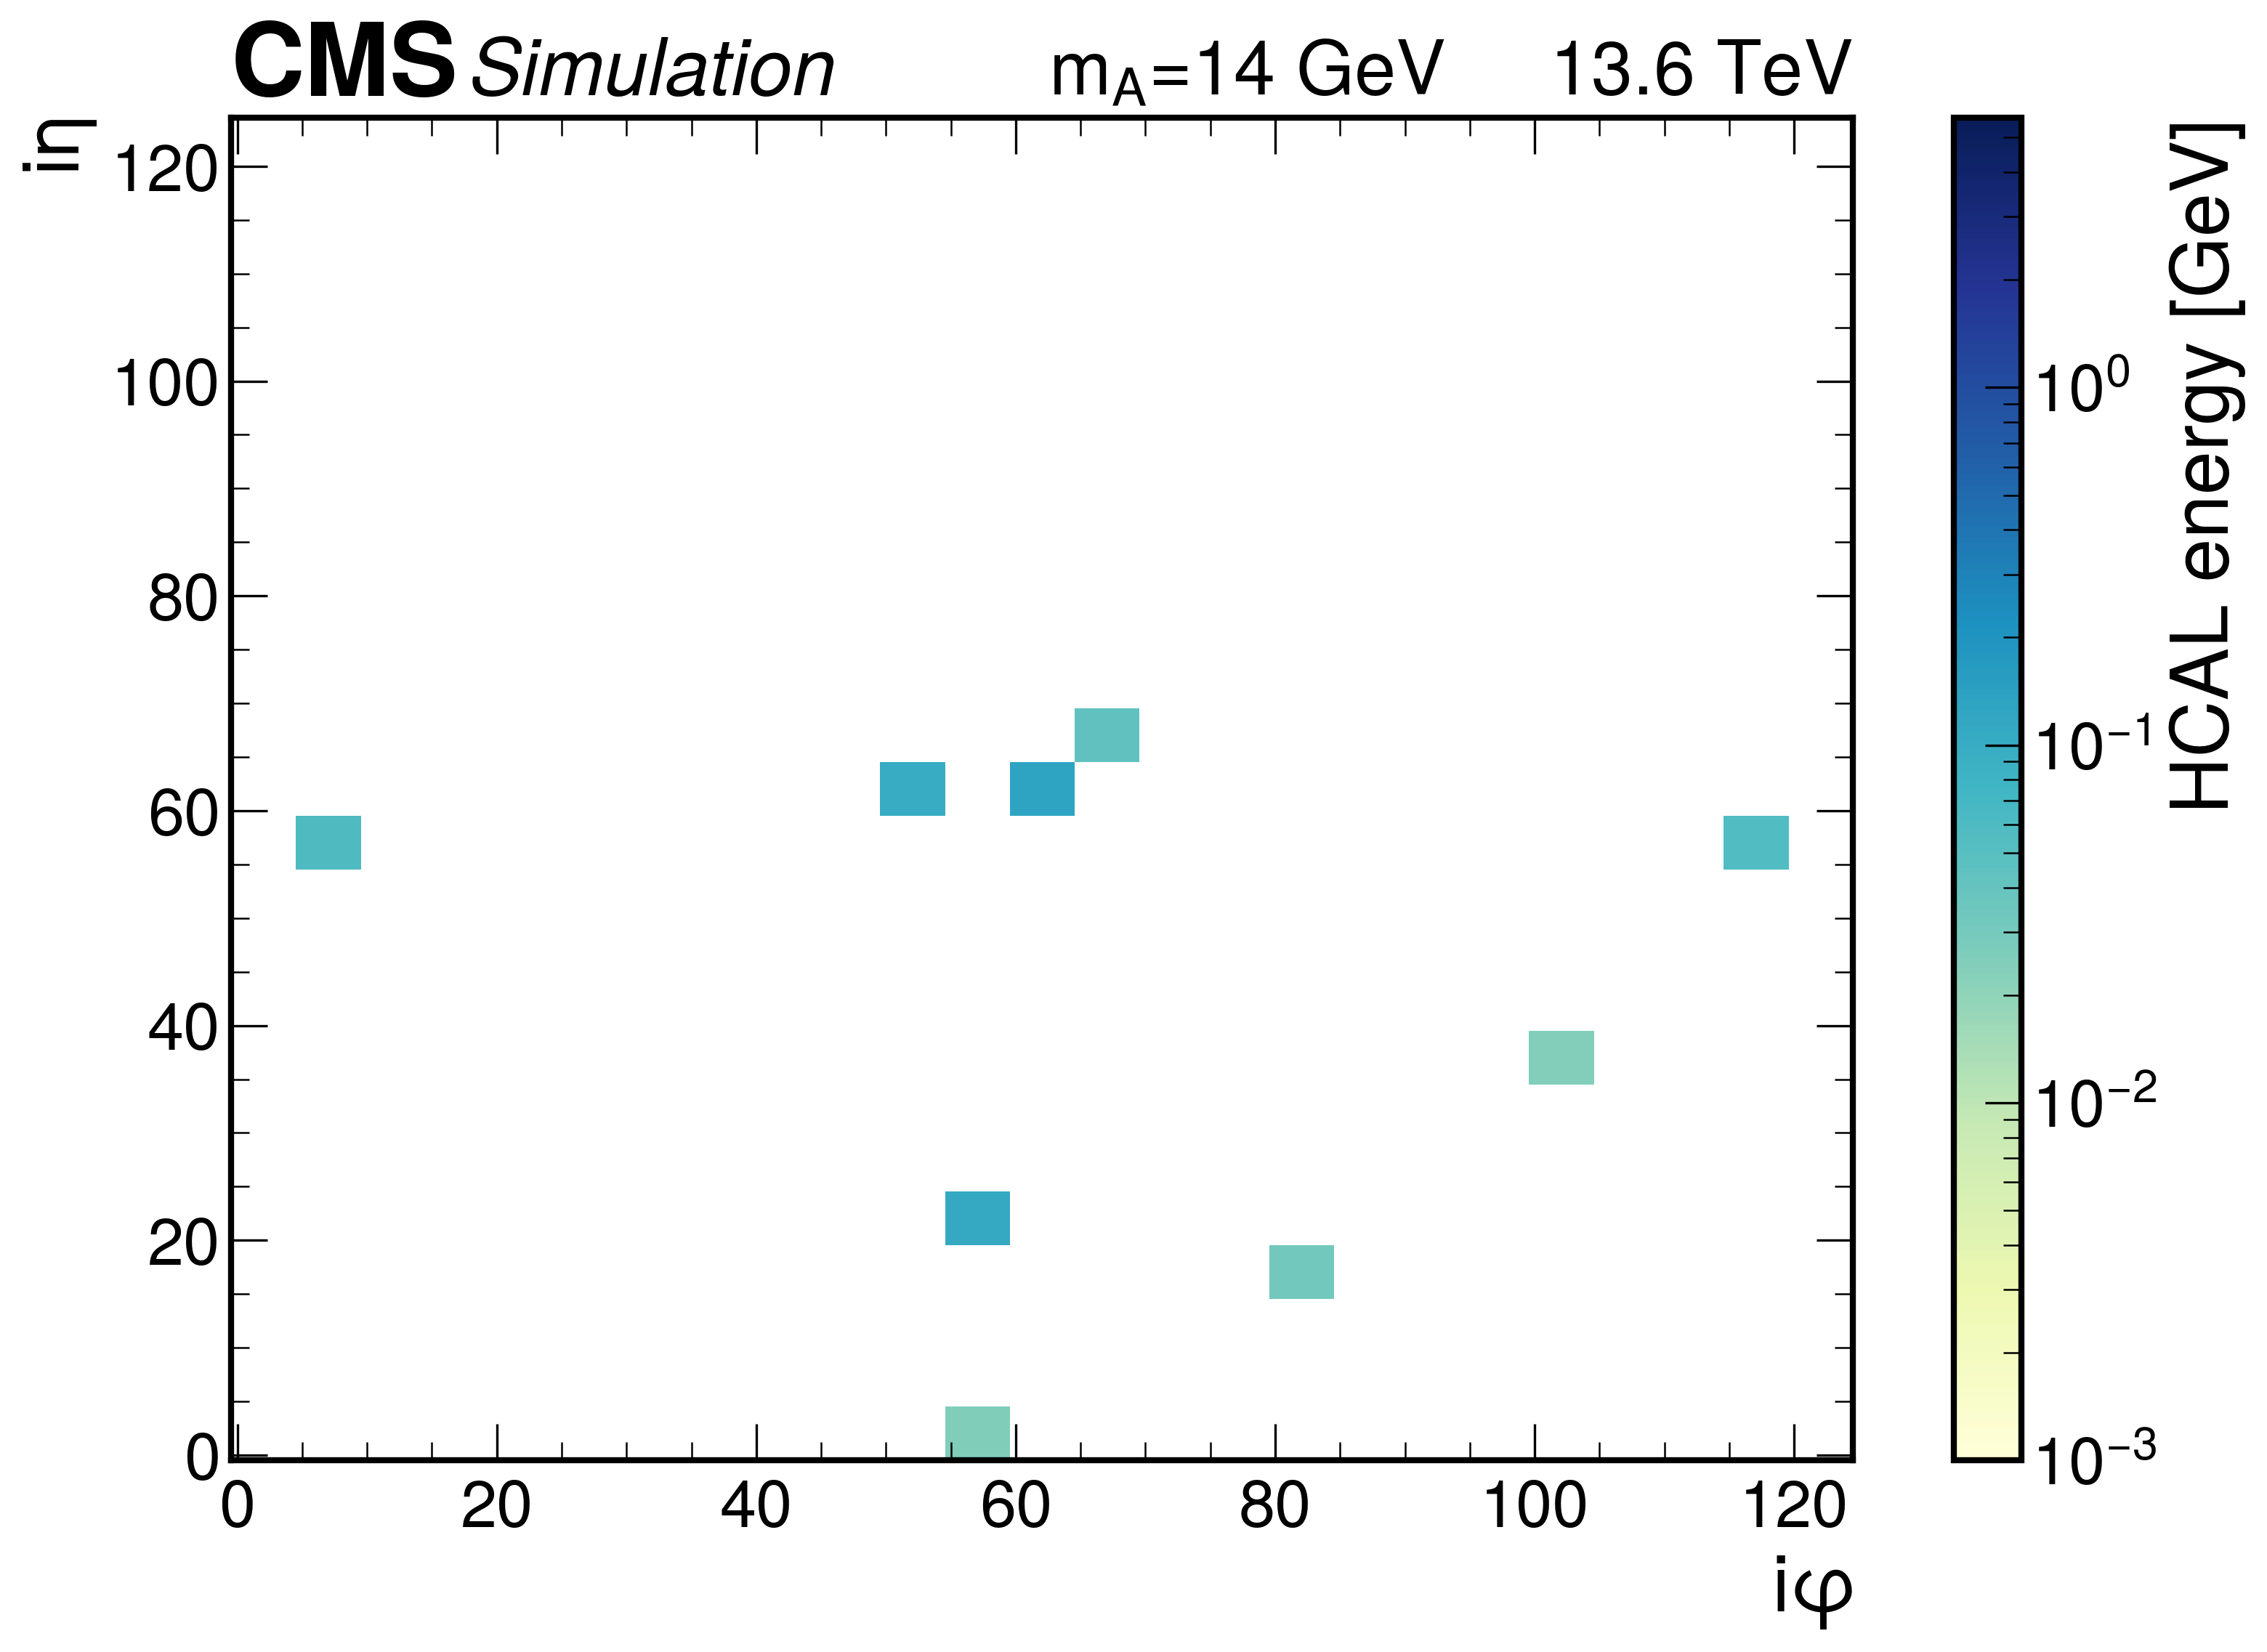

event 71
crope position 0


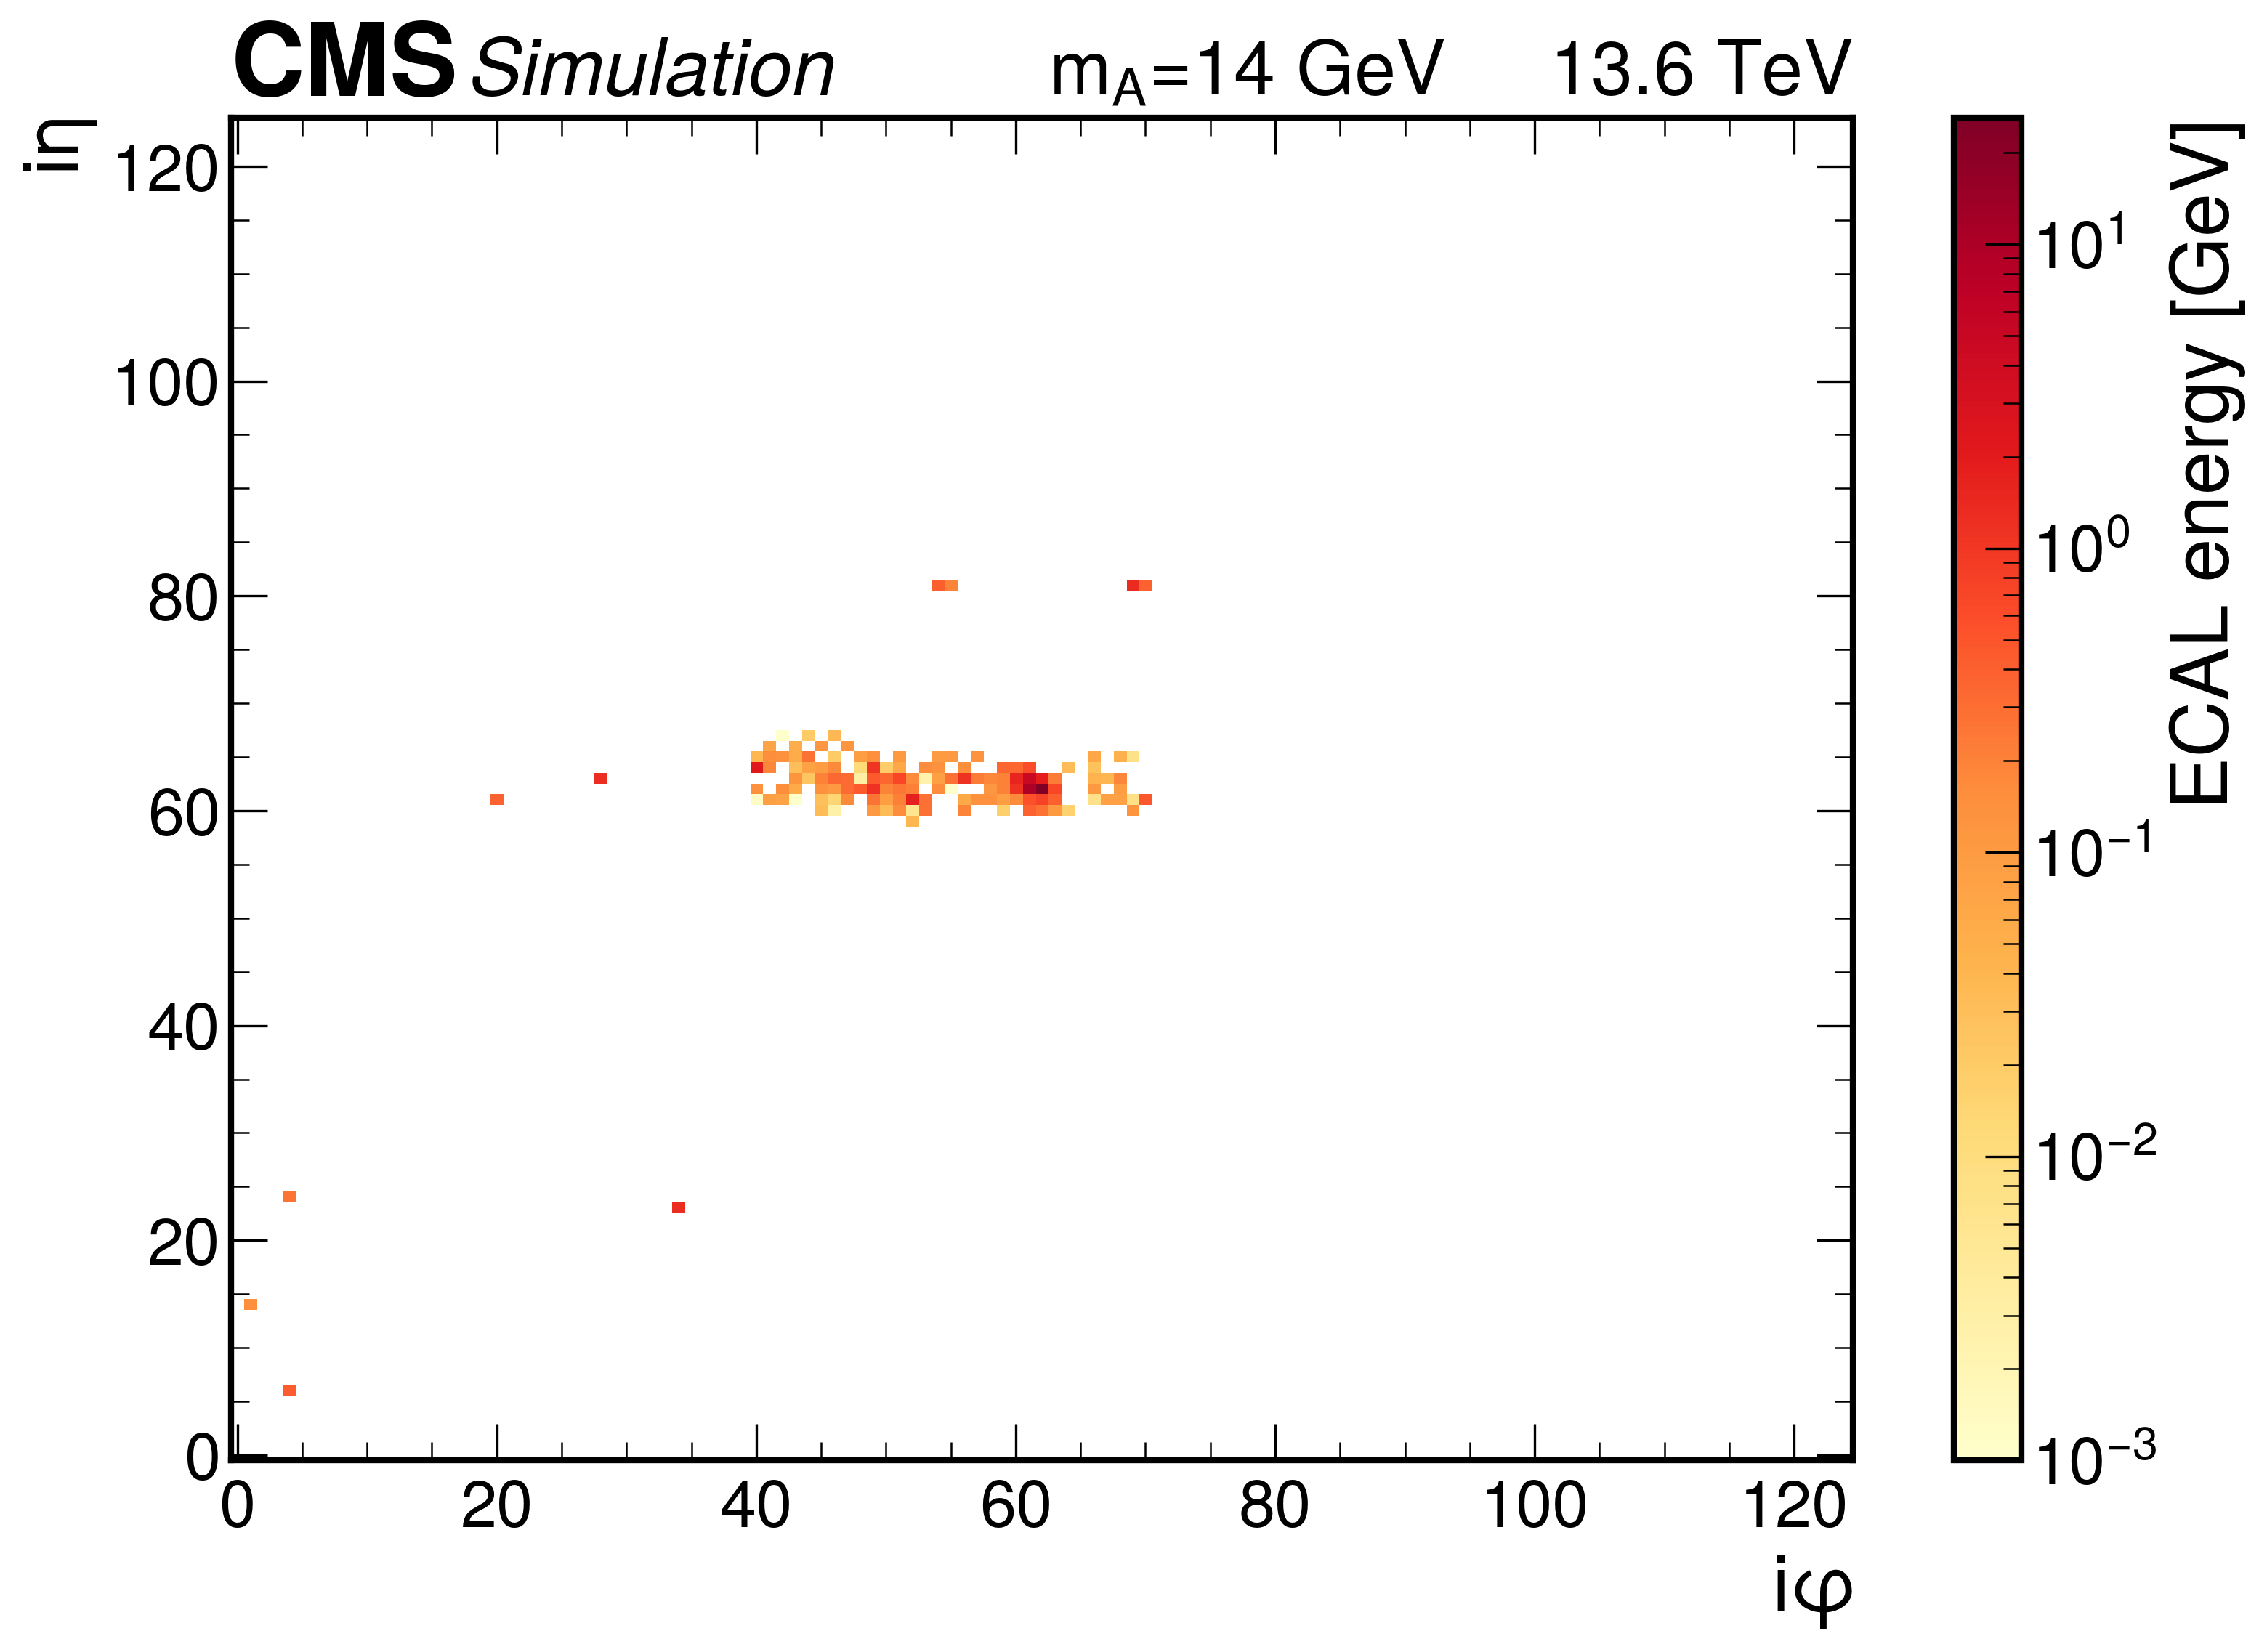

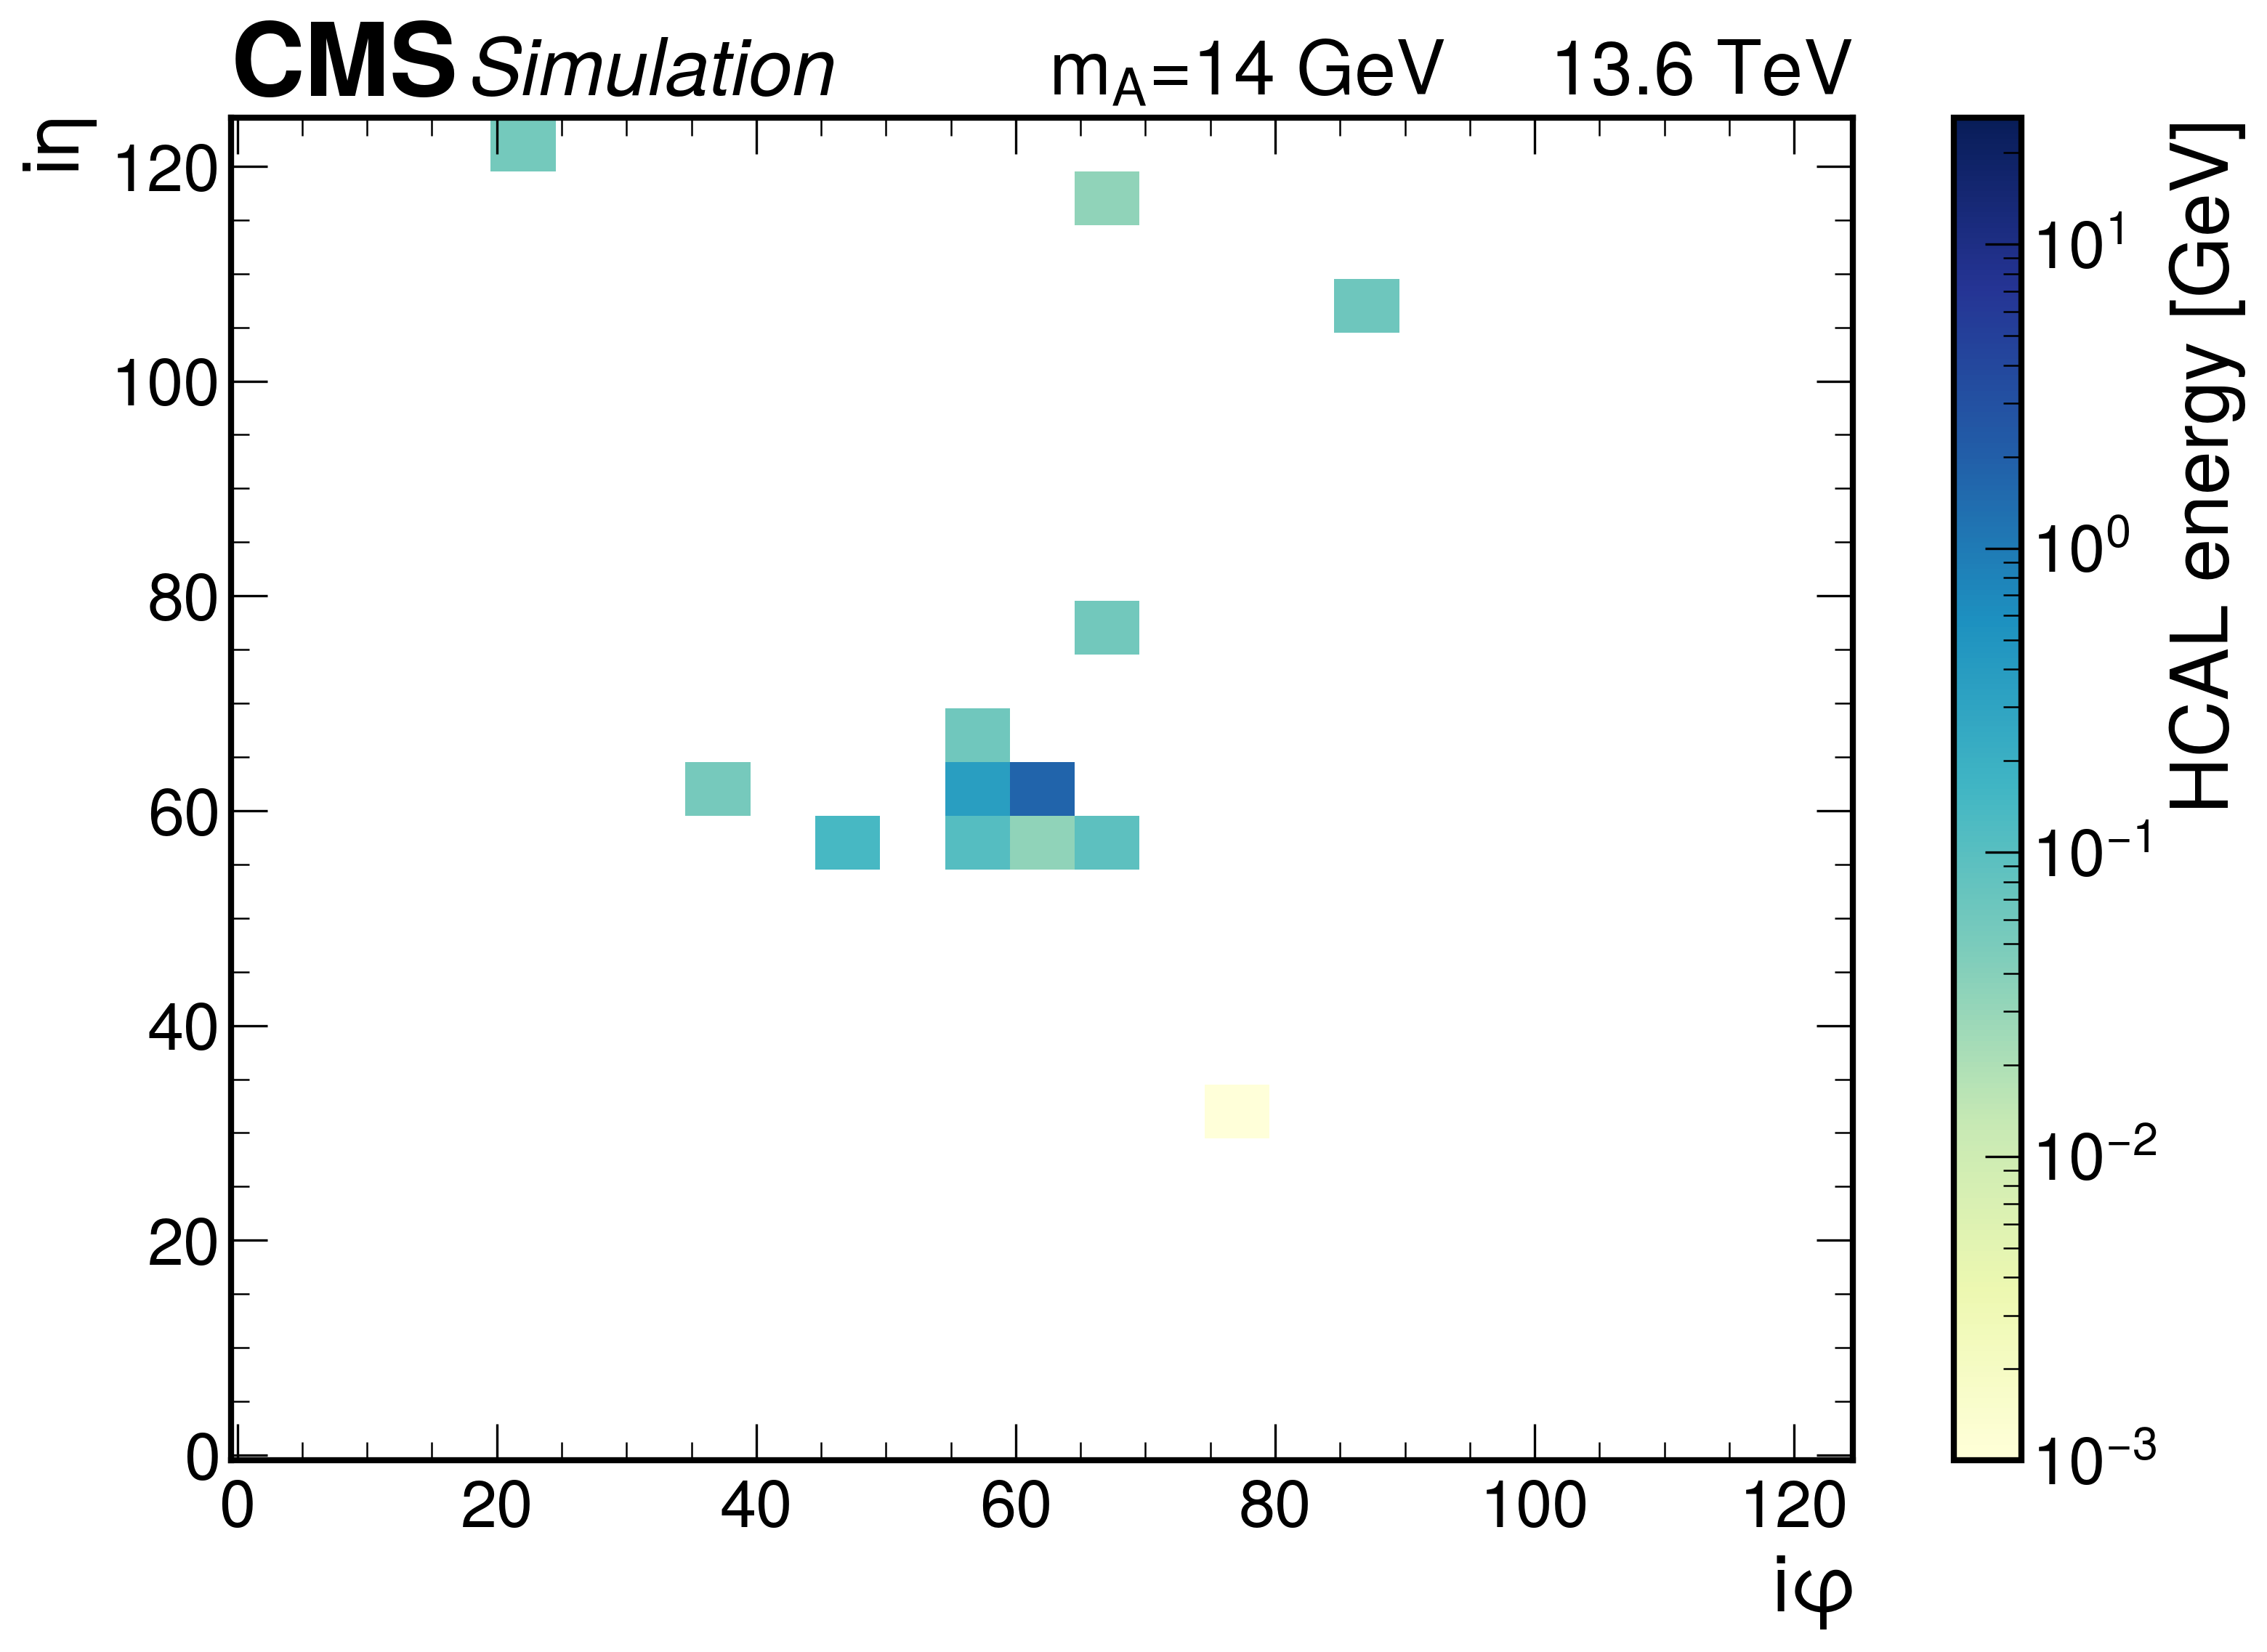

event 71
crope position 1


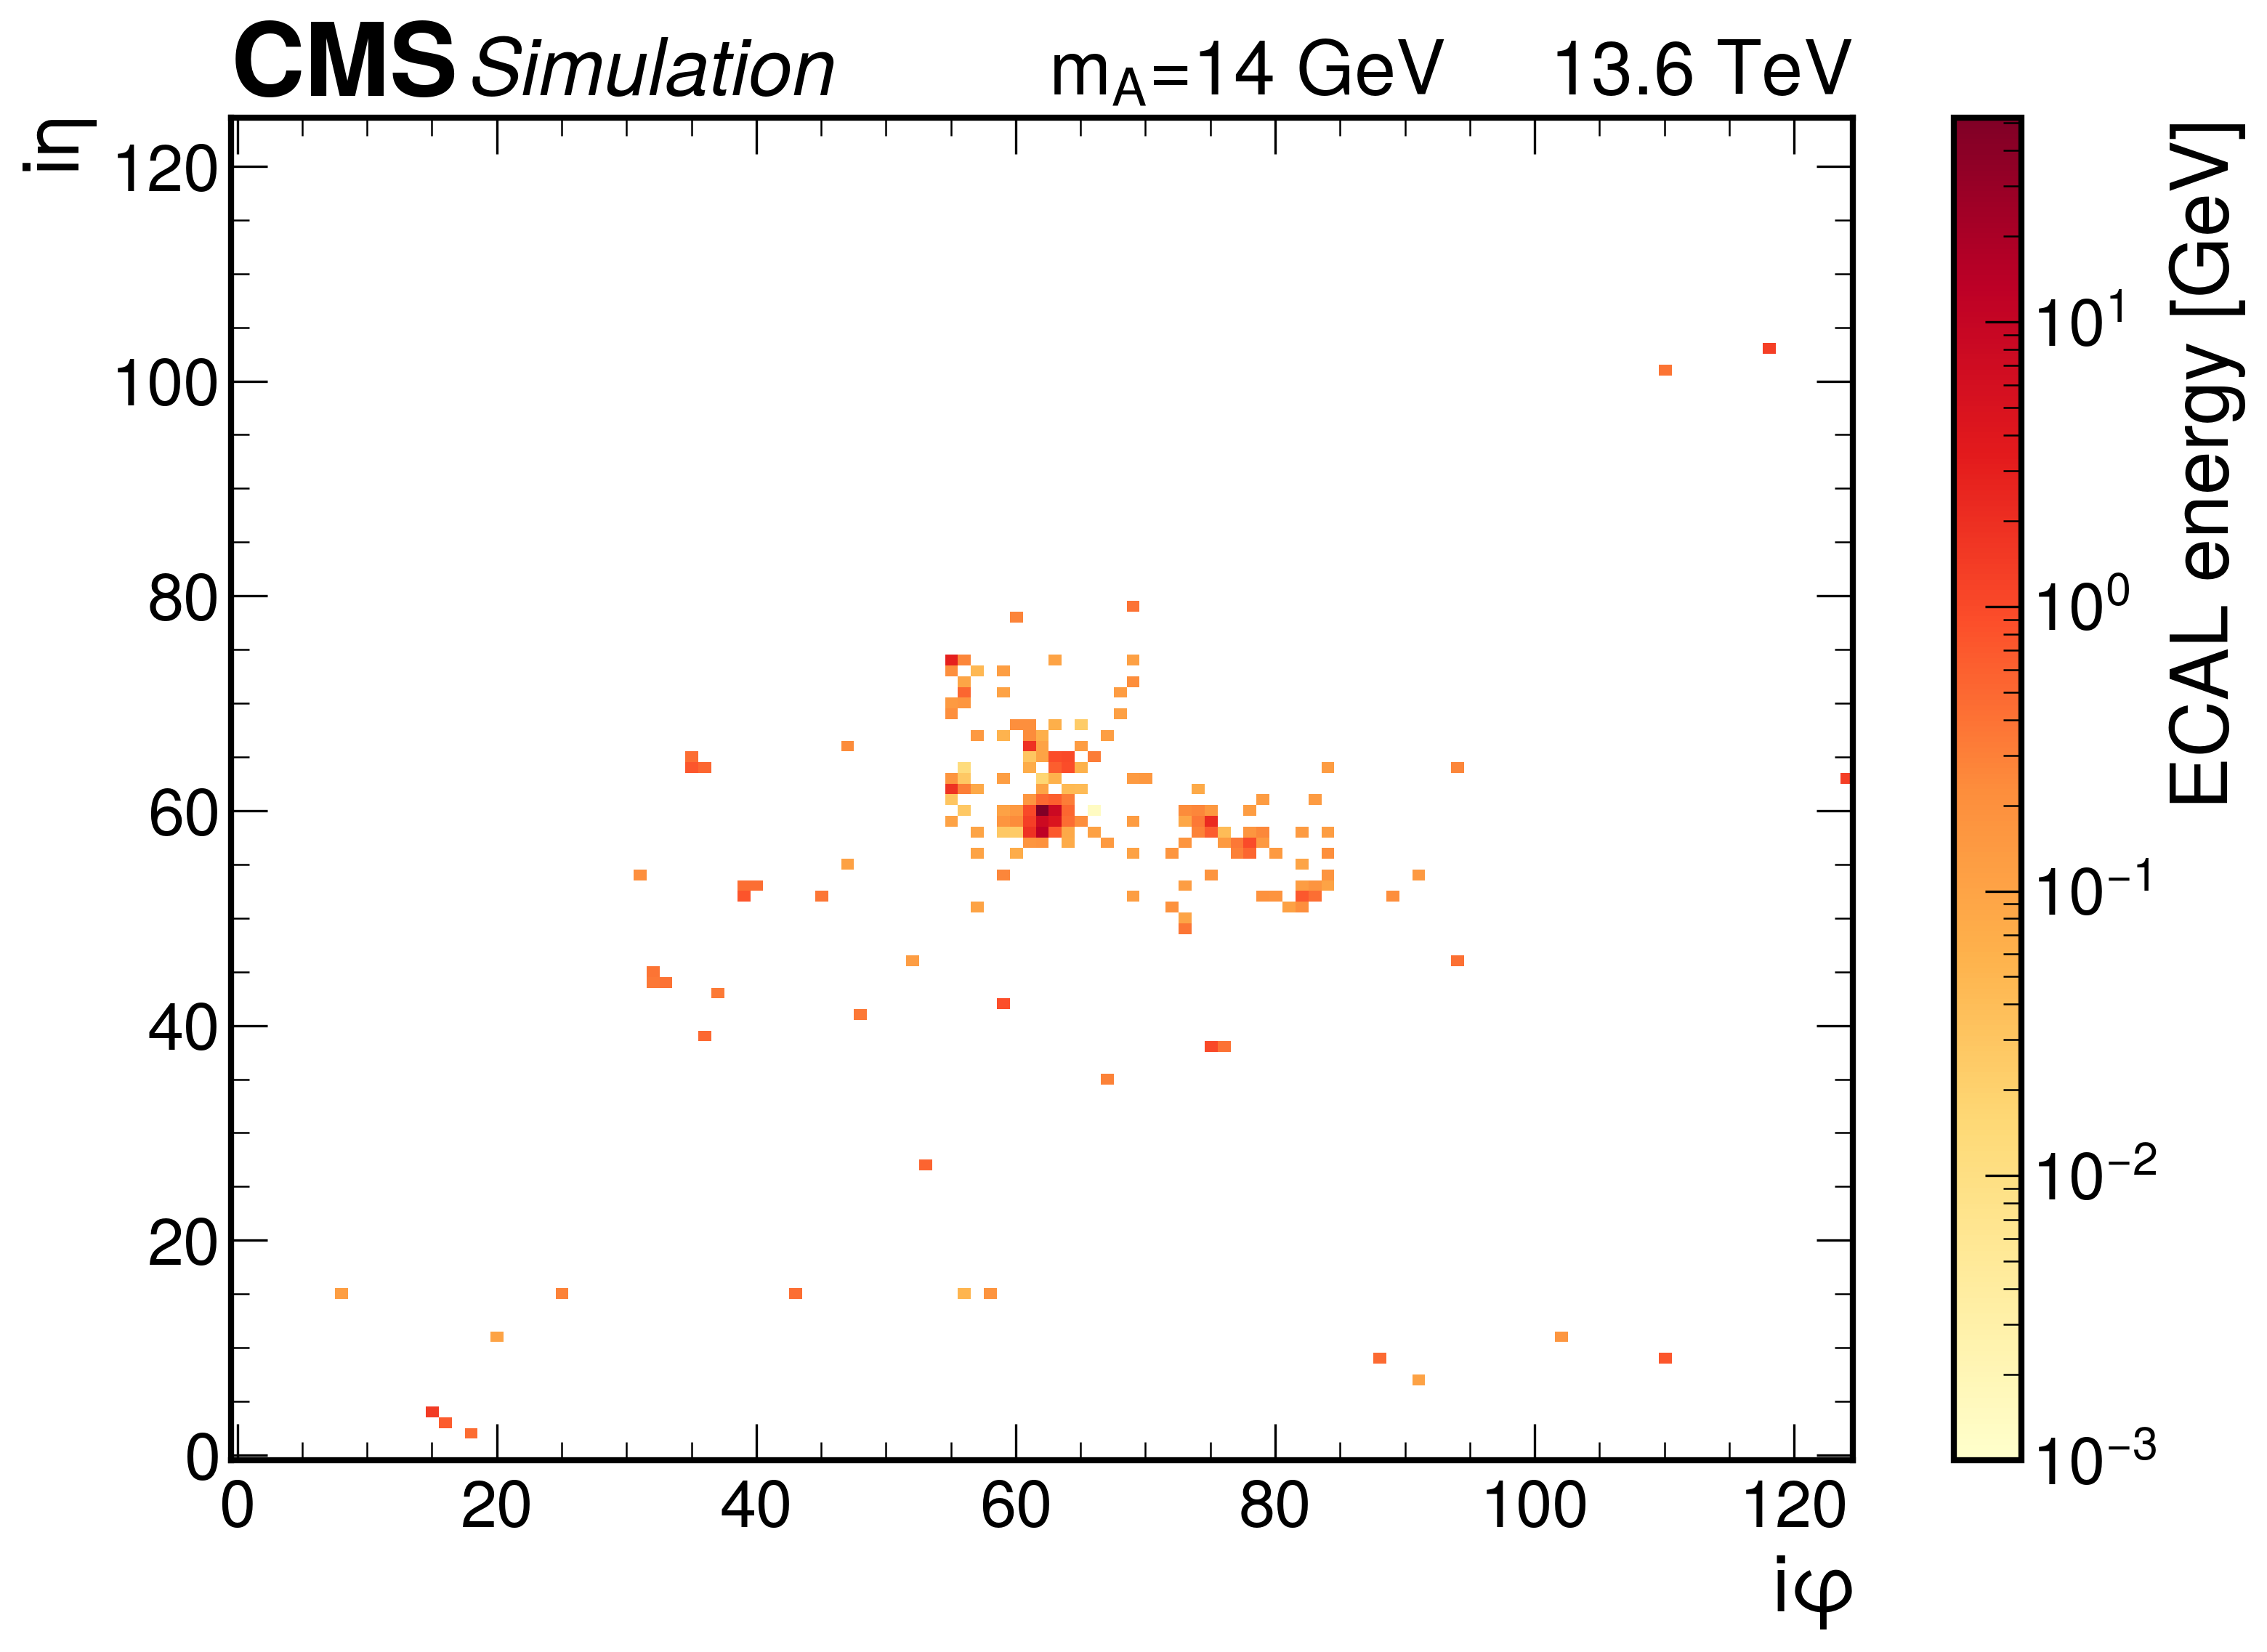

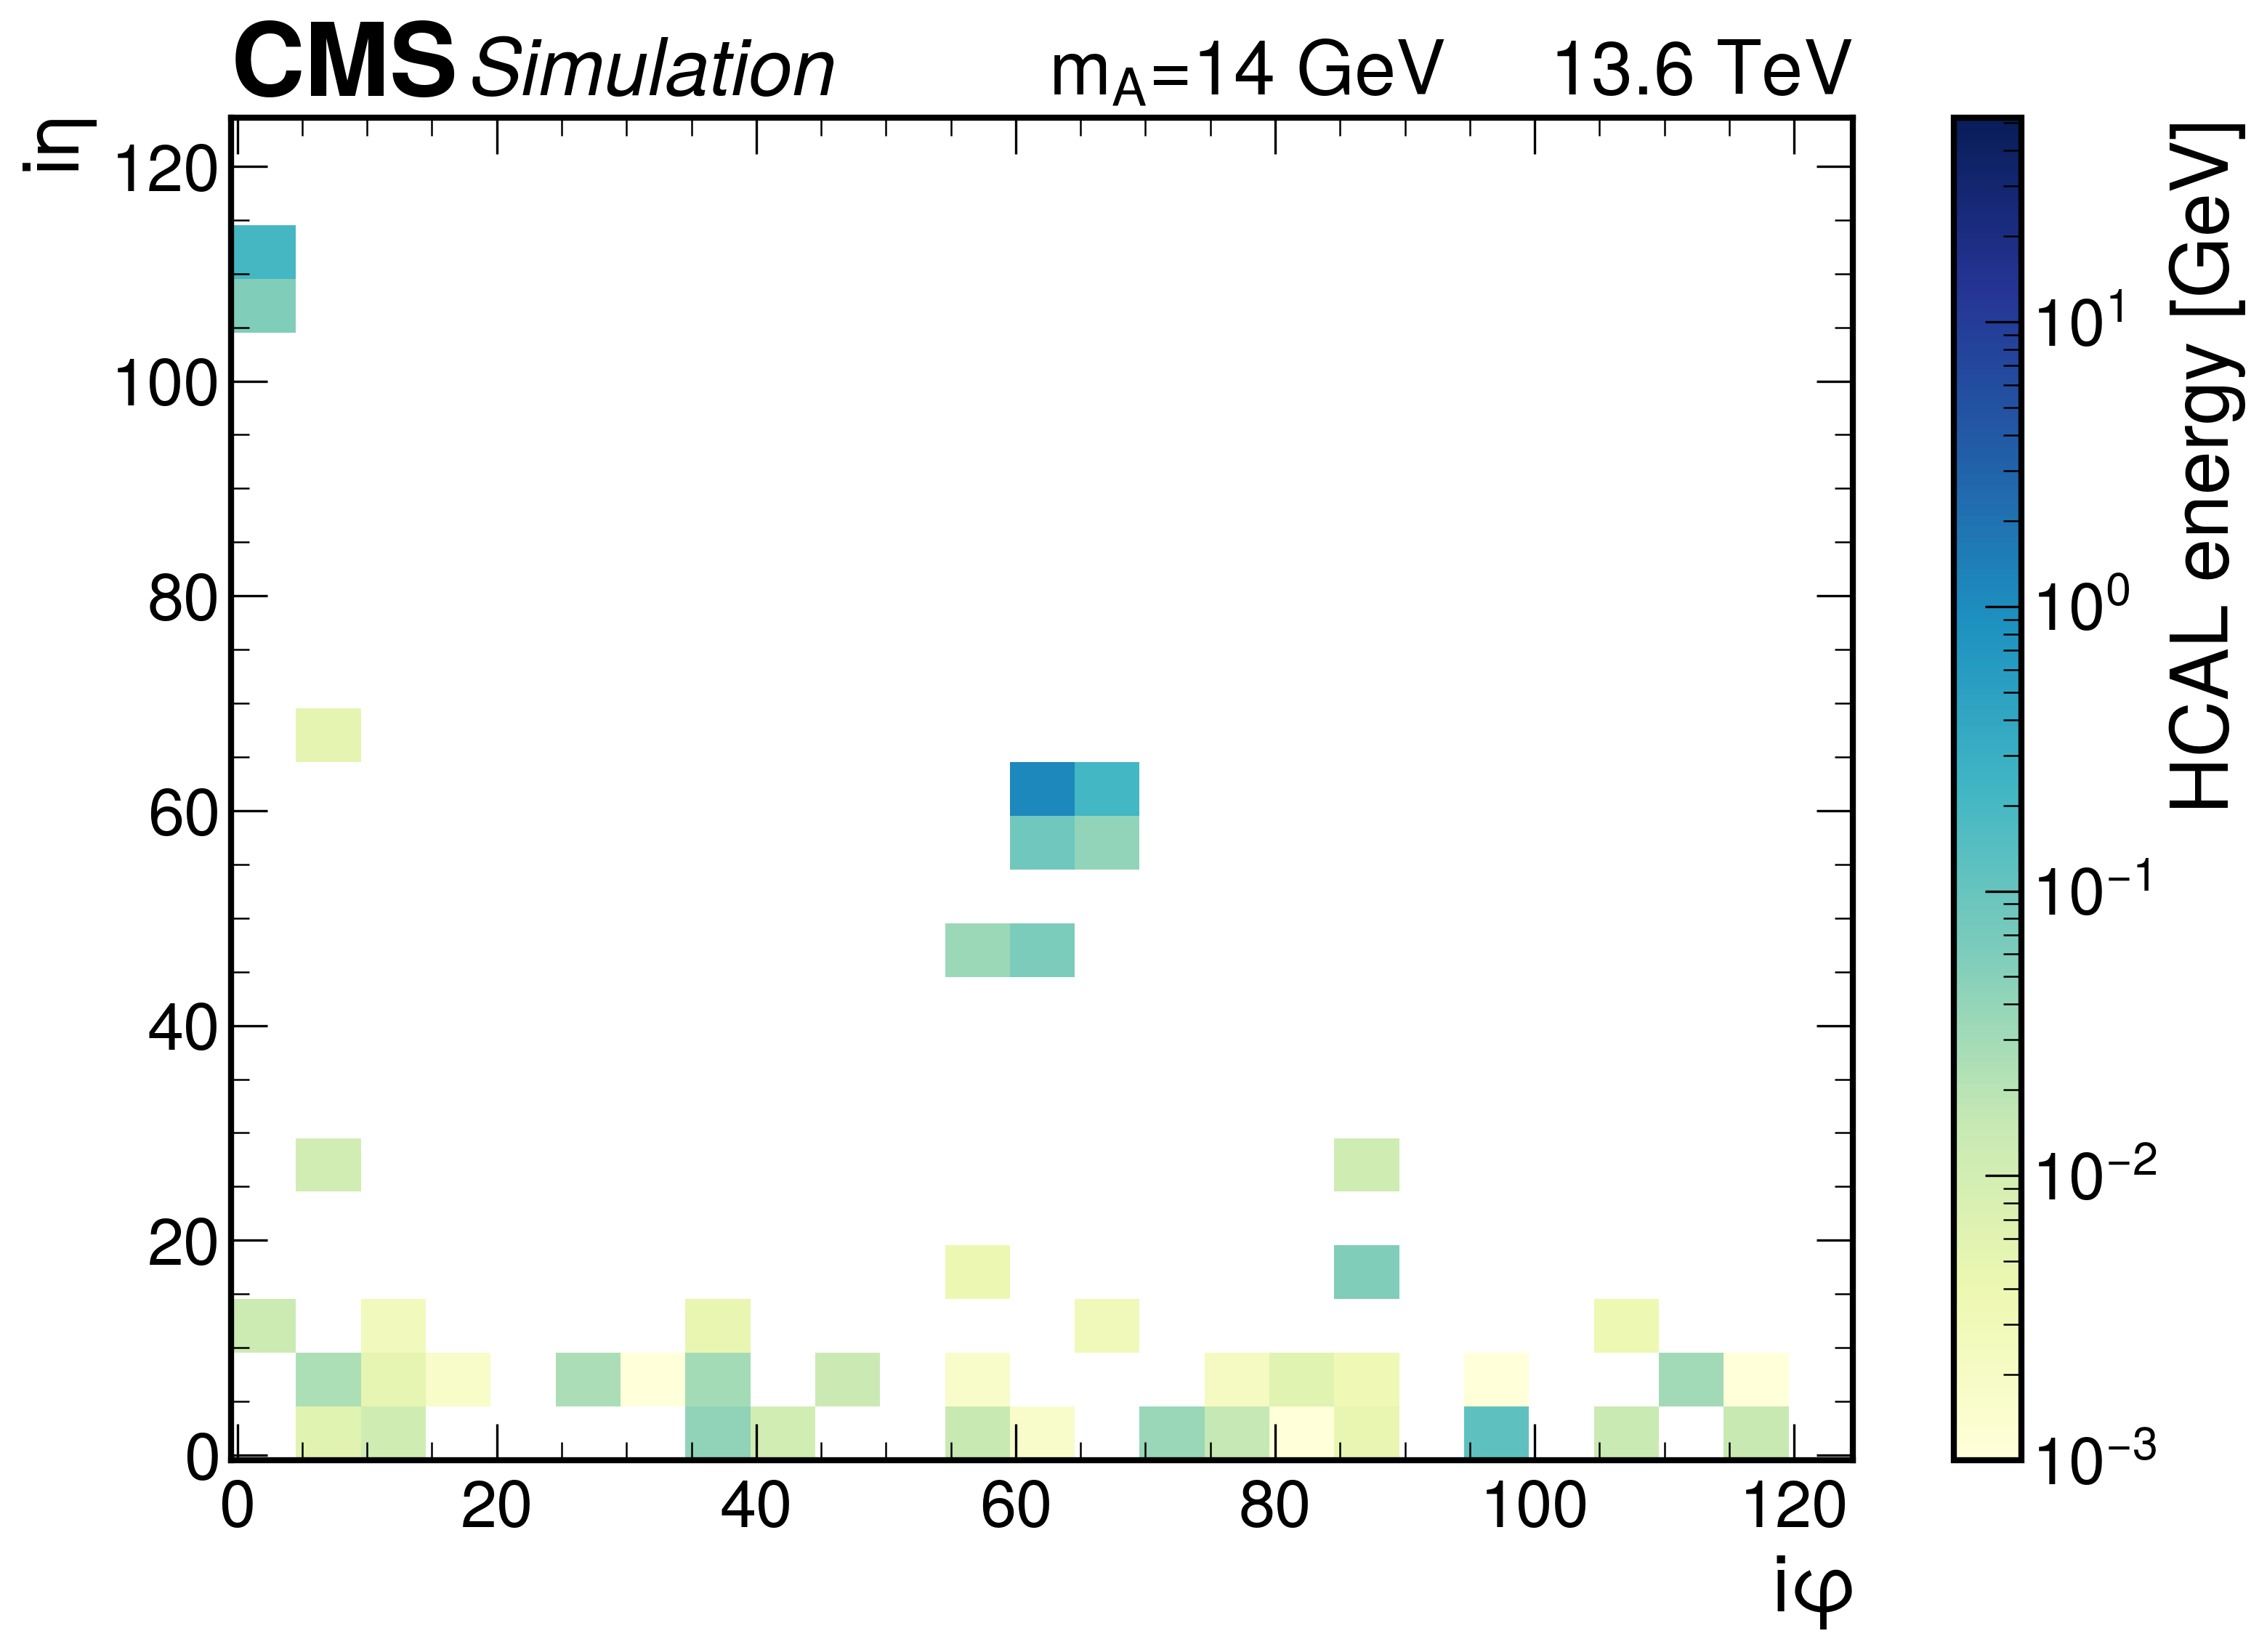

event 71
crope position 2


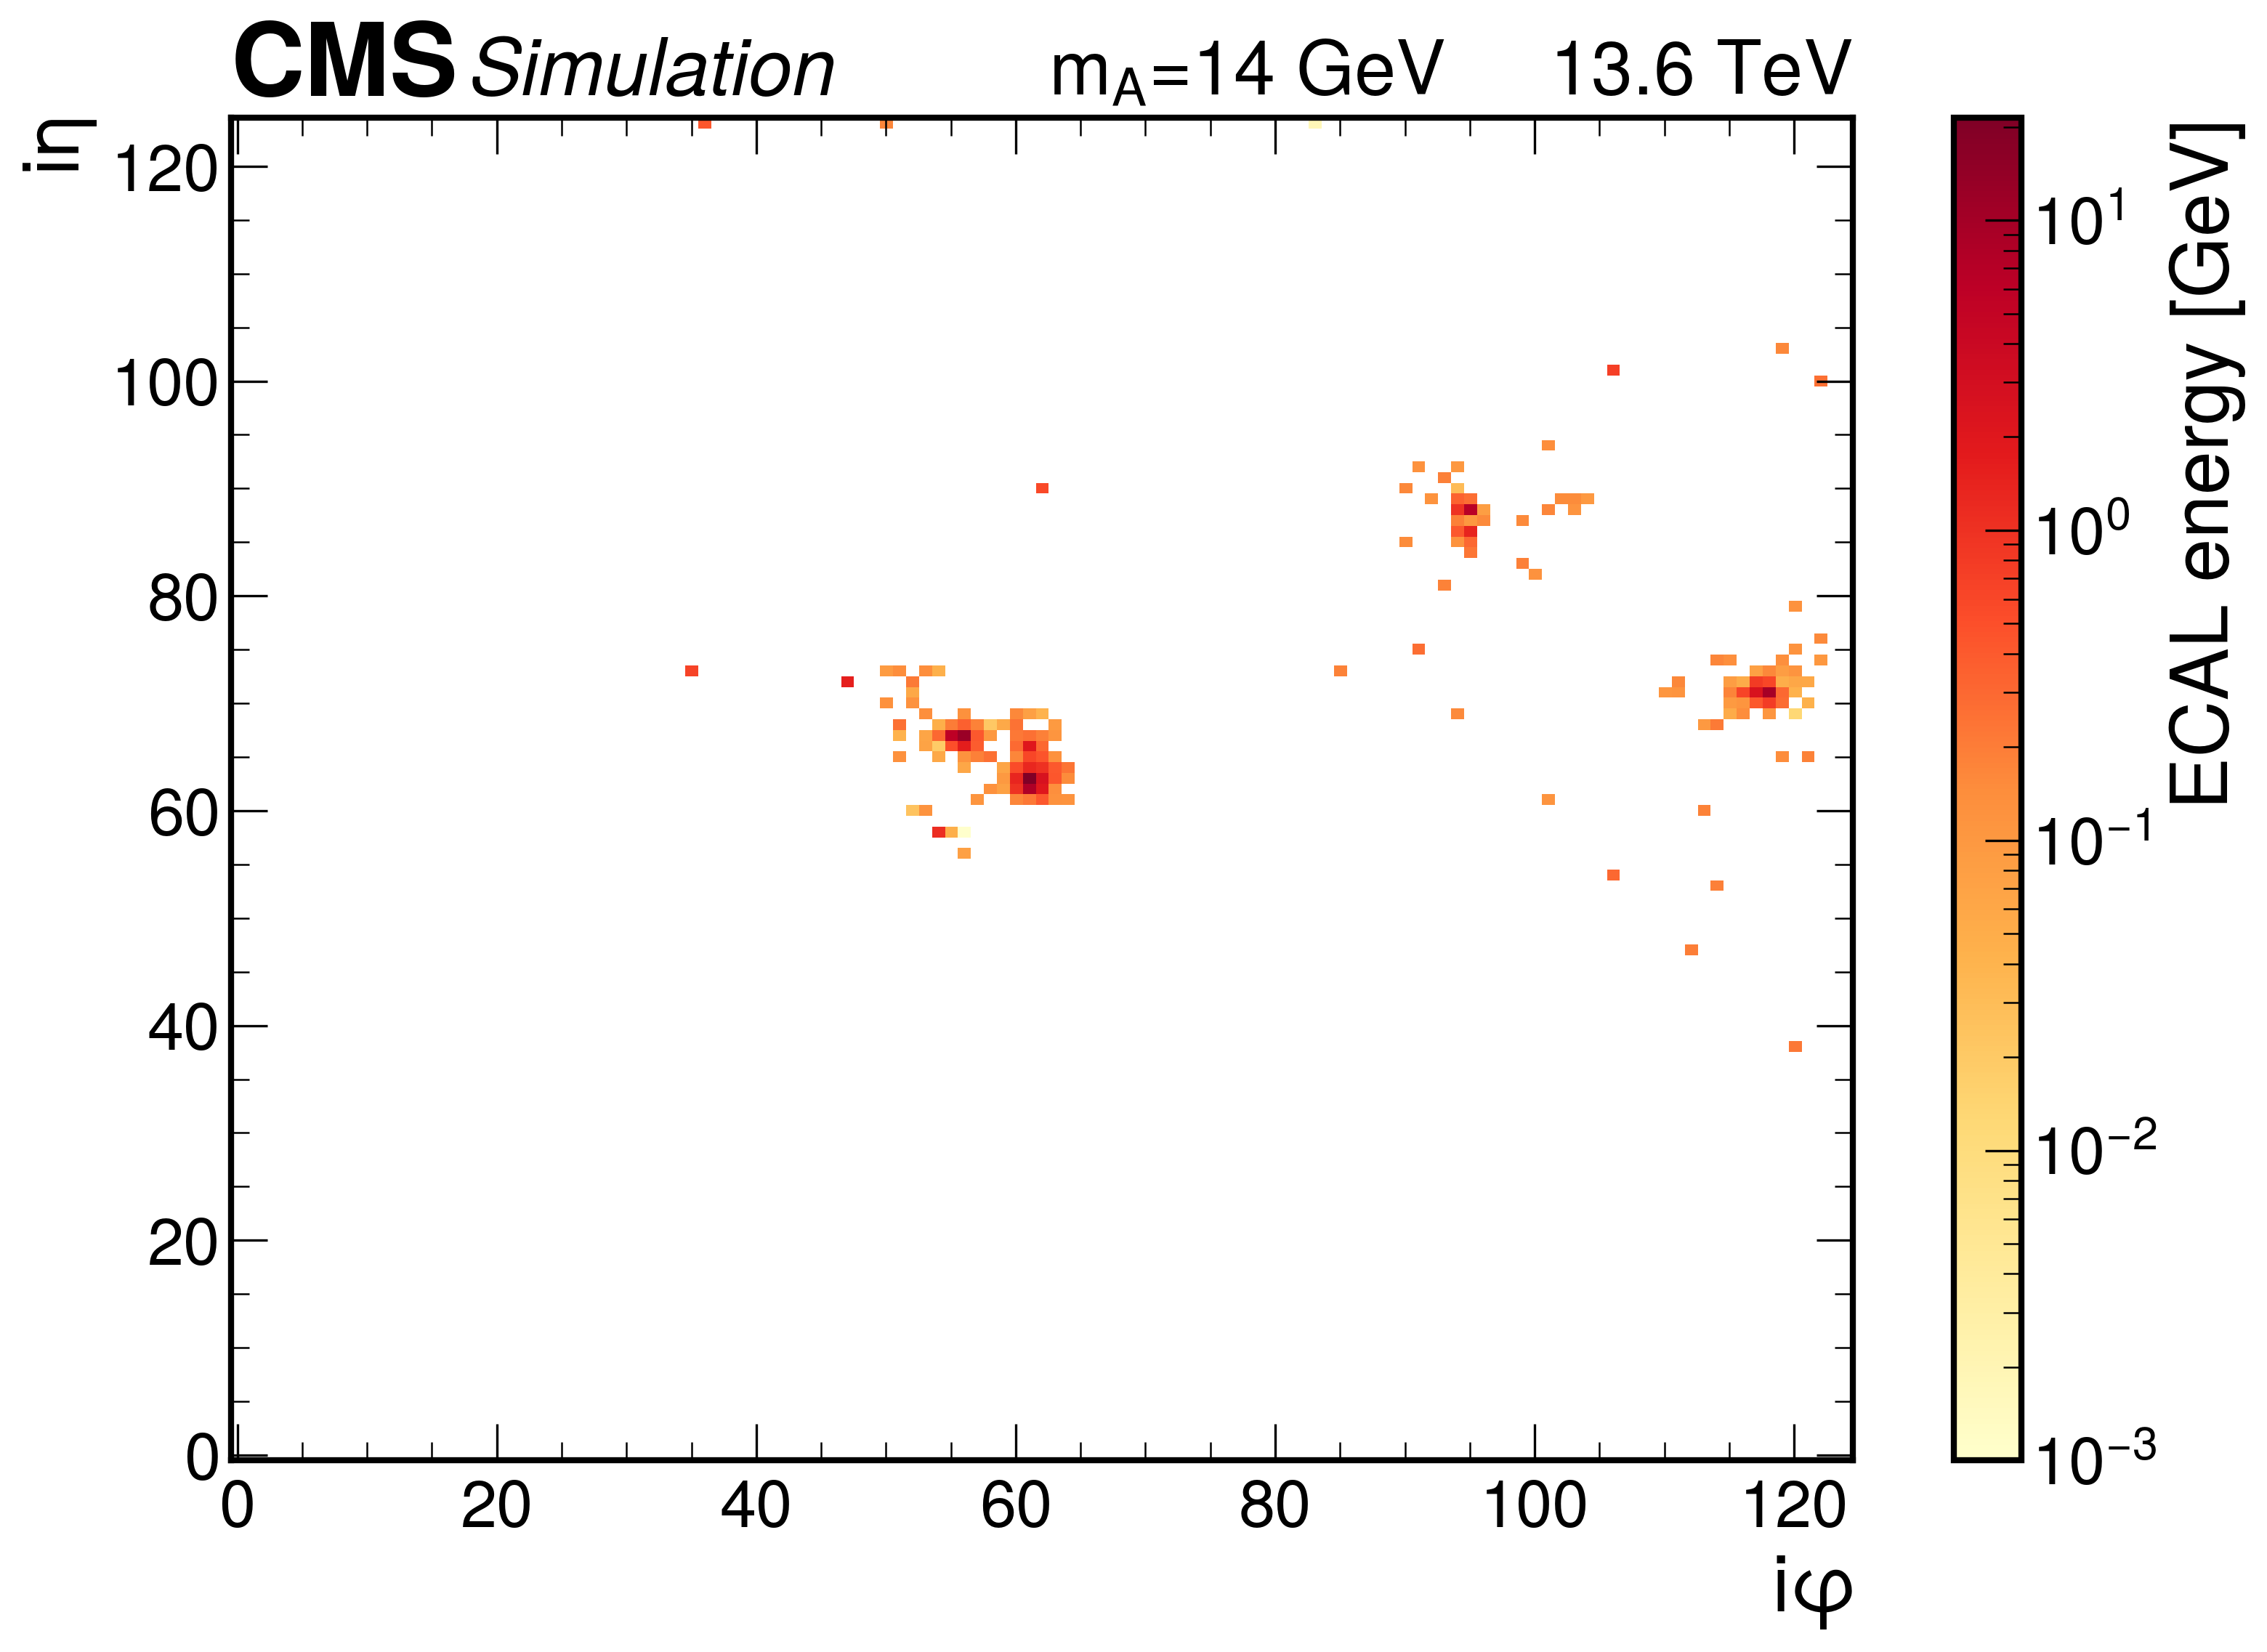

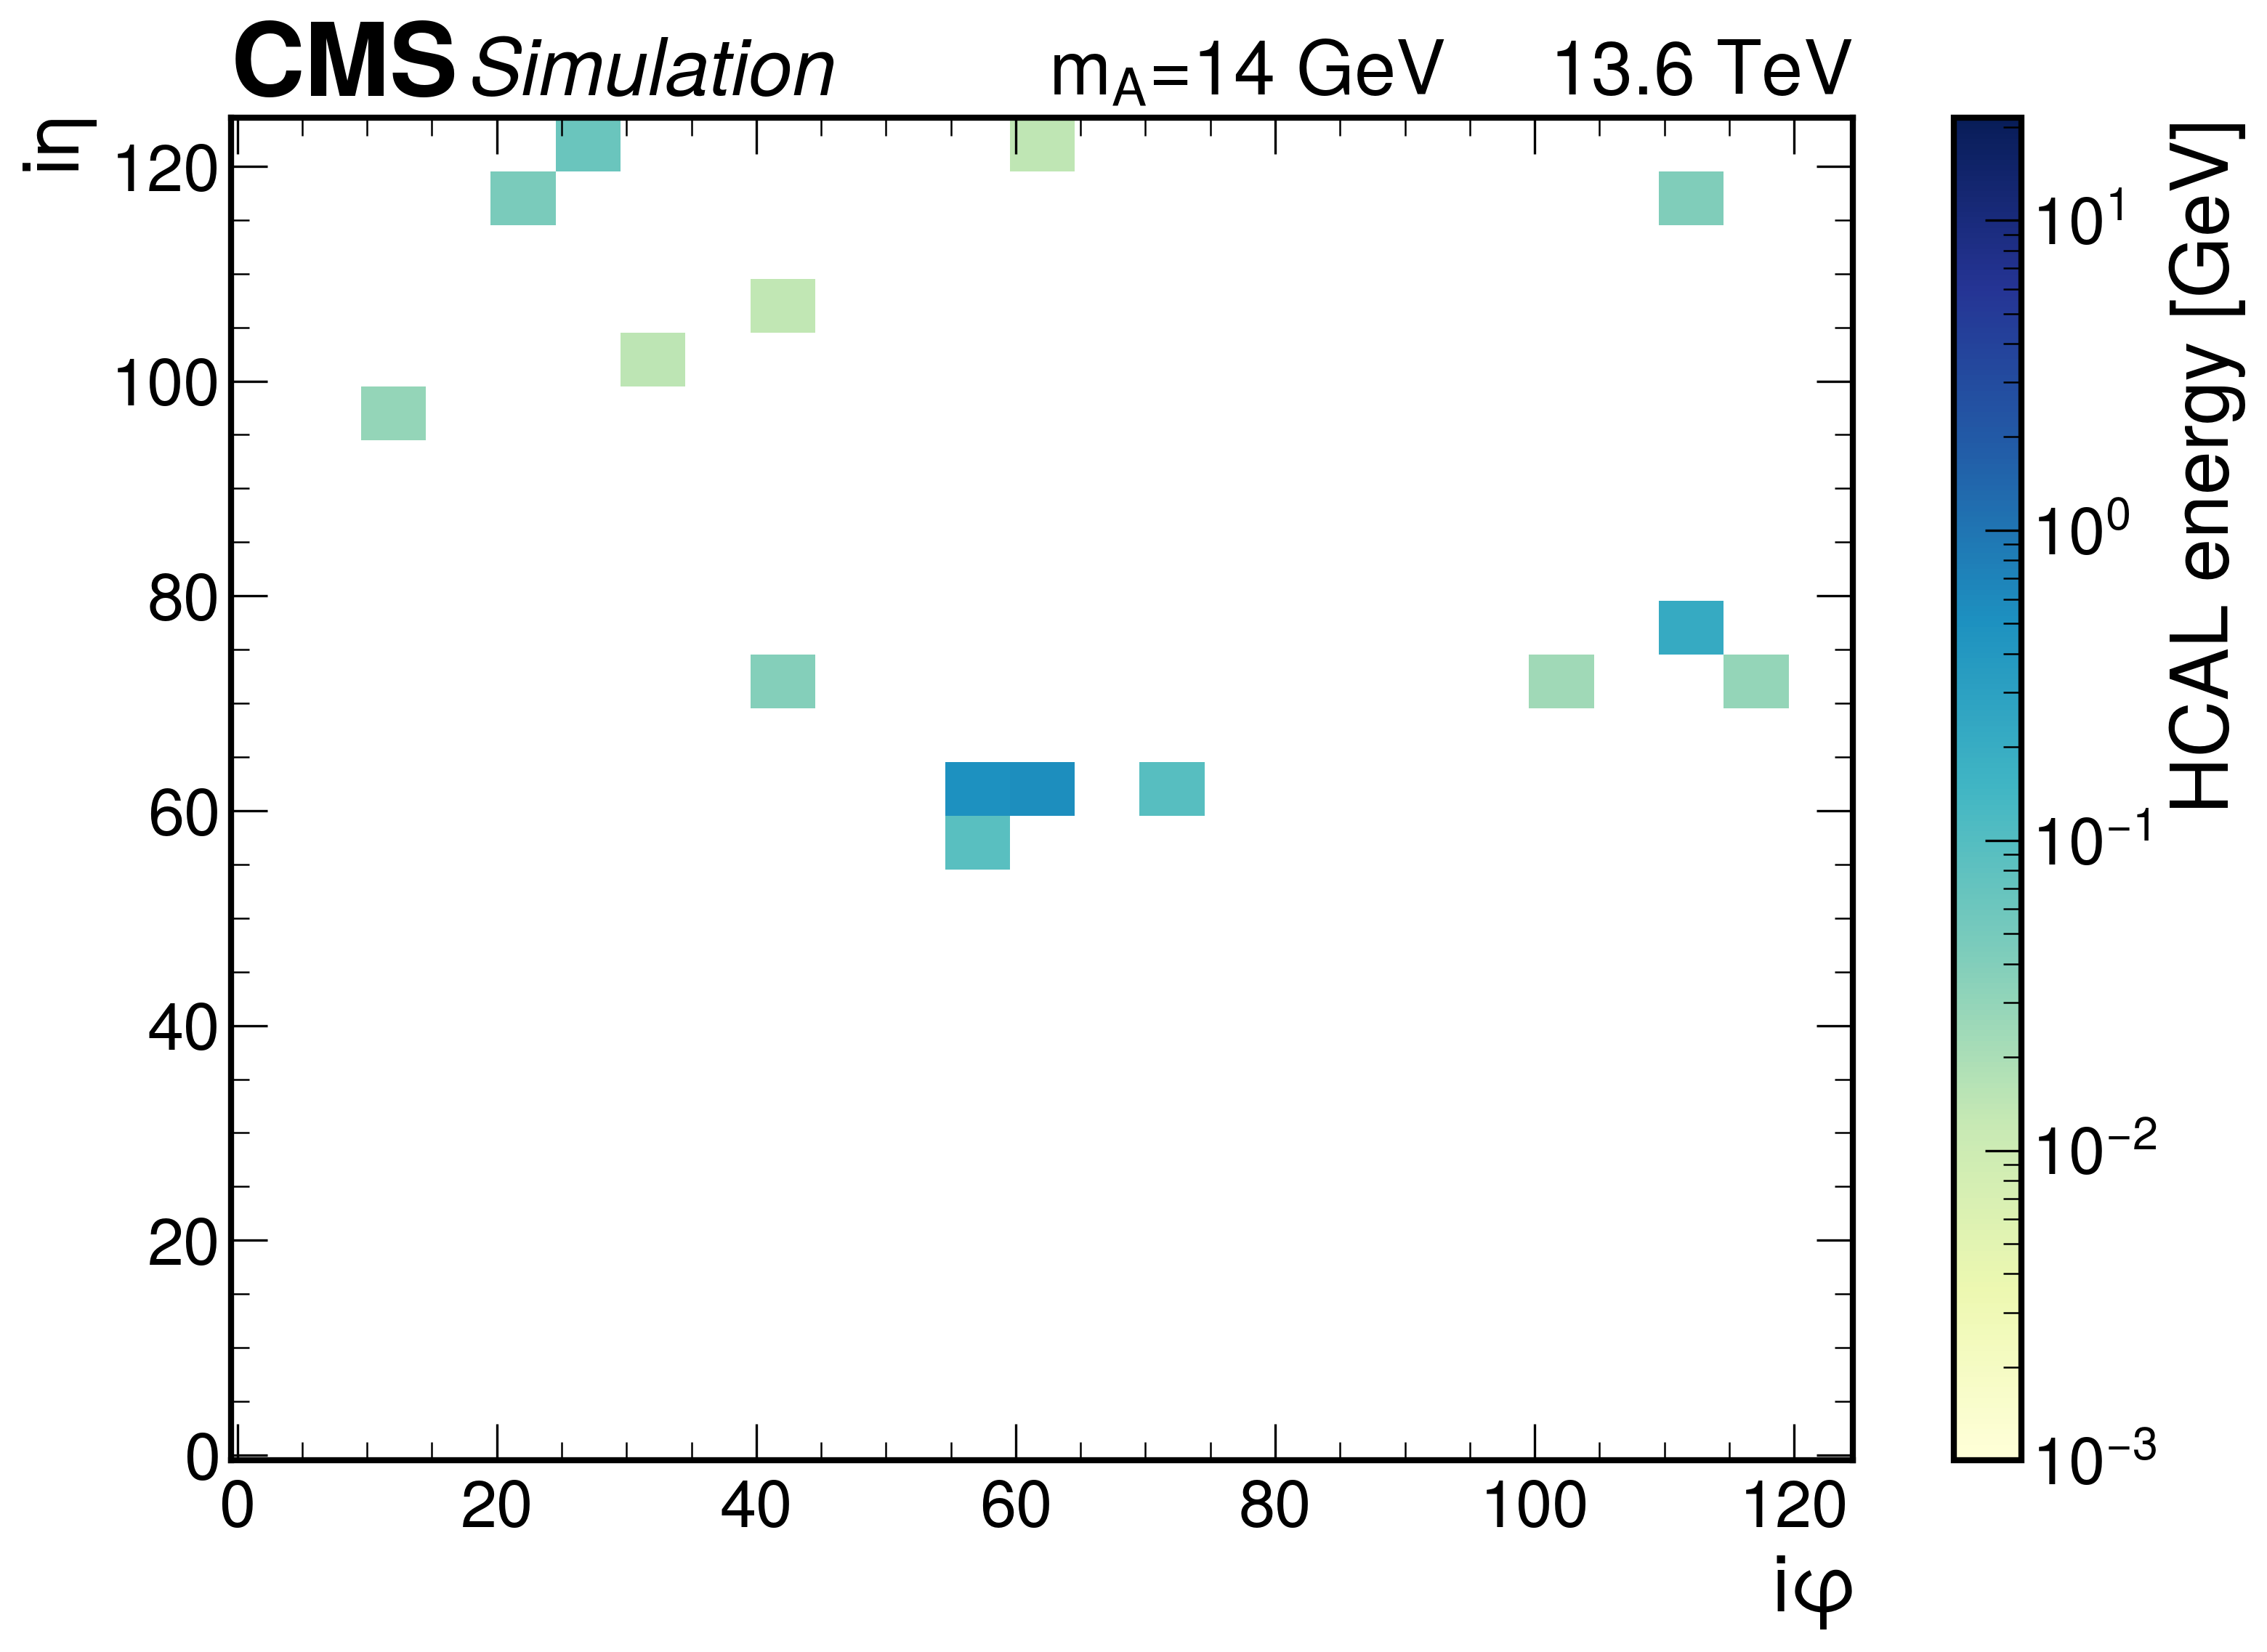

event 71
crope position 3


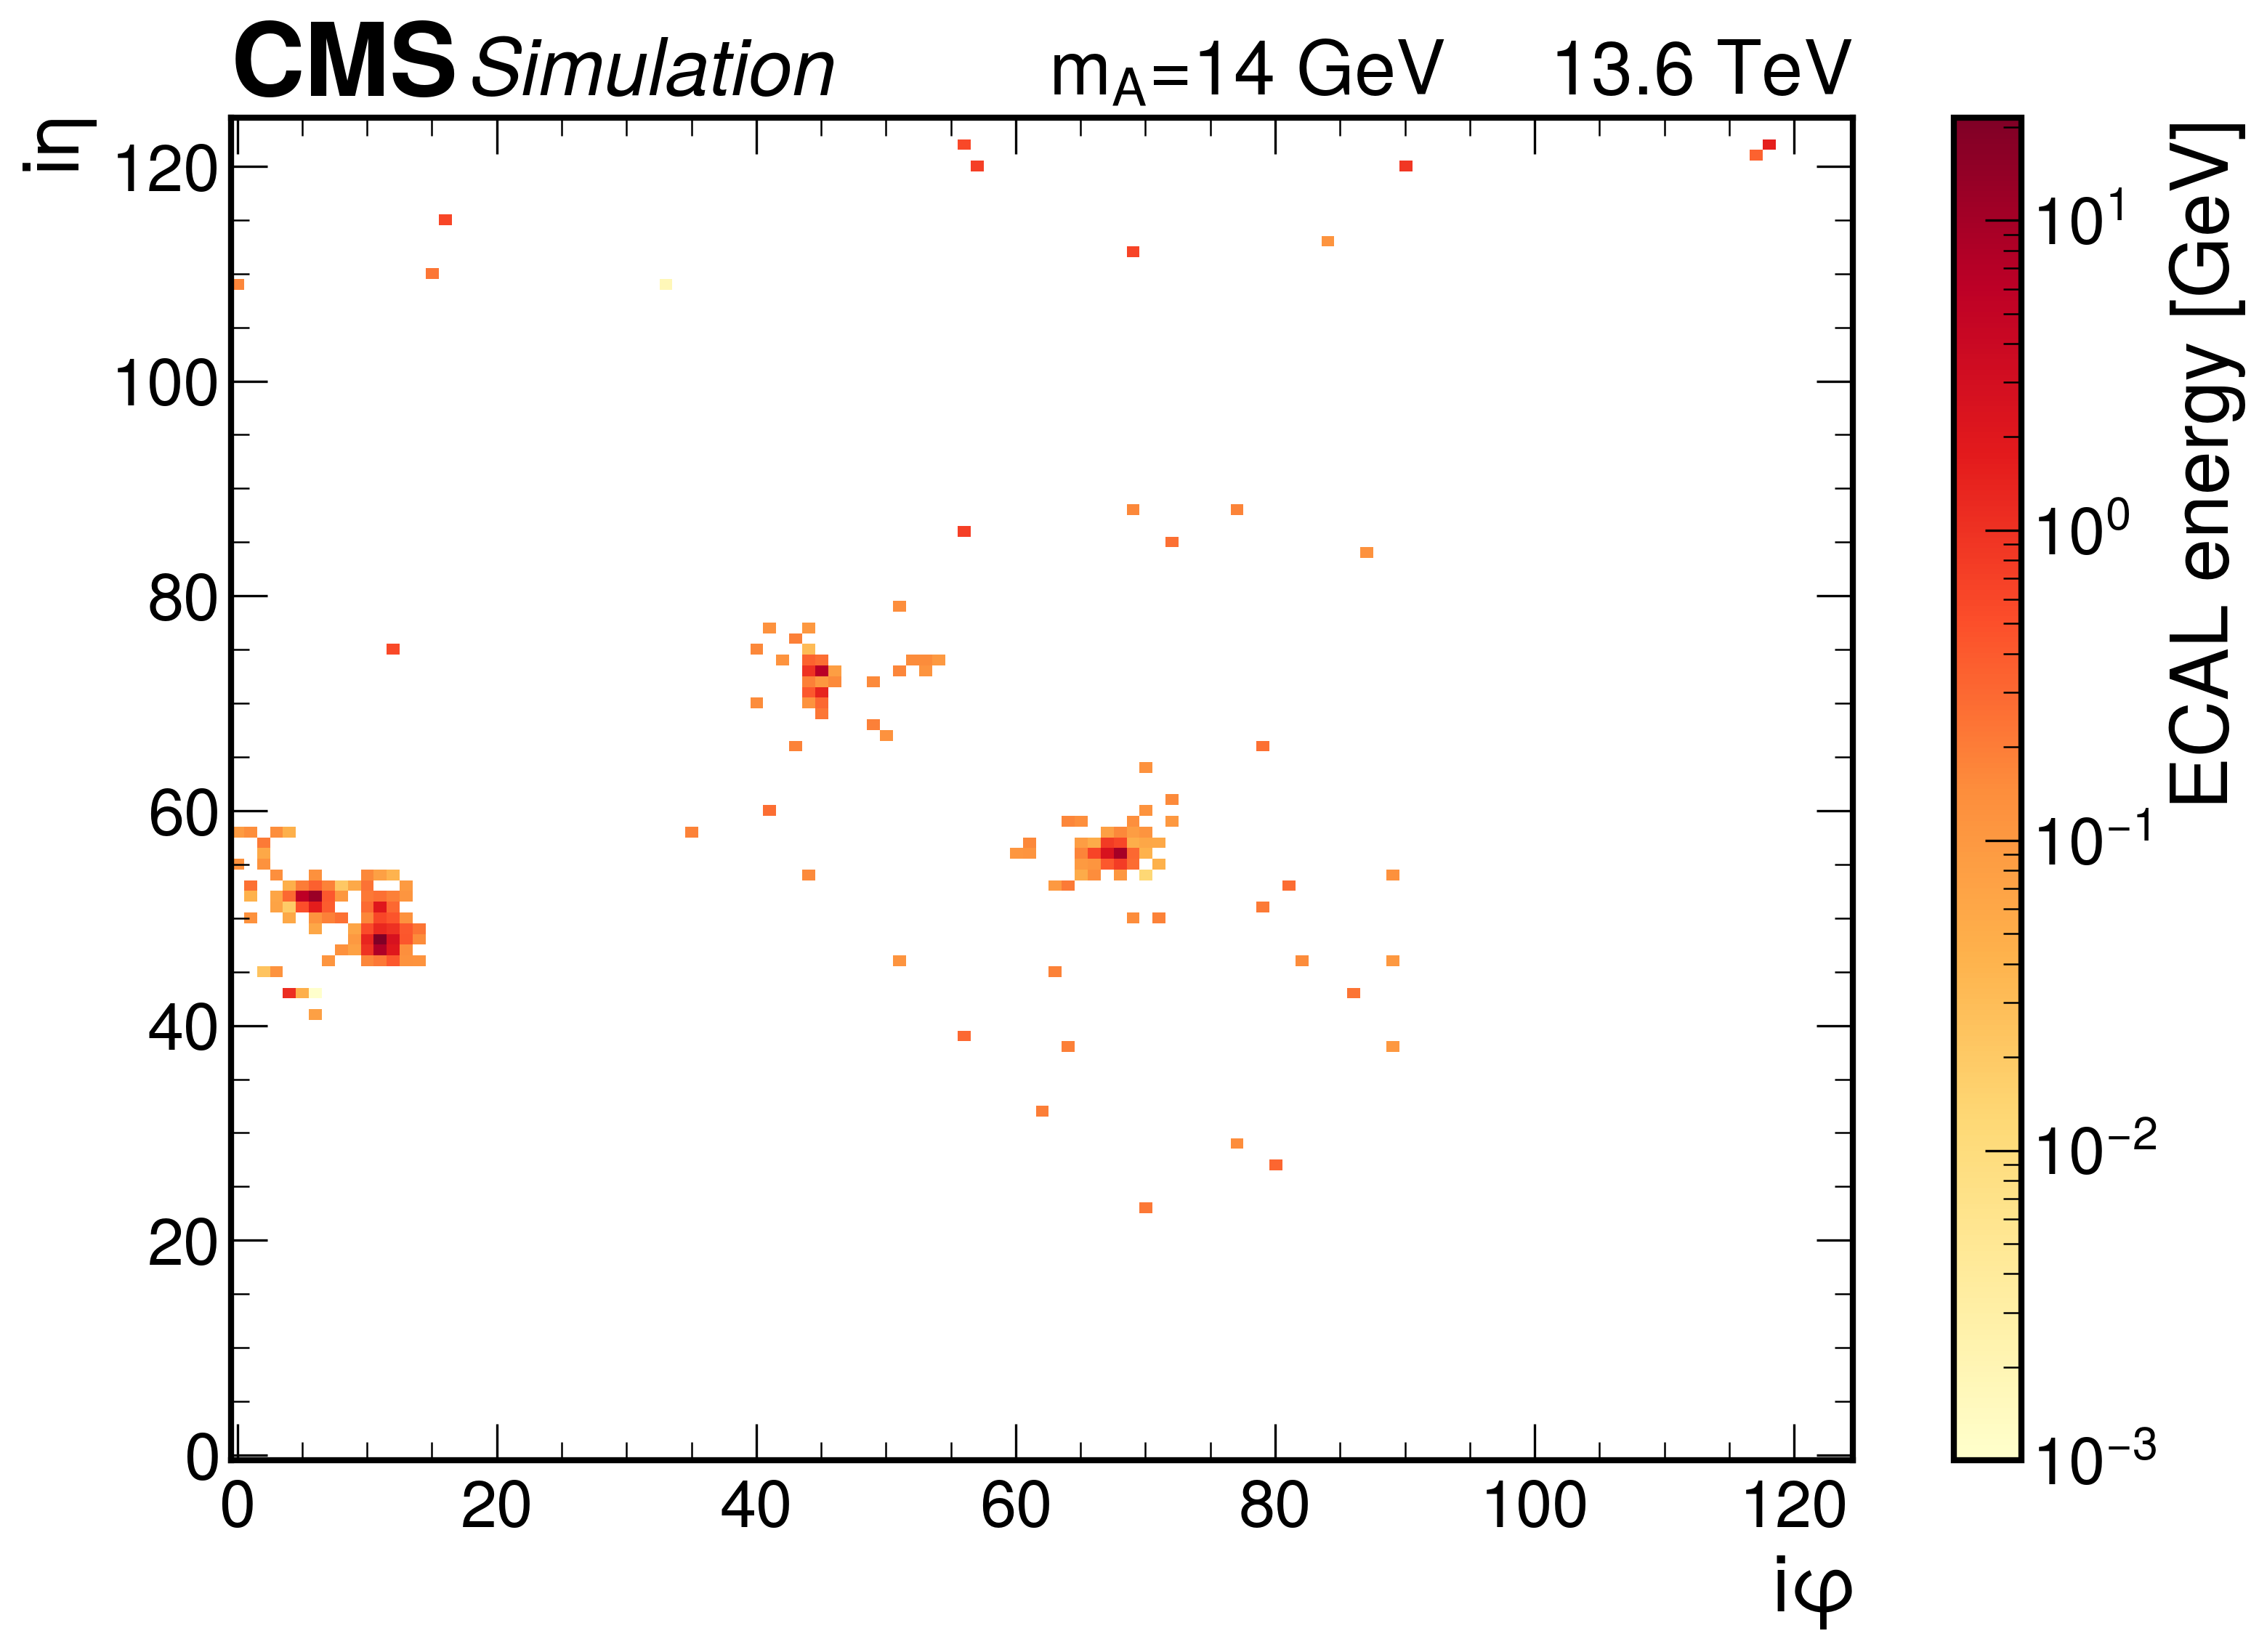

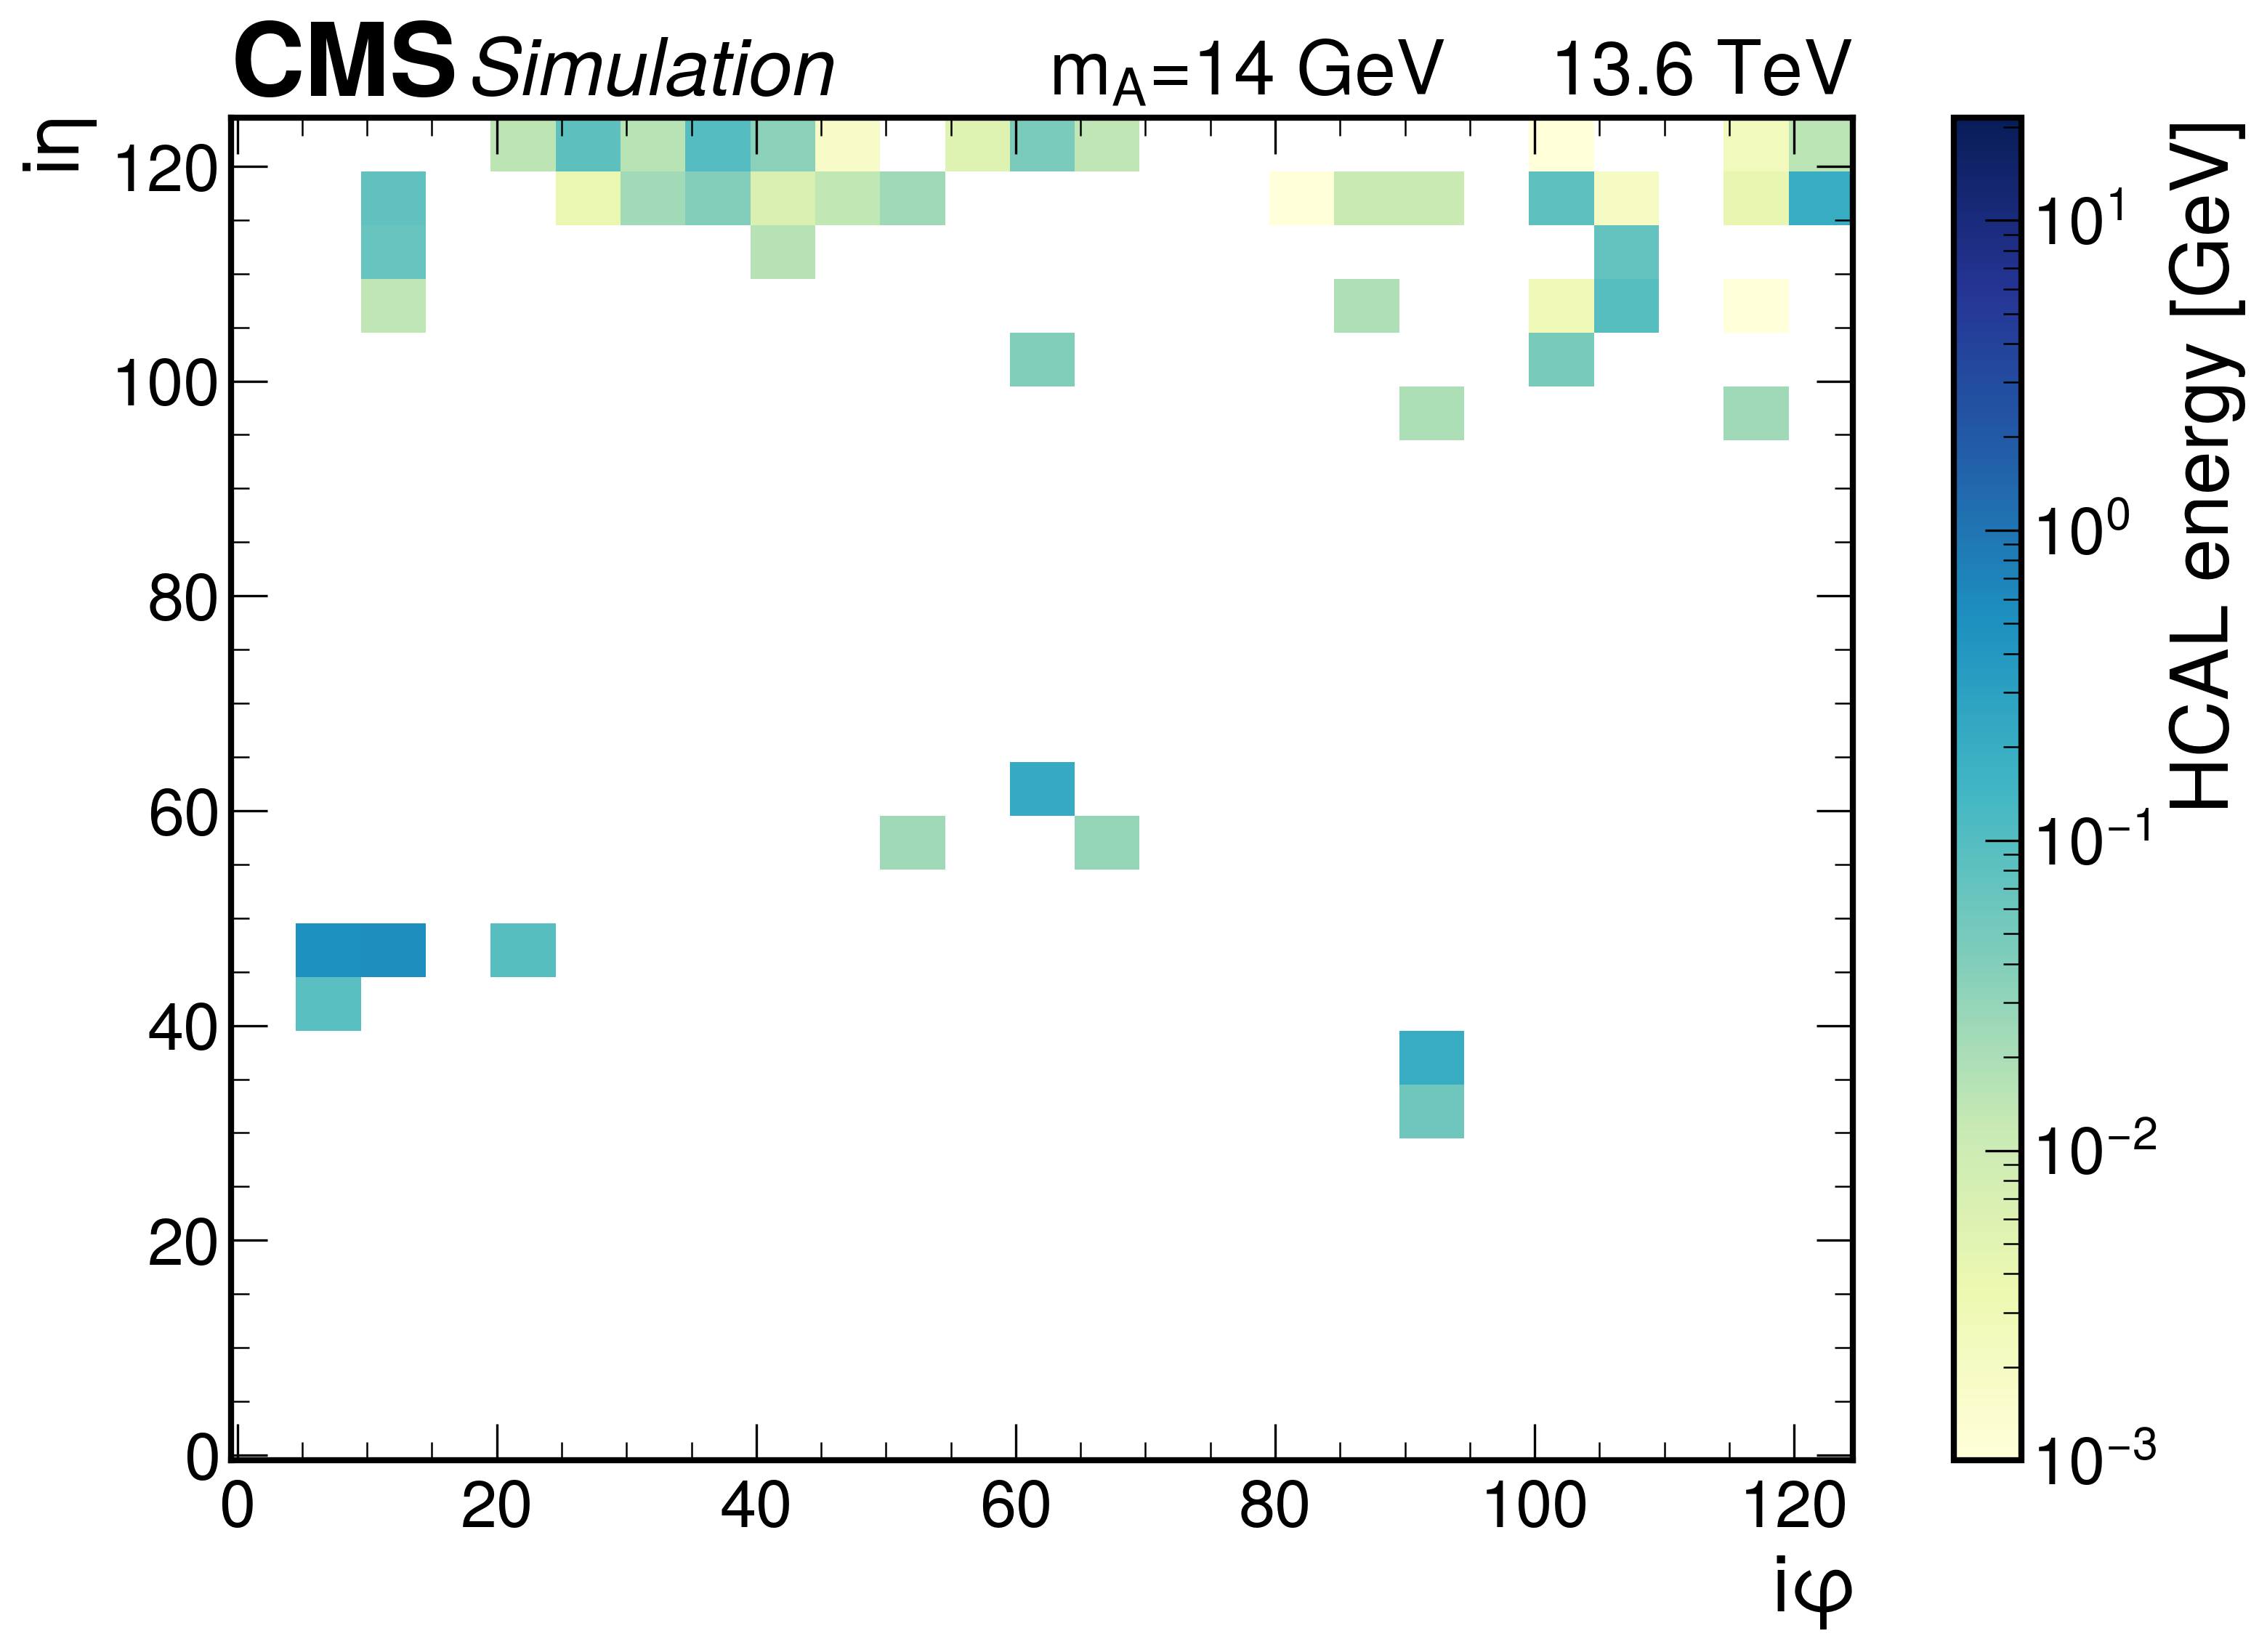

In [30]:
file = uproot.open("../analysis_run3/Data_for_plots/HToAAto4Tau_signal_sample_m14_numEvent500.root")
RHTree = file["fevt/RHTree"]
branches = RHTree.arrays(entry_start=0, entry_stop=193)
for i in [67,71]:
    plotJet_single_layer_cal(i,14)